# Noise-Level Comparison of Baryonic Response Functions

Compare the baryonic response $F_S = (S_{\rm Replace} - S_{\rm DMO})/(S_{\rm Hydro} - S_{\rm DMO})$ across different observational noise levels and smoothing scales.

**Configurations:**
- No noise (original)
- LSST ($\sigma_e=0.3$, $n_{\rm gal}=30\,{\rm arcmin}^{-2}$) with $\theta_G \in \{1, 2, 3\}$ arcmin
- DES ($\sigma_e=0.3$, $n_{\rm gal}=10\,{\rm arcmin}^{-2}$) with $\theta_G \in \{1, 2, 3\}$ arcmin

**Statistics:** $P(k)$, $C_\ell$, PDF, peaks, minima, $V_0$, $V_1$, $V_2$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import scienceplots
import NG_stats_analysis as NGstats
plt.style.use(['science', 'notebook'])

In [2]:
# ============================================================
# Constants
# ============================================================
MASS_BINS = [10**12, 10**12.5, 10**13, 10**13.5, 10**15]
RADIAL_BINS = [0, 0.5, 1, 3, 5]

BOX_SIZE = 205   # Mpc/h
GRID_3D  = 4096
K_NYQUIST = np.pi * GRID_3D / BOX_SIZE

FOV_DEG = 5.0
FOV_RAD = FOV_DEG * np.pi / 180
RT_GRID = 1024
ELL_NYQUIST = np.pi * RT_GRID / FOV_RAD

REDSHIFTS = [0.5, 1.0, 1.5, 2.0]
Z_INDICES = [13, 23, 30, 36]

KAPPA_REDSHIFTS = {
    1: 0.034, 2: 0.070, 3: 0.105, 4: 0.142, 5: 0.179,
    6: 0.216, 7: 0.255, 8: 0.294, 9: 0.335, 10: 0.376,
    11: 0.418, 12: 0.462, 13: 0.506, 14: 0.552, 15: 0.599,
    16: 0.648, 17: 0.698, 18: 0.749, 19: 0.803, 20: 0.858,
    21: 0.914, 22: 0.973, 23: 1.034, 24: 1.097, 25: 1.163,
    26: 1.231, 27: 1.302, 28: 1.375, 29: 1.452, 30: 1.532,
    31: 1.615, 32: 1.703, 33: 1.794, 34: 1.889, 35: 1.989,
    36: 2.094, 37: 2.203, 38: 2.319, 39: 2.440, 40: 2.568
}
REDSHIFTS_ALL = list(KAPPA_REDSHIFTS.values())
Z_INDICES_ALL = np.arange(40)

STATISTICS = ['Pk', 'Cl', 'pdf', 'peaks', 'minima', 'V0', 'V1', 'V2']

print(f"k_Nyquist = {K_NYQUIST:.1f} h/Mpc")
print(f"ℓ_Nyquist = {ELL_NYQUIST:.0f}")

k_Nyquist = 62.8 h/Mpc
ℓ_Nyquist = 36864


In [3]:
# ============================================================
# Model lists (same as response_analysis_h5)
# ============================================================
CUM_MODELS = [
    "hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_0.5",
    "hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_1.0",
    "hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_3.0",
    "hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0",
    "hydro_replace_Ml_3.16e12_Mu_1.00e15_Ri_0.0_Ro_0.5",
    "hydro_replace_Ml_3.16e12_Mu_1.00e15_Ri_0.0_Ro_1.0",
    "hydro_replace_Ml_3.16e12_Mu_1.00e15_Ri_0.0_Ro_3.0",
    "hydro_replace_Ml_3.16e12_Mu_1.00e15_Ri_0.0_Ro_5.0",
    "hydro_replace_Ml_1.00e13_Mu_1.00e15_Ri_0.0_Ro_0.5",
    "hydro_replace_Ml_1.00e13_Mu_1.00e15_Ri_0.0_Ro_1.0",
    "hydro_replace_Ml_1.00e13_Mu_1.00e15_Ri_0.0_Ro_3.0",
    "hydro_replace_Ml_1.00e13_Mu_1.00e15_Ri_0.0_Ro_5.0",
    "hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_0.0_Ro_0.5",
    "hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_0.0_Ro_1.0",
    "hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_0.0_Ro_3.0",
    "hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_0.0_Ro_5.0",
]
DISC_MODELS = [
    "hydro_replace_Ml_1.00e12_Mu_3.16e12_Ri_0.0_Ro_0.5",
    "hydro_replace_Ml_1.00e12_Mu_3.16e12_Ri_0.5_Ro_1.0",
    "hydro_replace_Ml_1.00e12_Mu_3.16e12_Ri_1.0_Ro_3.0",
    "hydro_replace_Ml_1.00e12_Mu_3.16e12_Ri_3.0_Ro_5.0",
    "hydro_replace_Ml_3.16e12_Mu_1.00e13_Ri_0.0_Ro_0.5",
    "hydro_replace_Ml_3.16e12_Mu_1.00e13_Ri_0.5_Ro_1.0",
    "hydro_replace_Ml_3.16e12_Mu_1.00e13_Ri_1.0_Ro_3.0",
    "hydro_replace_Ml_3.16e12_Mu_1.00e13_Ri_3.0_Ro_5.0",
    "hydro_replace_Ml_1.00e13_Mu_3.16e13_Ri_0.0_Ro_0.5",
    "hydro_replace_Ml_1.00e13_Mu_3.16e13_Ri_0.5_Ro_1.0",
    "hydro_replace_Ml_1.00e13_Mu_3.16e13_Ri_1.0_Ro_3.0",
    "hydro_replace_Ml_1.00e13_Mu_3.16e13_Ri_3.0_Ro_5.0",
    "hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_0.0_Ro_0.5",
    "hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_0.5_Ro_1.0",
    "hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_1.0_Ro_3.0",
    "hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_3.0_Ro_5.0",
]

In [4]:
# ============================================================
# Noise configurations
# ============================================================
# suffix → (display label, color, linestyle)
NOISE_CONFIGS = {
    '':                    ('No noise',             'black',   '-'),
    '_LSST_1.0arcmin':     ('LSST  $\\theta_G=1\'$',  'C0',  '-'),
    '_LSST_2.0arcmin':     ('LSST  $\\theta_G=2\'$',  'C0',  '--'),
    '_LSST_3.0arcmin':     ('LSST  $\\theta_G=3\'$',  'C0',  ':'),
    '_DES_1.0arcmin':      ('DES   $\\theta_G=1\'$',  'C3',  '-'),
    '_DES_2.0arcmin':      ('DES   $\\theta_G=2\'$',  'C3',  '--'),
    '_DES_3.0arcmin':      ('DES   $\\theta_G=3\'$',  'C3',  ':'),
}

base_path = '/mnt/home/mlee1/ceph/hydro_replace_stats'

def stats_filename(suffix):
    """Return stats filename for a given noise suffix."""
    return f'stats{suffix}.h5' if suffix else 'stats.h5'

In [5]:
# ============================================================
# Check data availability
# ============================================================
print(f"{'Config':<25s} | {'hydro':>6s} | {'dmo':>6s} | {'cum':>4s}/{len(CUM_MODELS)} | {'disc':>4s}/{len(DISC_MODELS)}")
print('-' * 70)

available_configs = []
for suffix, (label, _, _) in NOISE_CONFIGS.items():
    fname = stats_filename(suffix)
    hydro_ok = os.path.exists(f'{base_path}/hydro/{fname}')
    dmo_ok   = os.path.exists(f'{base_path}/dmo/{fname}')
    n_cum  = sum(1 for m in CUM_MODELS  if os.path.exists(f'{base_path}/{m}/{fname}'))
    n_disc = sum(1 for m in DISC_MODELS if os.path.exists(f'{base_path}/{m}/{fname}'))
    ok = hydro_ok and dmo_ok and n_cum == len(CUM_MODELS) and n_disc == len(DISC_MODELS)
    tag = '  ✓' if ok else ''
    print(f"{label:<25s} | {'✓' if hydro_ok else '✗':>6s} | {'✓' if dmo_ok else '✗':>6s} | {n_cum:>4d}   | {n_disc:>4d}  {tag}")
    if ok:
        available_configs.append(suffix)

print(f'\n{len(available_configs)} / {len(NOISE_CONFIGS)} configs fully available')

Config                    |  hydro |    dmo |  cum/16 | disc/16
----------------------------------------------------------------------
No noise                  |      ✓ |      ✓ |   16   |   16    ✓


LSST  $\theta_G=1'$       |      ✓ |      ✓ |   16   |   16    ✓
LSST  $\theta_G=2'$       |      ✓ |      ✓ |   16   |   16    ✓
LSST  $\theta_G=3'$       |      ✓ |      ✓ |   16   |   16    ✓
DES   $\theta_G=1'$       |      ✓ |      ✓ |   16   |   16    ✓
DES   $\theta_G=2'$       |      ✓ |      ✓ |   16   |   16    ✓
DES   $\theta_G=3'$       |      ✓ |      ✓ |   16   |   16    ✓

7 / 7 configs fully available


In [7]:
# ============================================================
# Load stats for all available noise configurations
# ============================================================
def load_model_stats(model_name, suffix=''):
    """Load stats from HDF5 for a given model and noise suffix."""
    fname = stats_filename(suffix)
    file_path = f'{base_path}/{model_name}/{fname}'
    try:
        with h5py.File(file_path, 'r') as f:
            data = {key: f[key][()] for key in f.keys()}
        return data
    except Exception:
        return None

# Dict of dicts:  all_data[suffix] = {'cum': {...}, 'disc': {...}, 'base': {...}}
all_data = {}

for suffix in available_configs:
    label = NOISE_CONFIGS[suffix][0]
    print(f'Loading {label} ...')
    cum  = {m: load_model_stats(m, suffix) for m in CUM_MODELS}
    disc = {m: load_model_stats(m, suffix) for m in DISC_MODELS}
    base = {'hydro': load_model_stats('hydro', suffix),
            'dmo':   load_model_stats('dmo',   suffix)}
    all_data[suffix] = {'cum': cum, 'disc': disc, 'base': base}
    n_ok = sum(1 for v in cum.values() if v is not None)
    print(f'  cum={n_ok}/{len(CUM_MODELS)}  disc={sum(1 for v in disc.values() if v is not None)}/{len(DISC_MODELS)}')

print('\nAll data loaded.')

Loading No noise ...


  cum=16/16  disc=16/16
Loading LSST  $\theta_G=1'$ ...
  cum=16/16  disc=16/16
Loading LSST  $\theta_G=2'$ ...
  cum=16/16  disc=16/16
Loading LSST  $\theta_G=3'$ ...
  cum=16/16  disc=16/16
Loading DES   $\theta_G=1'$ ...
  cum=16/16  disc=16/16
Loading DES   $\theta_G=2'$ ...
  cum=16/16  disc=16/16
Loading DES   $\theta_G=3'$ ...
  cum=16/16  disc=16/16

All data loaded.


# Compute Response Functions $F_S$ for Each Noise Level

In [8]:
# ============================================================
# Compute response F for all configs and statistics
# ============================================================
# all_results[suffix][stat_name] = output of compute_statistic_response
all_results = {}

for suffix in available_configs:
    label = NOISE_CONFIGS[suffix][0]
    print(f'Computing responses for {label} ...')
    d = all_data[suffix]
    results_this = {}
    for stat_name in STATISTICS:
        try:
            results_this[stat_name] = NGstats.compute_statistic_response(
                d['cum'], d['disc'], d['base'],
                CUM_MODELS, DISC_MODELS,
                stat_name=stat_name,
                compute_F_func=NGstats.compute_F,
                mask_all_small=True,
                threshold=0.03,
                k_nyquist=ELL_NYQUIST,
            )
        except Exception as e:
            print(f'  {stat_name}: FAILED — {e}')
    all_results[suffix] = results_this

print('\nResponse computation complete.')

Computing responses for No noise ...


/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:263: RuntimeWarning: invalid value encountered in divide
  F_raw = numerator / denom
/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:287: RuntimeWarning: invalid value encountered in divide
  frac_diff = np.abs(denom / dmo)  # shape (n_planes, n_k)
/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:263: RuntimeWarning: divide by zero encountered in divide
  F_raw = numerator / denom
/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:287: RuntimeWarning: divide by zero encountered in divide
  frac_diff = np.abs(denom / dmo)  # shape (n_planes, n_k)


Computing responses for LSST  $\theta_G=1'$ ...


/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:520: RuntimeWarning: Mean of empty slice
  model_name: np.nanmean(cum_F[model_name], axis=1)
/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:525: RuntimeWarning: Mean of empty slice
  model_name: np.nanmean(disc_F[model_name], axis=1)


Computing responses for LSST  $\theta_G=2'$ ...
Computing responses for LSST  $\theta_G=3'$ ...
Computing responses for DES   $\theta_G=1'$ ...
Computing responses for DES   $\theta_G=2'$ ...
Computing responses for DES   $\theta_G=3'$ ...

Response computation complete.


# 1. Quick Sanity Check: Raw Statistic Comparison

Compare the raw **hydro** statistics across noise levels to verify that noise and smoothing are working as expected.

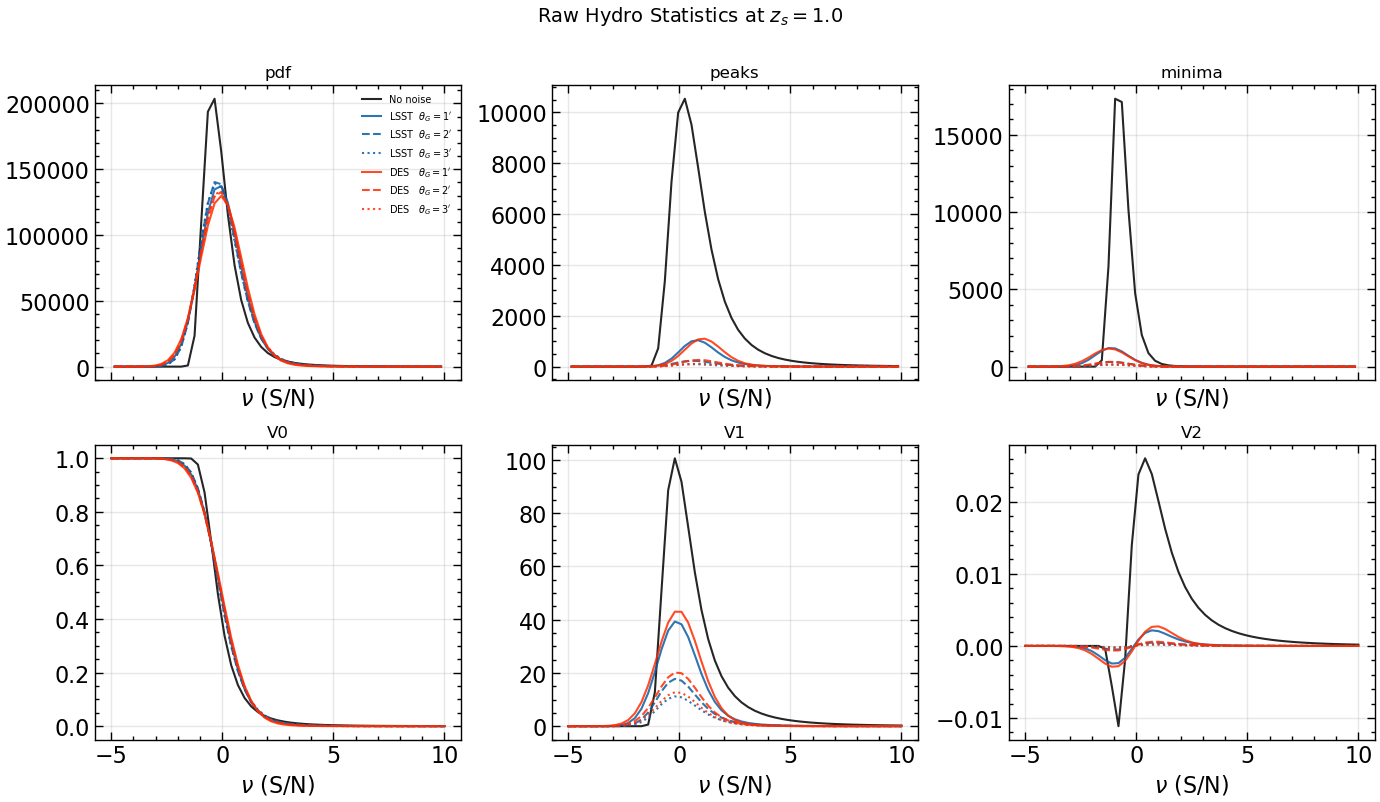

In [9]:
# ============================================================
# Raw statistic comparison: hydro at z_s = 1.0 (z_idx = 23)
# ============================================================
z_idx = 23
sn_stats = ['pdf', 'peaks', 'minima', 'V0', 'V1', 'V2']

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for ax, stat_name in zip(axes, sn_stats):
    for suffix in available_configs:
        label, color, ls = NOISE_CONFIGS[suffix]
        hydro_data = all_data[suffix]['base']['hydro']
        if hydro_data is None:
            continue
        stat = hydro_data[stat_name]  # shape (2000, 40, n_bins)
        mean_stat = stat.mean(axis=0)[z_idx]
        sn_edges = hydro_data['sn_bin_edges']
        sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
        bins = sn_centers if len(mean_stat) == len(sn_centers) else hydro_data.get('mf_thresholds', sn_centers)
        ax.plot(bins, mean_stat, label=label, color=color, ls=ls, lw=1.5, alpha=0.85)
    ax.set_title(stat_name, fontsize=12)
    ax.set_xlabel(r'$\nu$ (S/N)')
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=7, loc='upper right')
fig.suptitle(r'Raw Hydro Statistics at $z_s = 1.0$', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/noisy_raw_hydro_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()

# 2. Cumulative Response $F_S(\alpha)$ Across Noise Levels

For a single mass threshold ($M > 10^{12}\,M_\odot/h$), compare how the response changes with noise.

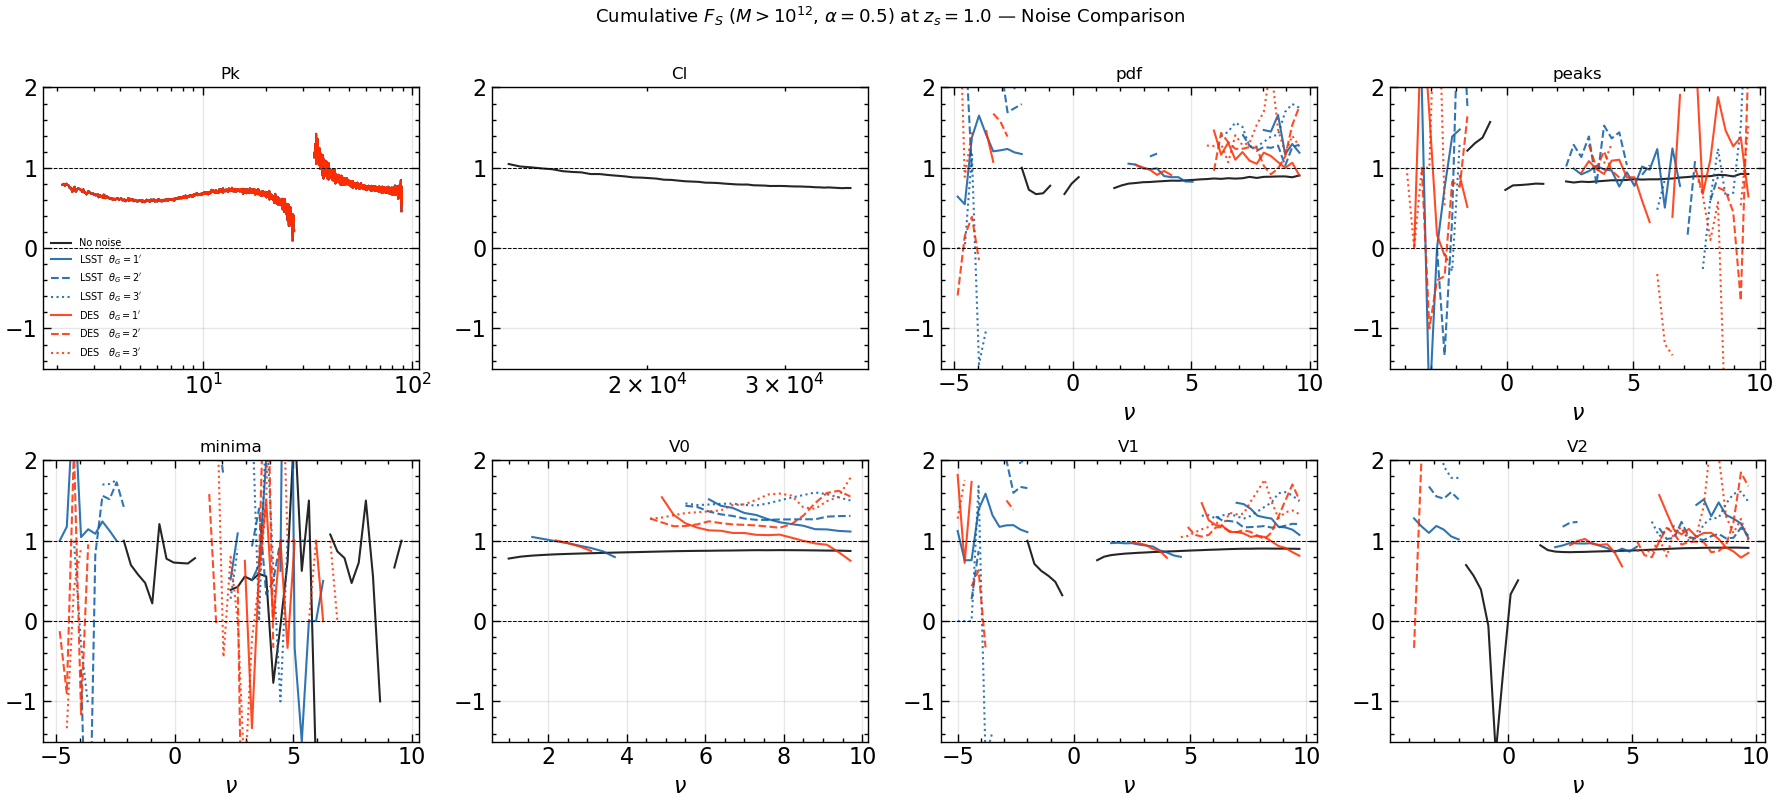

In [10]:
# ============================================================
# Cumulative F: Compare noise levels for M > 10^12, α = 0.5
# Panel per statistic, lines per noise config
# ============================================================
z_idx = 23
model_name = 'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_0.5'

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, stat_name in zip(axes, STATISTICS):
    for suffix in available_configs:
        label, color, ls = NOISE_CONFIGS[suffix]
        r = all_results.get(suffix, {}).get(stat_name)
        if r is None:
            continue
        cum_F = r.get('cum_F', {})
        if model_name not in cum_F:
            continue
        F = cum_F[model_name][z_idx]
        bins = r['bins']
        ax.plot(bins, F, label=label, color=color, ls=ls, lw=1.5, alpha=0.85)

    ax.axhline(0, color='k', ls='--', lw=0.7)
    ax.axhline(1, color='k', ls='--', lw=0.7)
    ax.set_ylim(-1.5, 2.0)
    ax.set_title(stat_name, fontsize=12)
    ax.grid(alpha=0.3)
    if stat_name in ['Pk', 'Cl']:
        ax.set_xscale('log')
    else:
        ax.set_xlabel(r'$\nu$')

axes[0].legend(fontsize=7, loc='best')
fig.suptitle(r'Cumulative $F_S$ ($M > 10^{12}$, $\alpha = 0.5$) at $z_s = 1.0$ — Noise Comparison',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/noisy_cumF_alpha05_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()

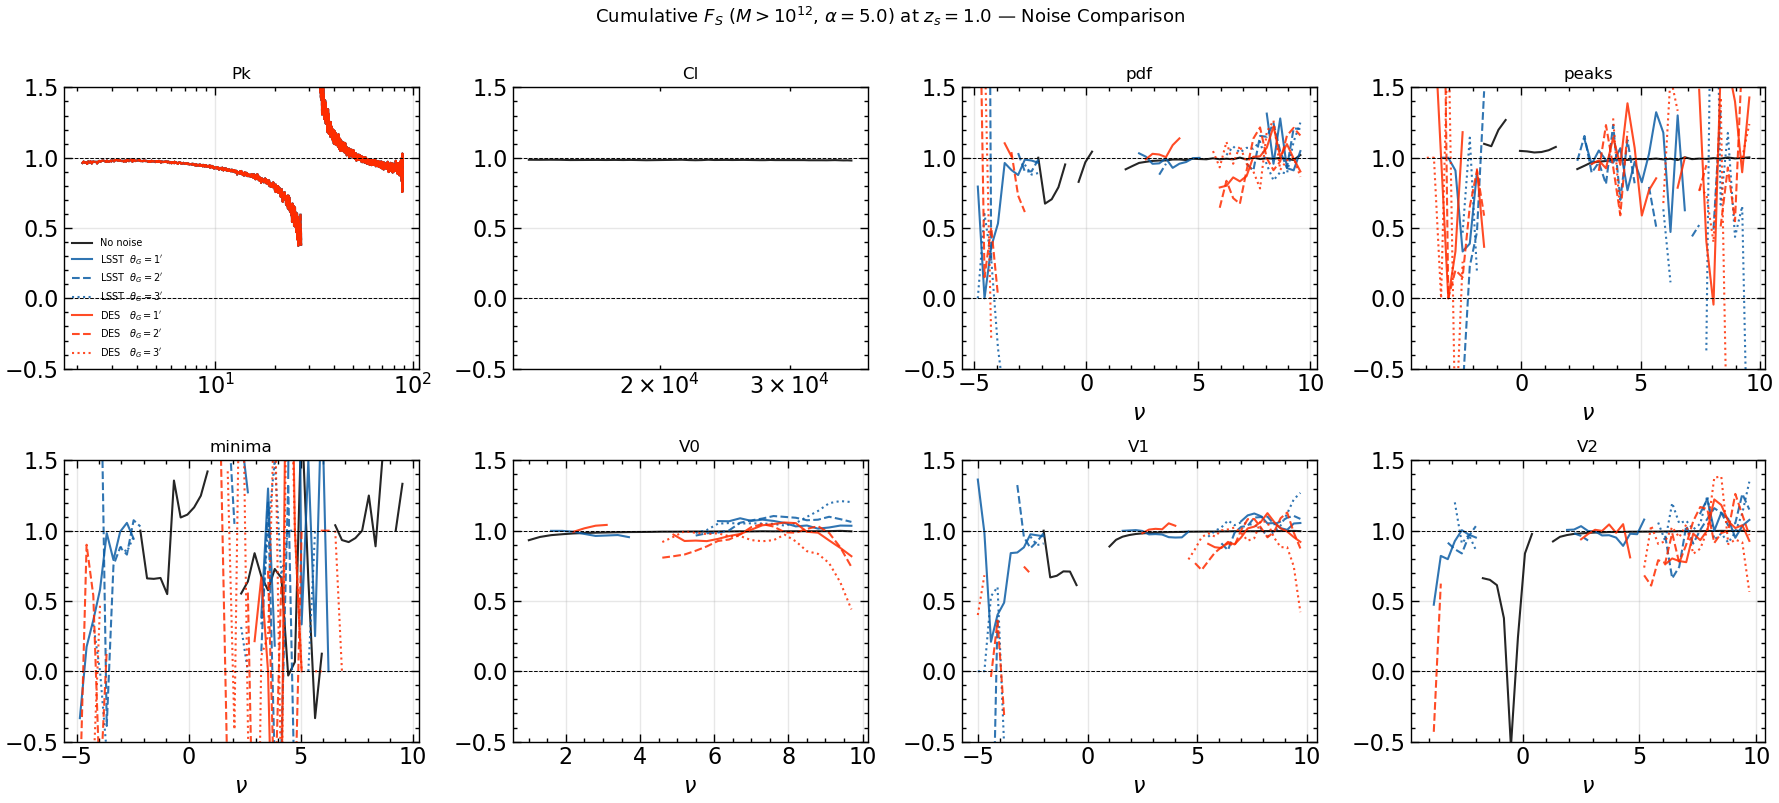

In [11]:
# ============================================================
# Same for α = 5.0  (full radial range)
# ============================================================
model_name_full = 'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0'

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, stat_name in zip(axes, STATISTICS):
    for suffix in available_configs:
        label, color, ls = NOISE_CONFIGS[suffix]
        r = all_results.get(suffix, {}).get(stat_name)
        if r is None:
            continue
        cum_F = r.get('cum_F', {})
        if model_name_full not in cum_F:
            continue
        F = cum_F[model_name_full][z_idx]
        bins = r['bins']
        ax.plot(bins, F, label=label, color=color, ls=ls, lw=1.5, alpha=0.85)

    ax.axhline(0, color='k', ls='--', lw=0.7)
    ax.axhline(1, color='k', ls='--', lw=0.7)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(stat_name, fontsize=12)
    ax.grid(alpha=0.3)
    if stat_name in ['Pk', 'Cl']:
        ax.set_xscale('log')
    else:
        ax.set_xlabel(r'$\nu$')

axes[0].legend(fontsize=7, loc='best')
fig.suptitle(r'Cumulative $F_S$ ($M > 10^{12}$, $\alpha = 5.0$) at $z_s = 1.0$ — Noise Comparison',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/noisy_cumF_alpha50_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()

# 3. Weighted-Mean $\langle F_S \rangle_\nu$ vs Noise Level

Collapse the bin dimension by computing the $\nu$-weighted mean $F_S$ for each statistic and noise configuration.

In [12]:
# ============================================================
# Weighted-mean F across bins for all noise configs
# ============================================================
z_idx = 23
alpha_vals = ['0.5', '1.0', '3.0', '5.0']
mass_thresh = '1.00e12'

def weighted_mean_F(results, stat_name, model_name, z_idx):
    """Compute variance-weighted mean F over valid bins."""
    r = results.get(stat_name)
    if r is None:
        return np.nan, np.nan
    cum_F = r.get('cum_F', {})
    cum_F_err = r.get('cum_F_err', {})
    if model_name not in cum_F:
        return np.nan, np.nan
    F = cum_F[model_name][z_idx]
    F_err = cum_F_err[model_name][z_idx] if model_name in cum_F_err else np.ones_like(F)
    valid = np.isfinite(F) & np.isfinite(F_err) & (np.abs(F_err) > 0)
    if valid.sum() == 0:
        return np.nan, np.nan
    w = 1.0 / F_err[valid]**2
    mean = np.average(F[valid], weights=w)
    err  = 1.0 / np.sqrt(np.sum(w))
    return mean, err

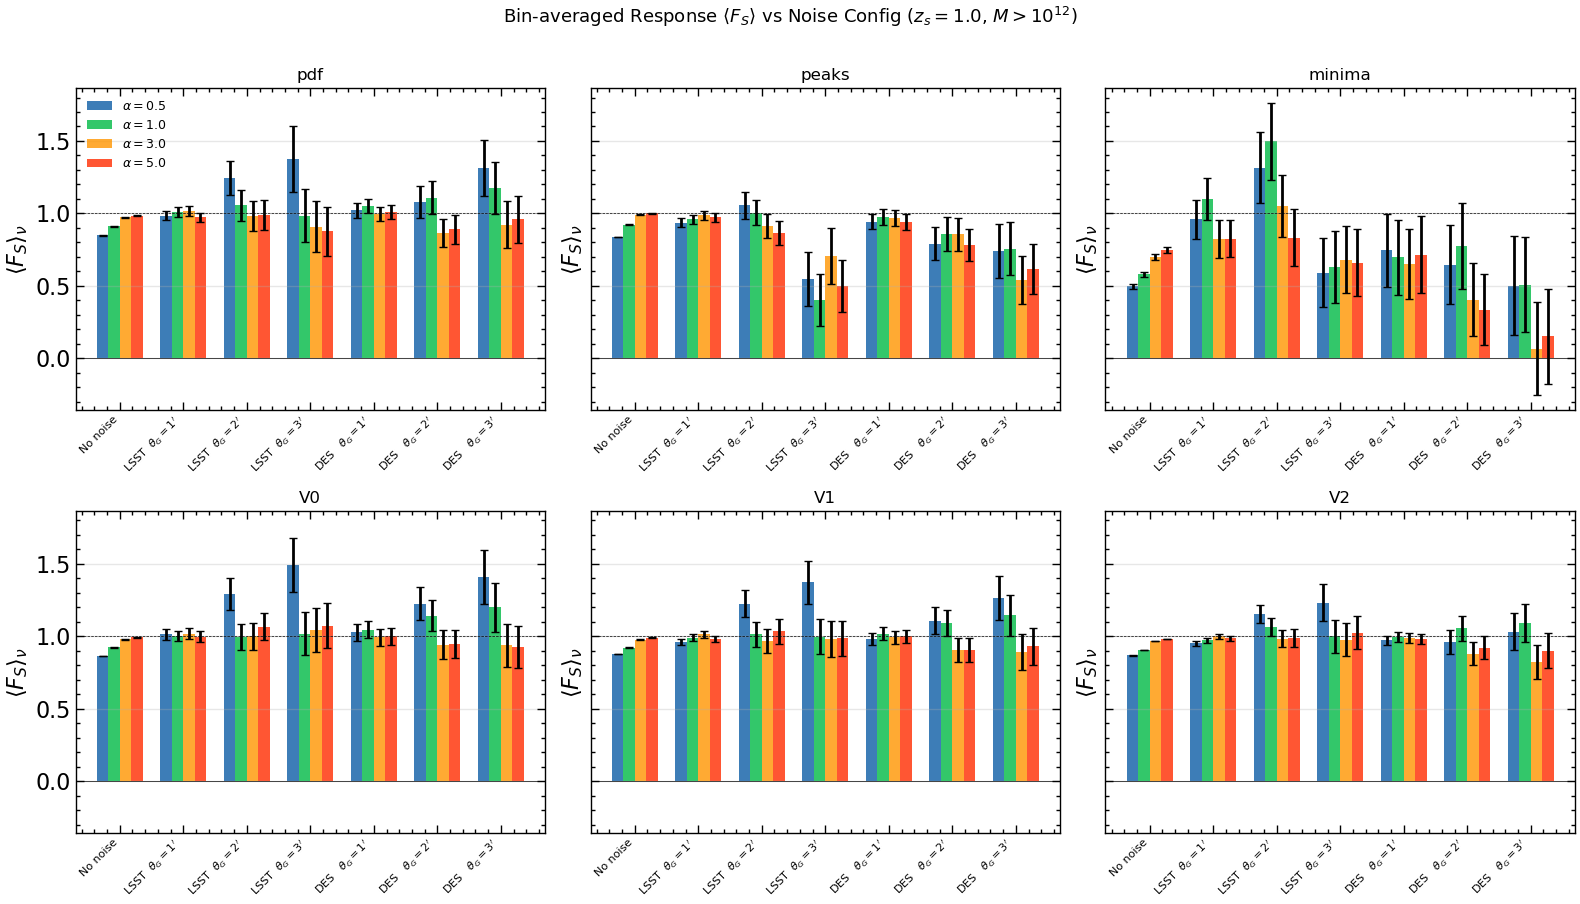

In [13]:
# ============================================================
# Bar chart: <F> per noise config, panel per stat, grouped by α
# ============================================================
sn_stat_names = ['pdf', 'peaks', 'minima', 'V0', 'V1', 'V2']

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, stat_name in zip(axes, sn_stat_names):
    x_positions = np.arange(len(available_configs))
    width = 0.18

    for j, alpha in enumerate(alpha_vals):
        model = f'hydro_replace_Ml_{mass_thresh}_Mu_1.00e15_Ri_0.0_Ro_{alpha}'
        means = []
        errs  = []
        for suffix in available_configs:
            m, e = weighted_mean_F(all_results[suffix], stat_name, model, z_idx)
            means.append(m)
            errs.append(e)
        offset = (j - 1.5) * width
        ax.bar(x_positions + offset, means, width, yerr=errs,
               label=rf'$\alpha={alpha}$' if ax is axes[0] else None,
               alpha=0.8, capsize=3)

    ax.axhline(0, color='k', lw=0.5)
    ax.axhline(1, color='k', ls='--', lw=0.5)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([NOISE_CONFIGS[s][0] for s in available_configs],
                       rotation=45, ha='right', fontsize=8)
    ax.set_title(stat_name, fontsize=12)
    ax.set_ylabel(r'$\langle F_S \rangle_\nu$')
    ax.grid(alpha=0.3, axis='y')

axes[0].legend(fontsize=9, loc='upper left')
fig.suptitle(r'Bin-averaged Response $\langle F_S \rangle$ vs Noise Config ($z_s=1.0$, $M > 10^{12}$)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/noisy_mean_F_barchart.pdf', dpi=150, bbox_inches='tight')
plt.show()

# 4. Redshift Evolution of $\langle F_S \rangle$ Under Different Noise Levels

Does the noise change the *redshift dependence* of the response?

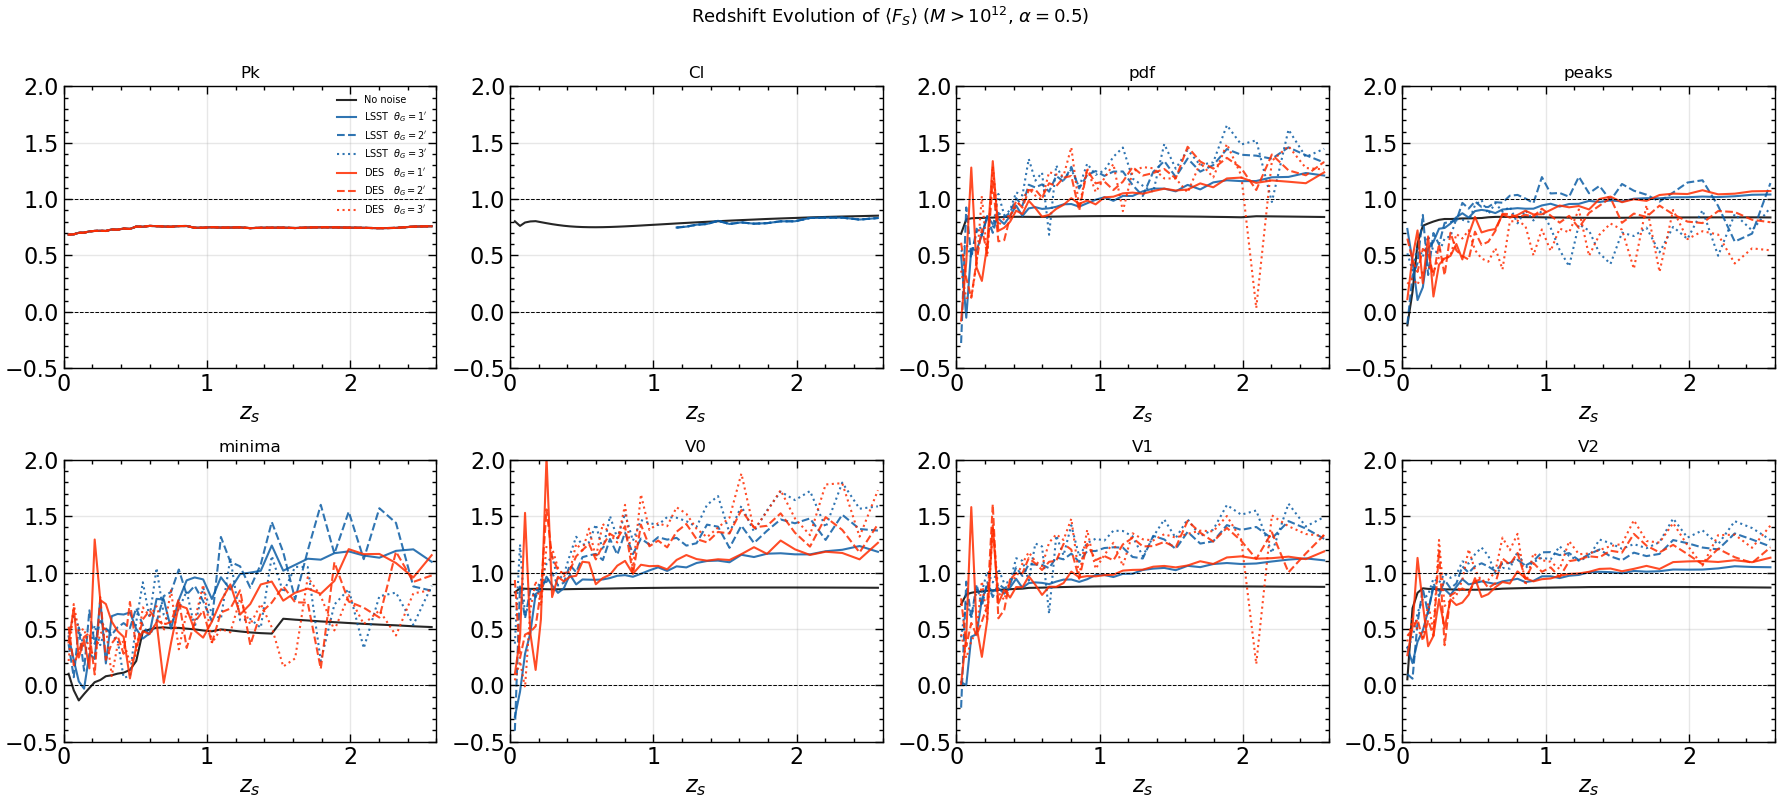

In [14]:
# ============================================================
# Redshift evolution of <F> for a fixed model, different noise
# ============================================================
model_name = 'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_0.5'

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, stat_name in zip(axes, STATISTICS):
    for suffix in available_configs:
        label, color, ls = NOISE_CONFIGS[suffix]
        F_vs_z = []
        for zi in Z_INDICES_ALL:
            m, _ = weighted_mean_F(all_results[suffix], stat_name, model_name, zi)
            F_vs_z.append(m)
        ax.plot(REDSHIFTS_ALL, F_vs_z, color=color, ls=ls, lw=1.5, alpha=0.85, label=label)

    ax.axhline(0, color='k', ls='--', lw=0.7)
    ax.axhline(1, color='k', ls='--', lw=0.7)
    ax.set_ylim(-0.5, 2.0)
    ax.set_xlim(0, 2.6)
    ax.set_xlabel(r'$z_s$')
    ax.set_title(stat_name, fontsize=12)
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=7, loc='upper right')
fig.suptitle(r'Redshift Evolution of $\langle F_S \rangle$ ($M > 10^{12}$, $\alpha = 0.5$)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/noisy_redshift_evolution.pdf', dpi=150, bbox_inches='tight')
plt.show()

# 5. Noise-Induced Shift in $F_S$: Heatmap

$\Delta F_S = F_S^{\rm noisy} - F_S^{\rm noiseless}$ across all cumulative models.

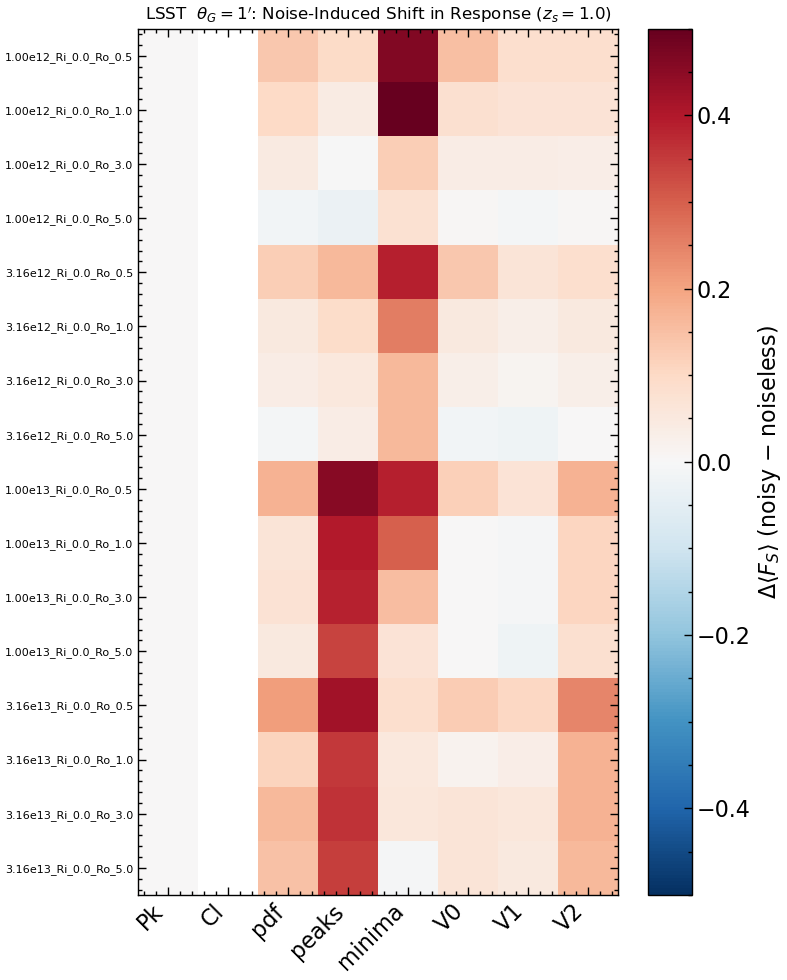

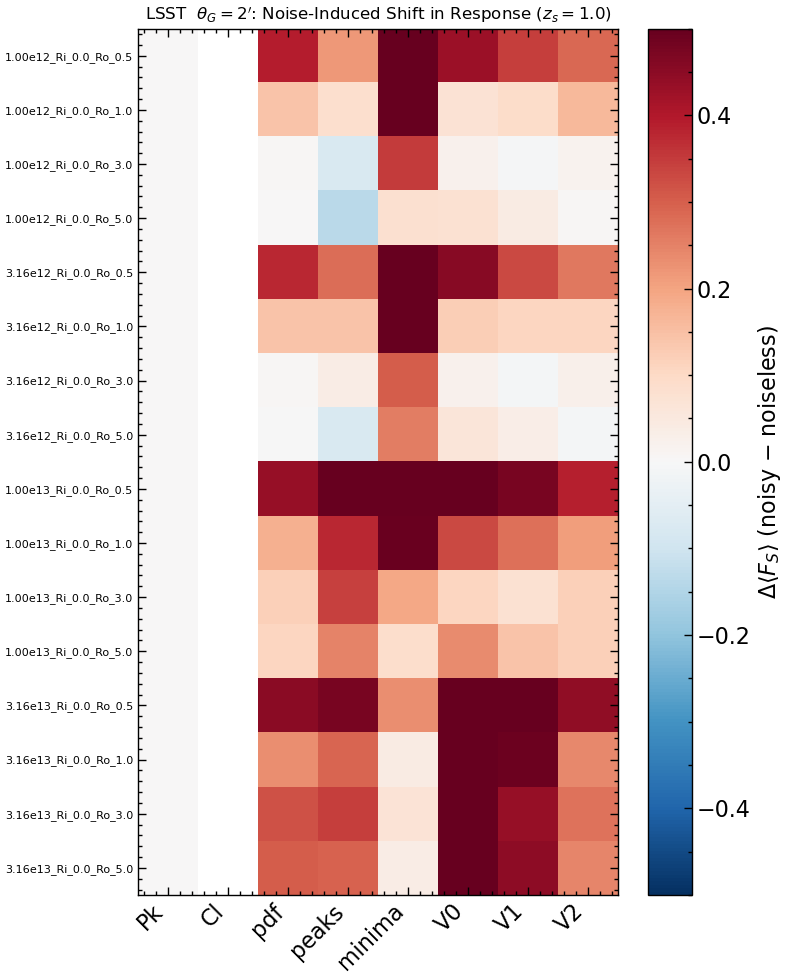

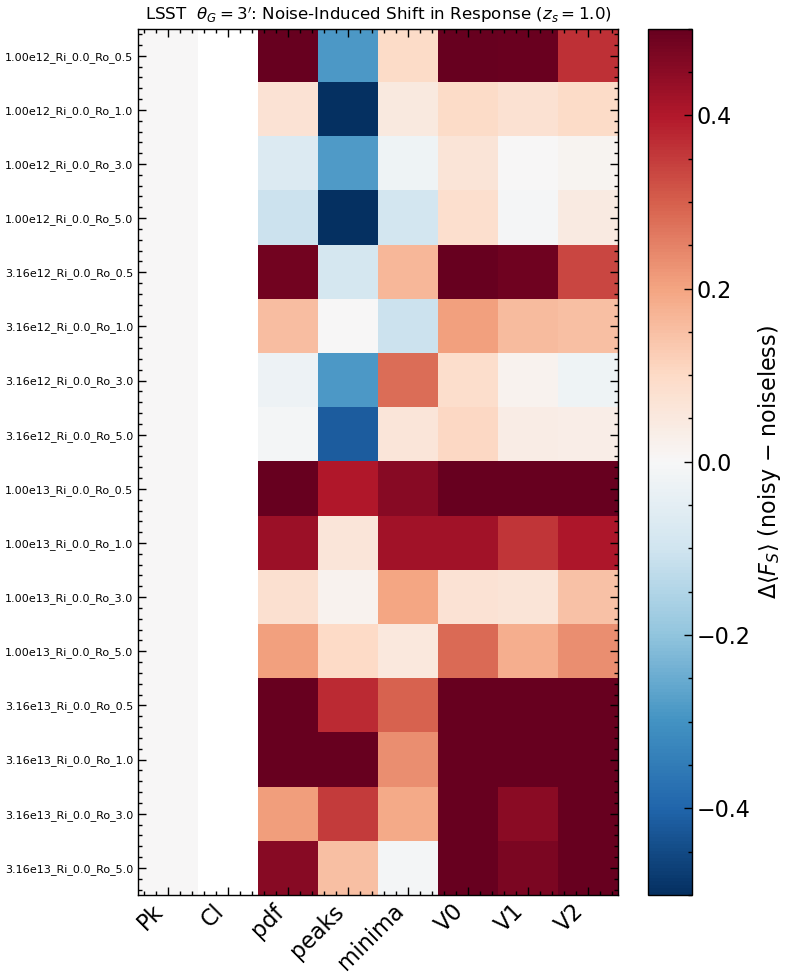

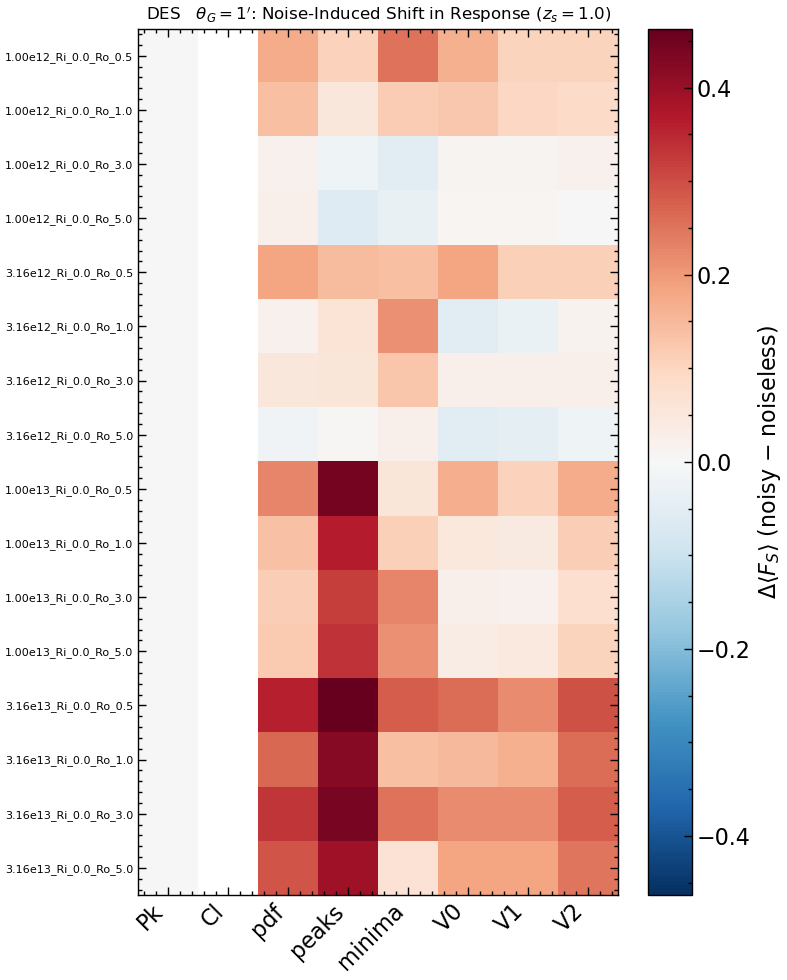

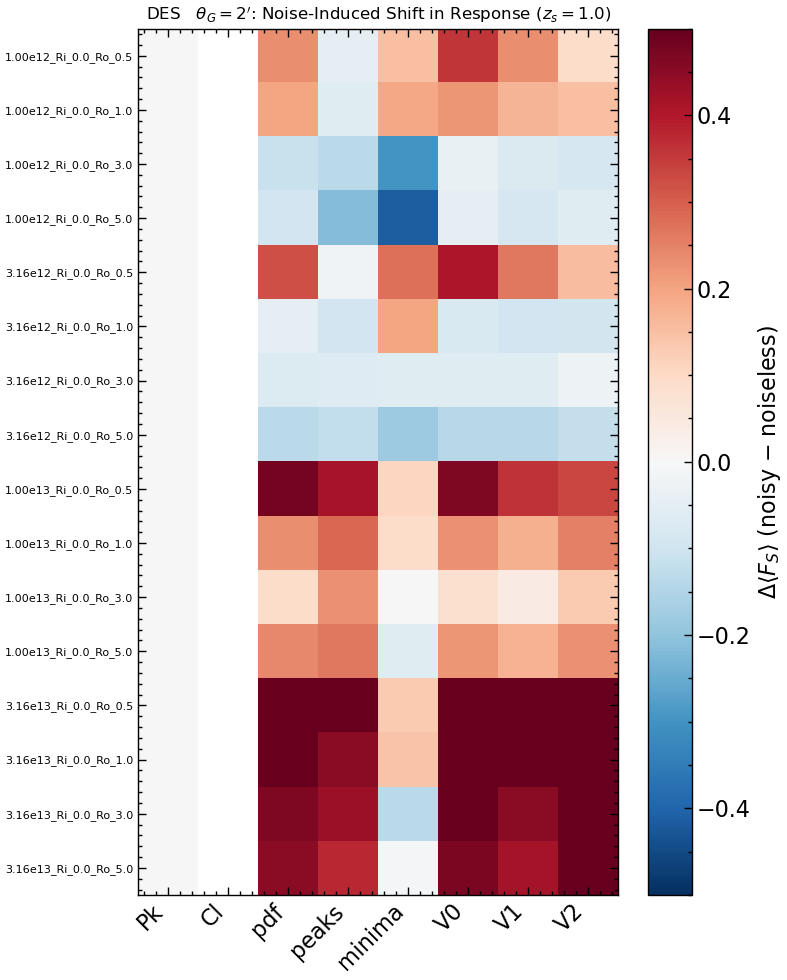

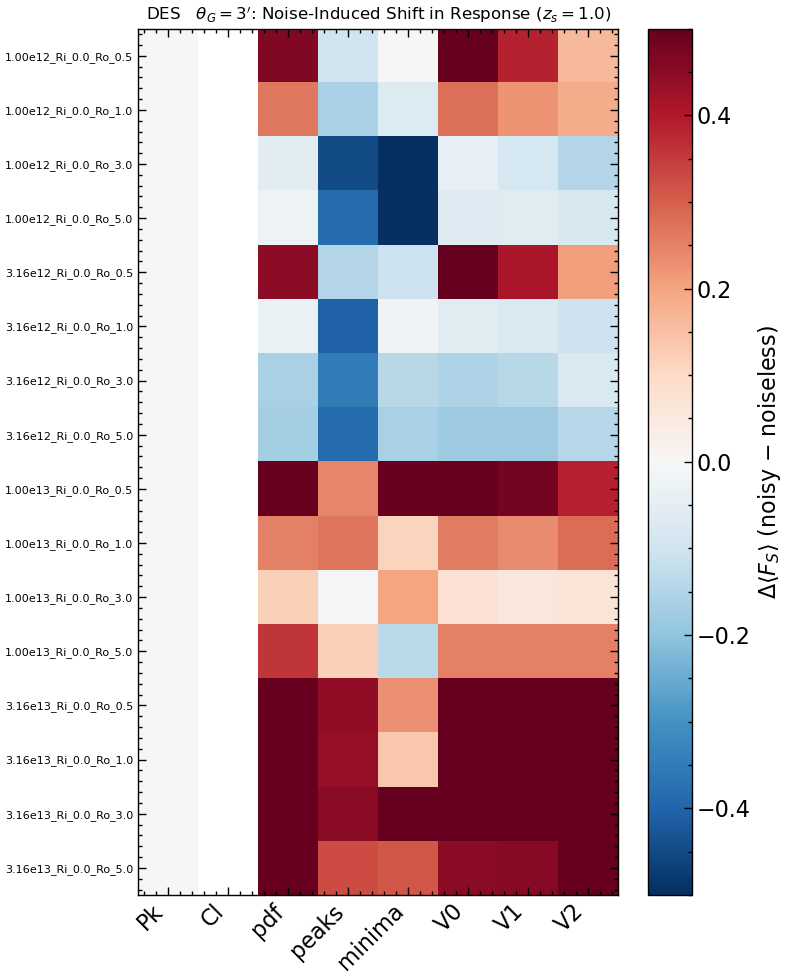

In [15]:
# ============================================================
# Heatmap: ΔF = F_noisy - F_noiseless for each stat × model
# ============================================================
if '' not in available_configs:
    print('Noiseless config not available — skipping heatmap')
else:
    noisy_suffixes = [s for s in available_configs if s != '']

    for suffix in noisy_suffixes:
        label = NOISE_CONFIGS[suffix][0]

        # Build matrix: rows = cumulative models, cols = statistics
        delta_F = np.full((len(CUM_MODELS), len(STATISTICS)), np.nan)

        for j, stat_name in enumerate(STATISTICS):
            for i, model in enumerate(CUM_MODELS):
                F_noisy, _  = weighted_mean_F(all_results[suffix], stat_name, model, z_idx)
                F_clean, _  = weighted_mean_F(all_results[''],     stat_name, model, z_idx)
                delta_F[i, j] = F_noisy - F_clean

        fig, ax = plt.subplots(figsize=(8, 10))
        vmax = np.nanmax(np.abs(delta_F))
        vmax = min(vmax, 0.5)  # cap for readability
        im = ax.imshow(delta_F, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
        ax.set_xticks(range(len(STATISTICS)))
        ax.set_xticklabels(STATISTICS, rotation=45, ha='right')
        ax.set_yticks(range(len(CUM_MODELS)))
        # Shorten model labels
        short_labels = [m.replace('hydro_replace_Ml_','').replace('_Mu_1.00e15','') for m in CUM_MODELS]
        ax.set_yticklabels(short_labels, fontsize=8)
        plt.colorbar(im, ax=ax, label=r'$\Delta \langle F_S \rangle$ (noisy $-$ noiseless)')
        ax.set_title(f'{label}: Noise-Induced Shift in Response ($z_s=1.0$)', fontsize=12)
        plt.tight_layout()
        safe = suffix.strip('_')
        plt.savefig(f'figures/noisy_deltaF_heatmap_{safe}.pdf', dpi=150, bbox_inches='tight')
        plt.show()

# 6. Discrete Response Comparison

Compare discrete $\Delta F_S$ tiles across noise levels for the innermost radial bin.

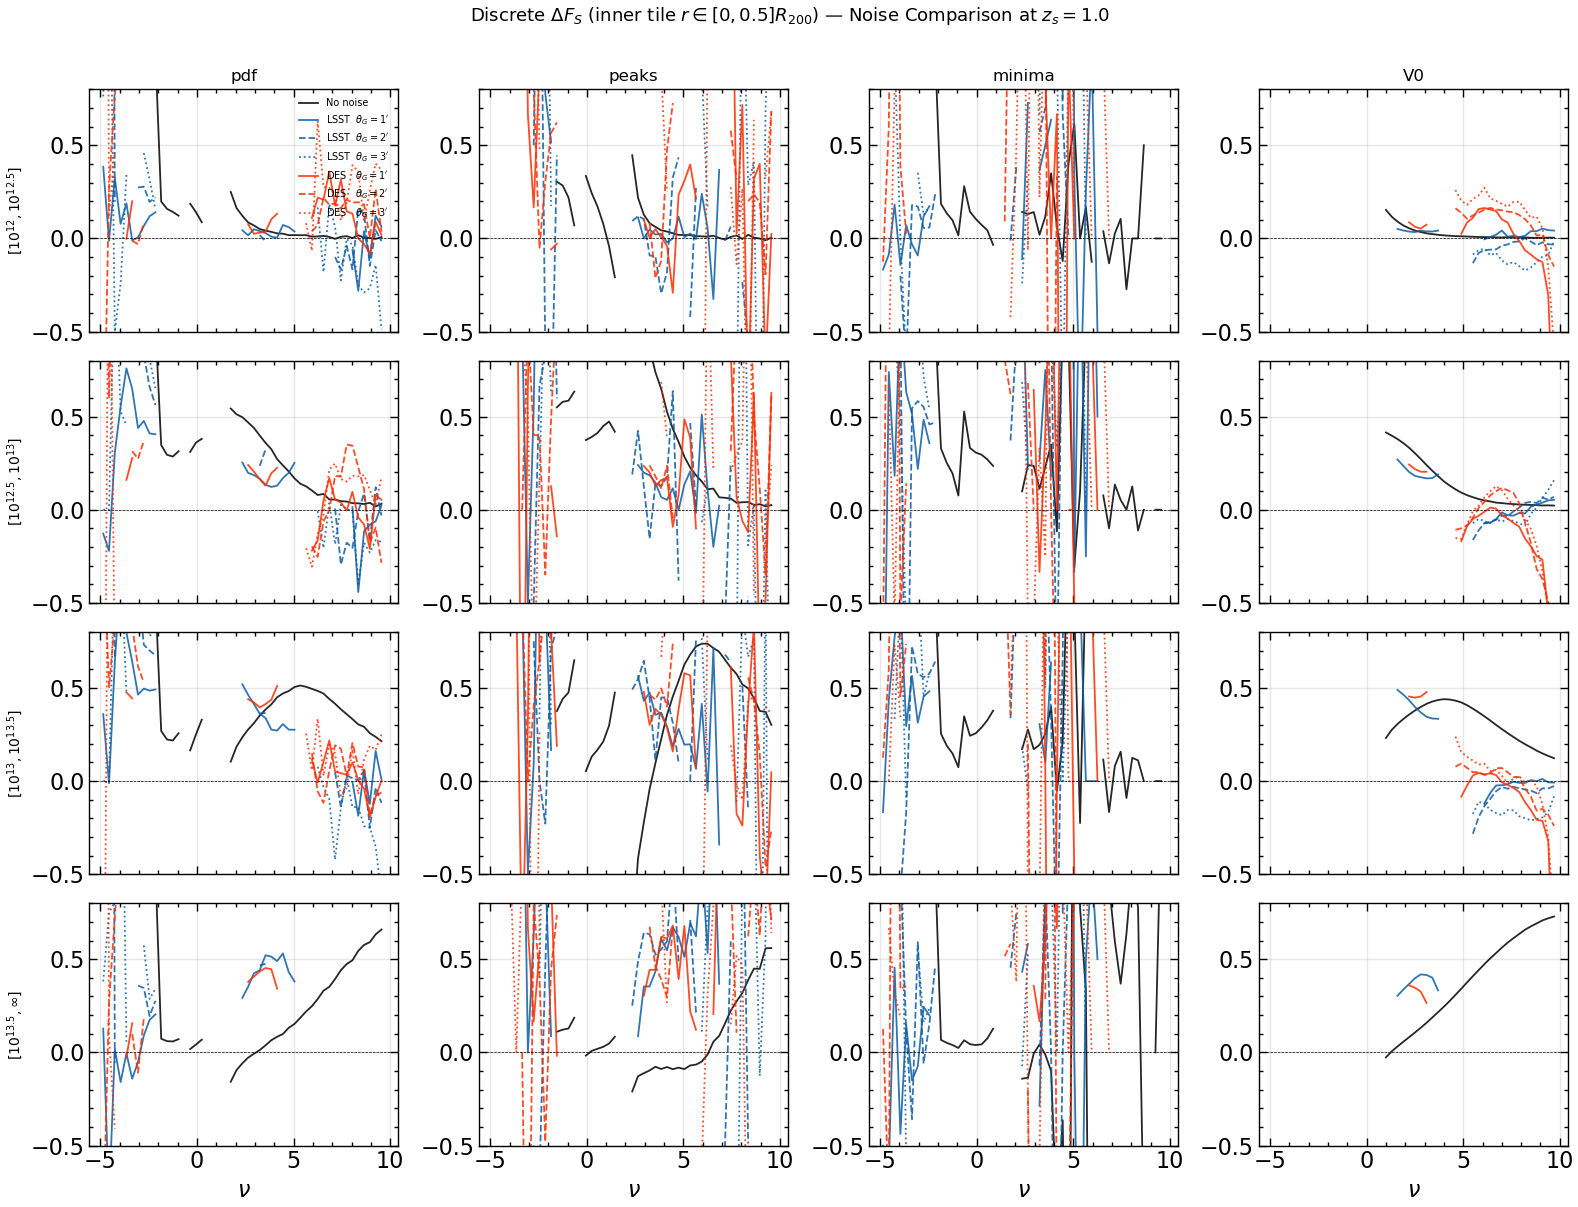

In [16]:
# ============================================================
# Discrete ΔF for innermost tile: Ri=0→0.5  across mass bins
# ============================================================
z_idx = 23
disc_inner_models = [
    'hydro_replace_Ml_1.00e12_Mu_3.16e12_Ri_0.0_Ro_0.5',
    'hydro_replace_Ml_3.16e12_Mu_1.00e13_Ri_0.0_Ro_0.5',
    'hydro_replace_Ml_1.00e13_Mu_3.16e13_Ri_0.0_Ro_0.5',
    'hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_0.0_Ro_0.5',
]
mass_display = [r'$[10^{12}, 10^{12.5}]$', r'$[10^{12.5}, 10^{13}]$',
                r'$[10^{13}, 10^{13.5}]$',  r'$[10^{13.5}, \infty]$']

sn_stats_plot = ['pdf', 'peaks', 'minima', 'V0']

fig, axes = plt.subplots(len(disc_inner_models), len(sn_stats_plot),
                         figsize=(16, 12), sharex=True)

for row, (model, mlabel) in enumerate(zip(disc_inner_models, mass_display)):
    for col, stat_name in enumerate(sn_stats_plot):
        ax = axes[row, col]
        for suffix in available_configs:
            label, color, ls = NOISE_CONFIGS[suffix]
            r = all_results.get(suffix, {}).get(stat_name)
            if r is None:
                continue
            disc_F = r.get('disc_F', {})
            if model not in disc_F:
                continue
            F = disc_F[model][z_idx]
            bins = r['bins']
            ax.plot(bins, F, color=color, ls=ls, lw=1.3, alpha=0.85,
                    label=label if row == 0 and col == 0 else None)

        ax.axhline(0, color='k', ls='--', lw=0.5)
        ax.set_ylim(-0.5, 0.8)
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(stat_name, fontsize=12)
        if col == 0:
            ax.set_ylabel(mlabel, fontsize=10)
        if row == len(disc_inner_models) - 1:
            ax.set_xlabel(r'$\nu$')

axes[0, 0].legend(fontsize=7, loc='upper right')
fig.suptitle(r'Discrete $\Delta F_S$ (inner tile $r \in [0, 0.5]R_{200}$) — Noise Comparison at $z_s=1.0$',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/noisy_discrete_inner_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()

# 7. Signal-to-Noise of the Baryonic Effect

Compute $(S_{\rm Hydro} - S_{\rm DMO}) / \sigma_{\rm DMO}$ per bin to quantify how much noise dilutes the detectable baryonic signal.

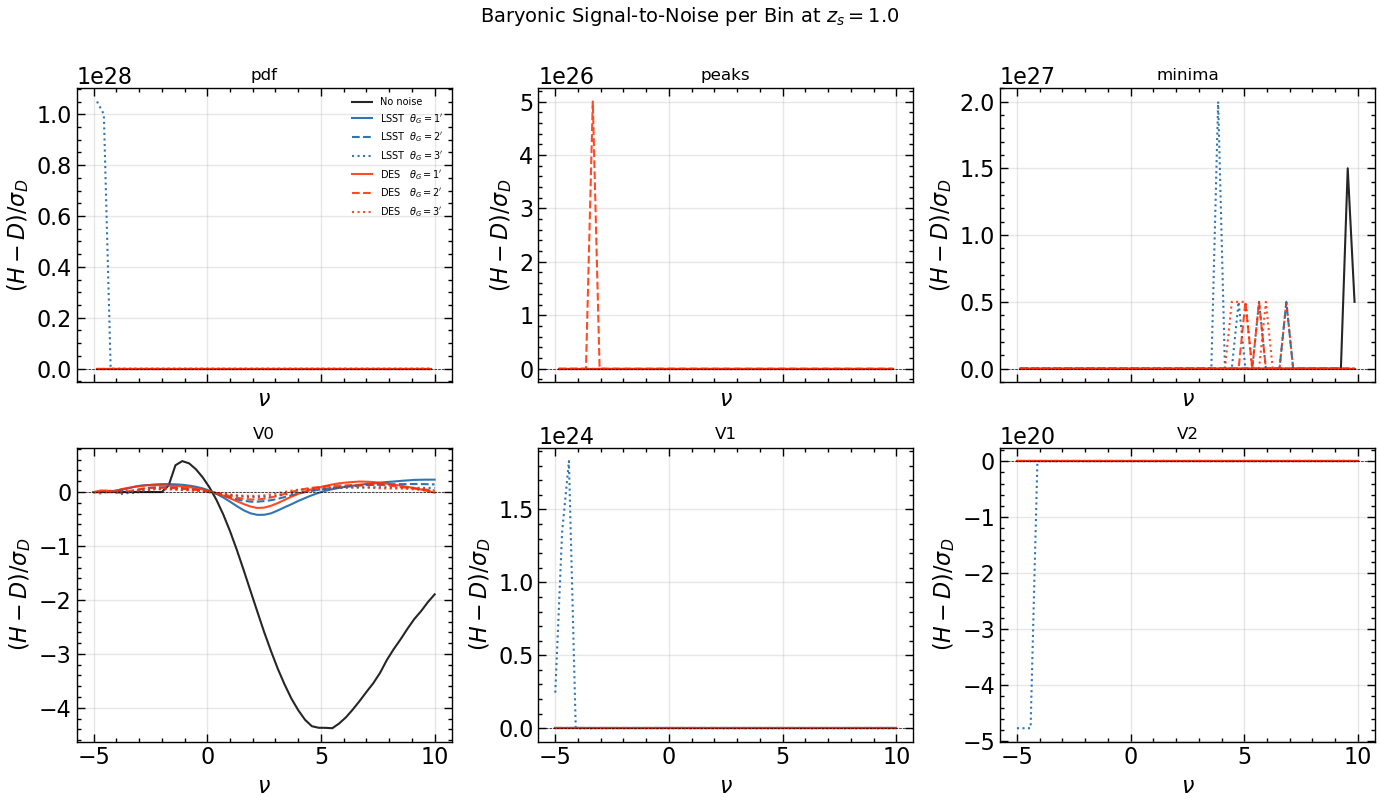

In [17]:
# ============================================================
# Baryonic S/N: (hydro - dmo) / std(dmo) per bin
# ============================================================
z_idx = 23
sn_stats_check = ['pdf', 'peaks', 'minima', 'V0', 'V1', 'V2']

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for ax, stat_name in zip(axes, sn_stats_check):
    for suffix in available_configs:
        label, color, ls = NOISE_CONFIGS[suffix]
        d = all_data[suffix]
        hydro = d['base']['hydro']
        dmo   = d['base']['dmo']
        if hydro is None or dmo is None:
            continue
        # Mean and std across realisations
        H_mean = hydro[stat_name].mean(axis=0)[z_idx]
        D_mean = dmo[stat_name].mean(axis=0)[z_idx]
        D_std  = dmo[stat_name].std(axis=0)[z_idx]
        with np.errstate(divide='ignore', invalid='ignore'):
            baryon_snr = (H_mean - D_mean) / (D_std + 1e-30)

        sn_edges = hydro['sn_bin_edges']
        sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
        bins = sn_centers if len(baryon_snr) == len(sn_centers) else hydro.get('mf_thresholds', sn_centers)
        ax.plot(bins, baryon_snr, color=color, ls=ls, lw=1.5, alpha=0.85, label=label)

    ax.axhline(0, color='k', ls='--', lw=0.5)
    ax.set_title(stat_name, fontsize=12)
    ax.set_xlabel(r'$\nu$')
    ax.set_ylabel(r'$(H - D) / \sigma_D$')
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=7, loc='best')
fig.suptitle(r'Baryonic Signal-to-Noise per Bin at $z_s = 1.0$', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures/noisy_baryonic_SNR.pdf', dpi=150, bbox_inches='tight')
plt.show()

# 8. Power Spectrum and $C_\ell$ Response

Noise enters as a flat additive contribution to $P(k)$ and $C_\ell$, which should cancel in the response ratio. Verify this.

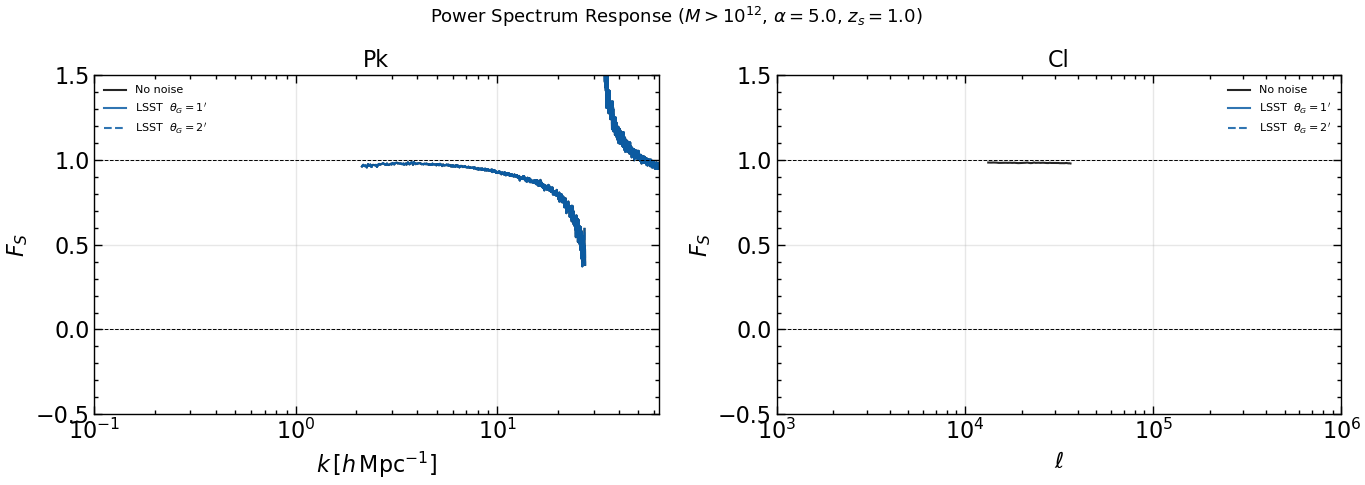

In [53]:
# ============================================================
# P(k) and C(ℓ) response for hydro, comparing noise levels
# ============================================================
z_idx = 23
model_pk = 'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, stat_name, xlabel, xlim in zip(
    axes,
    ['Pk', 'Cl'],
    [r'$k\,[h\,{\rm Mpc}^{-1}]$', r'$\ell$'],
    [(0.1, 63), (1e3, 1e6)]
):
    for suffix in available_configs:
        label, color, ls = NOISE_CONFIGS[suffix]
        r = all_results.get(suffix, {}).get(stat_name)
        if r is None:
            continue
        cum_F = r.get('cum_F', {})
        if model_pk not in cum_F:
            continue
        F = cum_F[model_pk][z_idx]
        bins = r['bins']
        ax.plot(bins, F, color=color, ls=ls, lw=1.5, alpha=0.85, label=label)

    ax.axhline(0, color='k', ls='--', lw=0.7)
    ax.axhline(1, color='k', ls='--', lw=0.7)
    ax.set_xscale('log')
    ax.set_xlim(xlim)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'$F_S$')
    ax.set_title(stat_name)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle(r'Power Spectrum Response ($M > 10^{12}$, $\alpha = 5.0$, $z_s = 1.0$)',
             fontsize=13)
plt.tight_layout()
plt.savefig('figures/noisy_Pk_Cl_response.pdf', dpi=150, bbox_inches='tight')
plt.show()

# 9. Consolidated Heatmap: $\langle F \rangle$ on the $(M, \alpha)$ Grid

Side-by-side heatmaps of the response on the mass–radius grid for noiseless vs LSST $\theta_G=1'$.

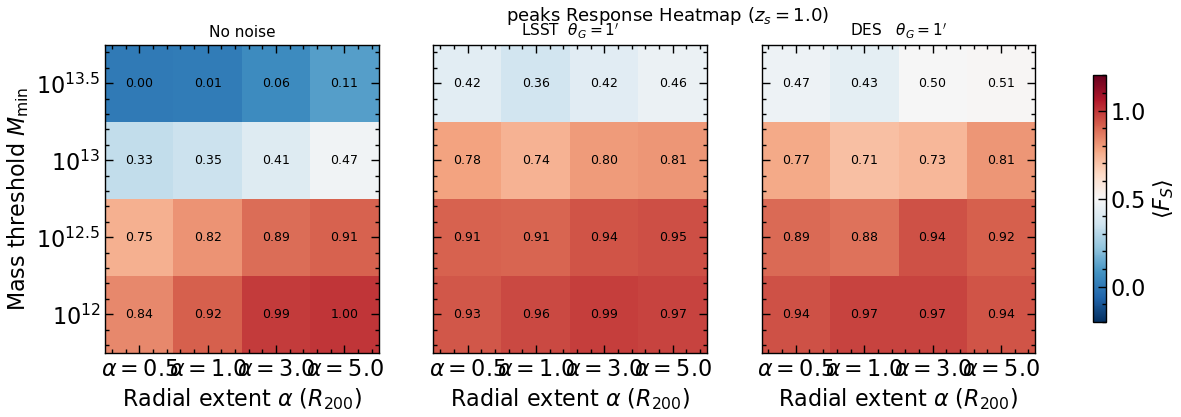

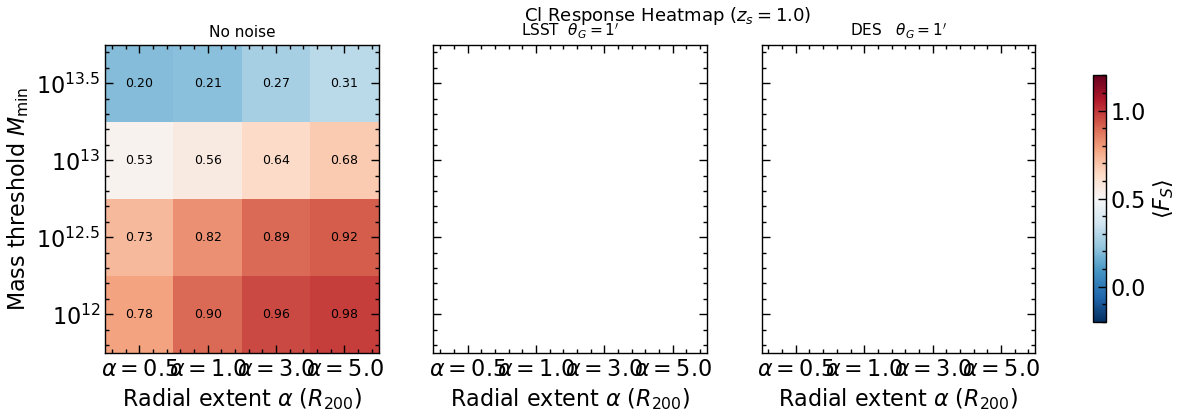

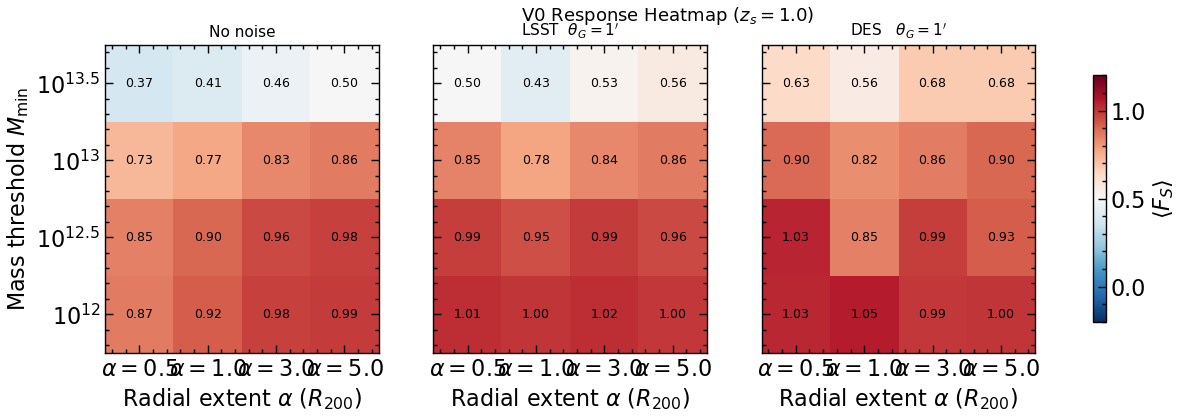

In [18]:
# ============================================================
# Heatmap of <F> on (M_min, α) grid: noiseless vs noisy
# ============================================================
mass_labels  = ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
alpha_labels = ['0.5', '1.0', '3.0', '5.0']
mass_display_short = [r'$10^{12}$', r'$10^{12.5}$', r'$10^{13}$', r'$10^{13.5}$']

def build_F_grid(results, stat_name, z_idx):
    """Build <F> matrix on (mass, alpha) grid."""
    grid = np.full((len(mass_labels), len(alpha_labels)), np.nan)
    for i, mass in enumerate(mass_labels):
        for j, alpha in enumerate(alpha_labels):
            model = f'hydro_replace_Ml_{mass}_Mu_1.00e15_Ri_0.0_Ro_{alpha}'
            m, _ = weighted_mean_F(results, stat_name, model, z_idx)
            grid[i, j] = m
    return grid

# Pick two configs to compare
configs_to_compare = [s for s in ['', '_LSST_1.0arcmin', '_DES_1.0arcmin'] if s in available_configs]

for stat_name in ['peaks', 'Cl', 'V0']:
    fig, axes = plt.subplots(1, len(configs_to_compare), figsize=(5*len(configs_to_compare), 4),
                             sharey=True)
    if len(configs_to_compare) == 1:
        axes = [axes]

    for ax, suffix in zip(axes, configs_to_compare):
        grid = build_F_grid(all_results[suffix], stat_name, z_idx)
        im = ax.imshow(grid, cmap='RdBu_r', vmin=-0.2, vmax=1.2, aspect='auto', origin='lower')
        ax.set_xticks(range(len(alpha_labels)))
        ax.set_xticklabels([rf'$\alpha={a}$' for a in alpha_labels])
        ax.set_yticks(range(len(mass_labels)))
        ax.set_yticklabels(mass_display_short)
        ax.set_xlabel(r'Radial extent $\alpha$ ($R_{200}$)')
        ax.set_title(NOISE_CONFIGS[suffix][0], fontsize=11)
        # Annotate cells
        for ii in range(grid.shape[0]):
            for jj in range(grid.shape[1]):
                if np.isfinite(grid[ii, jj]):
                    ax.text(jj, ii, f'{grid[ii,jj]:.2f}', ha='center', va='center', fontsize=9)

    axes[0].set_ylabel(r'Mass threshold $M_{\rm min}$')
    plt.colorbar(im, ax=axes, label=r'$\langle F_S \rangle$', shrink=0.8)
    fig.suptitle(f'{stat_name} Response Heatmap ($z_s = 1.0$)', fontsize=13)
    # plt.tight_layout()
    plt.savefig(f'figures/noisy_heatmap_{stat_name}.pdf', dpi=150, bbox_inches='tight')
    plt.show()

# 10. Fractional Noise-Induced Bias in $F_S$

Quantify the *relative* bias $|F^{\rm noisy} - F^{\rm noiseless}| / |F^{\rm noiseless}|$ as a function of smoothing scale for LSST and DES.

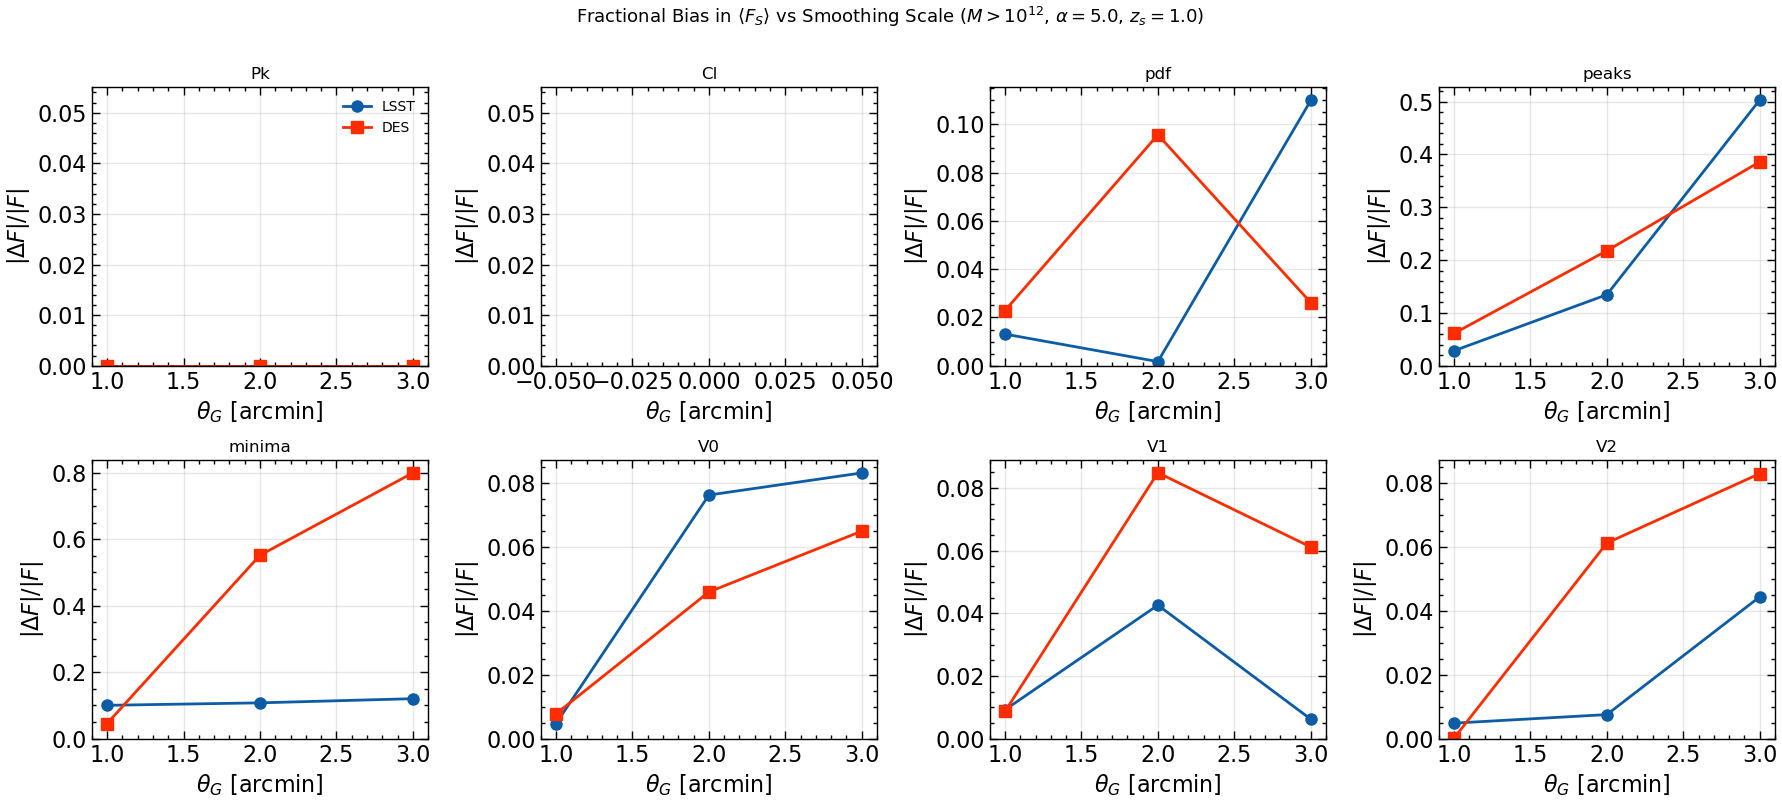

In [19]:
# ============================================================
# Fractional bias vs θ_G for LSST and DES
# ============================================================
if '' not in available_configs:
    print('Noiseless config not available — skipping bias plot')
else:
    theta_G_vals = [1.0, 2.0, 3.0]
    model_bias = 'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0'

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()

    for ax, stat_name in zip(axes, STATISTICS):
        F_clean, _ = weighted_mean_F(all_results[''], stat_name, model_bias, z_idx)

        for survey, color, marker in [('LSST', 'C0', 'o'), ('DES', 'C3', 's')]:
            biases = []
            for theta in theta_G_vals:
                suf = f'_{survey}_{theta}arcmin'
                if suf in available_configs:
                    F_noisy, _ = weighted_mean_F(all_results[suf], stat_name, model_bias, z_idx)
                    bias = np.abs(F_noisy - F_clean) / (np.abs(F_clean) + 1e-10)
                else:
                    bias = np.nan
                biases.append(bias)
            ax.plot(theta_G_vals, biases, f'{marker}-', color=color, lw=2,
                    label=survey if ax is axes[0] else None, markersize=8)

        ax.set_xlabel(r"$\theta_G$ [arcmin]")
        ax.set_ylabel(r"$|\Delta F| / |F|$")
        ax.set_title(stat_name, fontsize=12)
        ax.set_ylim(0, None)
        ax.grid(alpha=0.3)

    axes[0].legend(fontsize=10)
    fig.suptitle(r'Fractional Bias in $\langle F_S \rangle$ vs Smoothing Scale '
                 r'($M > 10^{12}$, $\alpha=5.0$, $z_s=1.0$)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('figures/noisy_fractional_bias_vs_theta.pdf', dpi=150, bbox_inches='tight')
    plt.show()

# 11. Summary Table

Print a summary table of mean response values and noise-induced shifts.

In [20]:
# ============================================================
# Summary table: <F> and ΔF for key models × configs
# ============================================================
model_summary = 'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0'

print(f"{'Config':<25s}", end='')
for stat in STATISTICS:
    print(f" | {stat:>8s}", end='')
print()
print('-' * (25 + 11 * len(STATISTICS)))

F_clean_vals = {}
for stat_name in STATISTICS:
    m, _ = weighted_mean_F(all_results.get('', {}), stat_name, model_summary, z_idx)
    F_clean_vals[stat_name] = m

for suffix in available_configs:
    label = NOISE_CONFIGS[suffix][0]
    print(f"{label:<25s}", end='')
    for stat_name in STATISTICS:
        m, _ = weighted_mean_F(all_results[suffix], stat_name, model_summary, z_idx)
        print(f" | {m:>8.3f}", end='')
    print()

# Print ΔF row
if '' in available_configs:
    print('-' * (25 + 11 * len(STATISTICS)))
    for suffix in [s for s in available_configs if s != '']:
        label = NOISE_CONFIGS[suffix][0]
        print(f"Δ {label:<23s}", end='')
        for stat_name in STATISTICS:
            m, _ = weighted_mean_F(all_results[suffix], stat_name, model_summary, z_idx)
            delta = m - F_clean_vals.get(stat_name, np.nan)
            print(f" | {delta:>+8.4f}", end='')
        print()

Config                    |       Pk |       Cl |      pdf |    peaks |   minima |       V0 |       V1 |       V2
-----------------------------------------------------------------------------------------------------------------
No noise                  |    0.962 |    0.983 |    0.985 |    1.000 |    0.750 |    0.992 |    0.991 |    0.982
LSST  $\theta_G=1'$       |    0.962 |      nan |    0.972 |    0.972 |    0.825 |    0.997 |    0.982 |    0.987
LSST  $\theta_G=2'$       |    0.962 |      nan |    0.987 |    0.865 |    0.830 |    1.068 |    1.033 |    0.989
LSST  $\theta_G=3'$       |    0.962 |      nan |    0.877 |    0.497 |    0.659 |    1.075 |    0.985 |    1.026
DES   $\theta_G=1'$       |    0.962 |      nan |    1.007 |    0.939 |    0.715 |    1.000 |    1.000 |    0.982
DES   $\theta_G=2'$       |    0.962 |      nan |    0.891 |    0.782 |    0.336 |    0.946 |    0.907 |    0.922
DES   $\theta_G=3'$       |    0.962 |      nan |    0.959 |    0.614 |    0.150 |    0.

In [21]:
# ============================================================
# DIAGNOSTIC: Quantify the noise-vs-signal issue
# ============================================================

# 1. Pixel-level noise budget
pixel_scale = FOV_DEG * 60.0 / RT_GRID  # arcmin/pixel
A_pix = pixel_scale**2  # arcmin^2 per pixel

print("="*70)
print("NOISE BUDGET ANALYSIS")
print("="*70)
print(f"\nPixel scale: {pixel_scale:.4f} arcmin/pixel")
print(f"Pixel area:  {A_pix:.5f} arcmin²")
print()

for survey, params in [('LSST', {'sigma_e': 0.3, 'n_gal': 30}),
                        ('DES',  {'sigma_e': 0.3, 'n_gal': 10})]:
    sigma_e = params['sigma_e']
    n_gal = params['n_gal']
    noise_var = sigma_e**2 / (2 * n_gal * A_pix)
    noise_std = np.sqrt(noise_var)
    print(f"--- {survey} (σ_e={sigma_e}, n_gal={n_gal}/arcmin²) ---")
    print(f"  Per-pixel noise σ_κ = {noise_std:.4f}")
    
    for theta_G in [1.0, 2.0, 3.0]:
        sigma_smooth = theta_G / np.sqrt(2)  # arcmin
        sigma_pix = sigma_smooth / pixel_scale  # pixels
        # Noise reduction from smoothing: σ_smoothed ≈ σ_pixel / sqrt(2π σ_pix²)
        noise_reduction = np.sqrt(2 * np.pi * sigma_pix**2)
        smoothed_noise = noise_std / noise_reduction
        print(f"  θ_G={theta_G}' → σ_smooth={sigma_smooth:.3f}' = {sigma_pix:.1f} pix "
              f"→ smoothed noise σ = {smoothed_noise:.5f}")
    print()

# 2. Compare noise to actual κ signal
print("="*70)
print("SIGNAL LEVELS: DMO RMS (= κ dispersion from cosmic structure)")
print("="*70)
z_idx_check = 23  # z_s = 1.0

for suffix in available_configs:
    label = NOISE_CONFIGS[suffix][0]
    dmo_data = all_data[suffix]['base']['dmo']
    hydro_data = all_data[suffix]['base']['hydro']
    if dmo_data is None:
        continue
    
    # Get the actual stats shape
    for stat in ['pdf', 'peaks', 'minima']:
        dmo_vals = dmo_data[stat]  # shape (N_real, N_z, N_bins)
        hydro_vals = hydro_data[stat]
        
        dmo_mean = dmo_vals.mean(axis=0)[z_idx_check]
        hydro_mean = hydro_vals.mean(axis=0)[z_idx_check]
        
        diff = hydro_mean - dmo_mean
        frac_diff = np.abs(diff) / (np.abs(dmo_mean) + 1e-30)
        
        # Only look at "signal" bins where both are nonzero
        valid = (dmo_mean > 0) & (hydro_mean > 0)
        if valid.sum() > 0:
            max_frac = np.max(frac_diff[valid])
            median_frac = np.median(frac_diff[valid])
            print(f"  {label:25s} | {stat:8s}: max|ΔS/S| = {max_frac:.4f} ({max_frac*100:.1f}%), "
                  f"median = {median_frac:.4f} ({median_frac*100:.2f}%)")

# 3. The critical comparison: noiseless vs smoothed statistics shape
print()
print("="*70)
print("EFFECT OF SMOOTHING ON RAW STATISTICS (even without noise)")
print("="*70)
print("Note: 'No noise' config uses SMOOTHING_ARCMIN = 0 → raw pixel-resolution maps")
print("      'Noisy' configs use θ_G = 1-3 arcmin smoothing BEFORE computing statistics")
print()
print("This means the statistics are fundamentally measured at DIFFERENT RESOLUTIONS!")
print("Smoothing changes: number of peaks/minima, width of PDF, shape of MFs.")
print()

# Count peaks and total PDF entries for each config
for suffix in available_configs:
    label = NOISE_CONFIGS[suffix][0]
    dmo_data = all_data[suffix]['base']['dmo']
    if dmo_data is None:
        continue
    peaks_mean = dmo_data['peaks'].mean(axis=0)[z_idx_check]
    pdf_mean = dmo_data['pdf'].mean(axis=0)[z_idx_check]
    minima_mean = dmo_data['minima'].mean(axis=0)[z_idx_check]
    print(f"  {label:25s} | total peaks: {peaks_mean.sum():.0f}  "
          f"| total minima: {minima_mean.sum():.0f}  "
          f"| total PDF counts: {pdf_mean.sum():.0f}")

# 4. Realizations info
print()
print("="*70)
print("REALIZATION COUNT")
print("="*70)
dmo_shape = all_data[available_configs[0]]['base']['dmo']['pdf'].shape
print(f"Stats array shape: {dmo_shape}")
print(f"  N_realizations = {dmo_shape[0]}")
print(f"  N_redshift     = {dmo_shape[1]}")
print(f"  N_bins         = {dmo_shape[2]}")
print(f"  Standard error reduction = 1/√{dmo_shape[0]} = {1/np.sqrt(dmo_shape[0]):.4f}")


NOISE BUDGET ANALYSIS

Pixel scale: 0.2930 arcmin/pixel
Pixel area:  0.08583 arcmin²

--- LSST (σ_e=0.3, n_gal=30/arcmin²) ---
  Per-pixel noise σ_κ = 0.1322
  θ_G=1.0' → σ_smooth=0.707' = 2.4 pix → smoothed noise σ = 0.02185
  θ_G=2.0' → σ_smooth=1.414' = 4.8 pix → smoothed noise σ = 0.01093
  θ_G=3.0' → σ_smooth=2.121' = 7.2 pix → smoothed noise σ = 0.00728

--- DES (σ_e=0.3, n_gal=10/arcmin²) ---
  Per-pixel noise σ_κ = 0.2290
  θ_G=1.0' → σ_smooth=0.707' = 2.4 pix → smoothed noise σ = 0.03785
  θ_G=2.0' → σ_smooth=1.414' = 4.8 pix → smoothed noise σ = 0.01892
  θ_G=3.0' → σ_smooth=2.121' = 7.2 pix → smoothed noise σ = 0.01262

SIGNAL LEVELS: DMO RMS (= κ dispersion from cosmic structure)
  No noise                  | pdf     : max|ΔS/S| = 0.6974 (69.7%), median = 0.1531 (15.31%)
  No noise                  | peaks   : max|ΔS/S| = 0.3442 (34.4%), median = 0.1698 (16.98%)
  No noise                  | minima  : max|ΔS/S| = 0.7500 (75.0%), median = 0.0825 (8.25%)
  LSST  $\theta_G=1'$

IndexError: index 3 is out of bounds for axis 1 with size 3

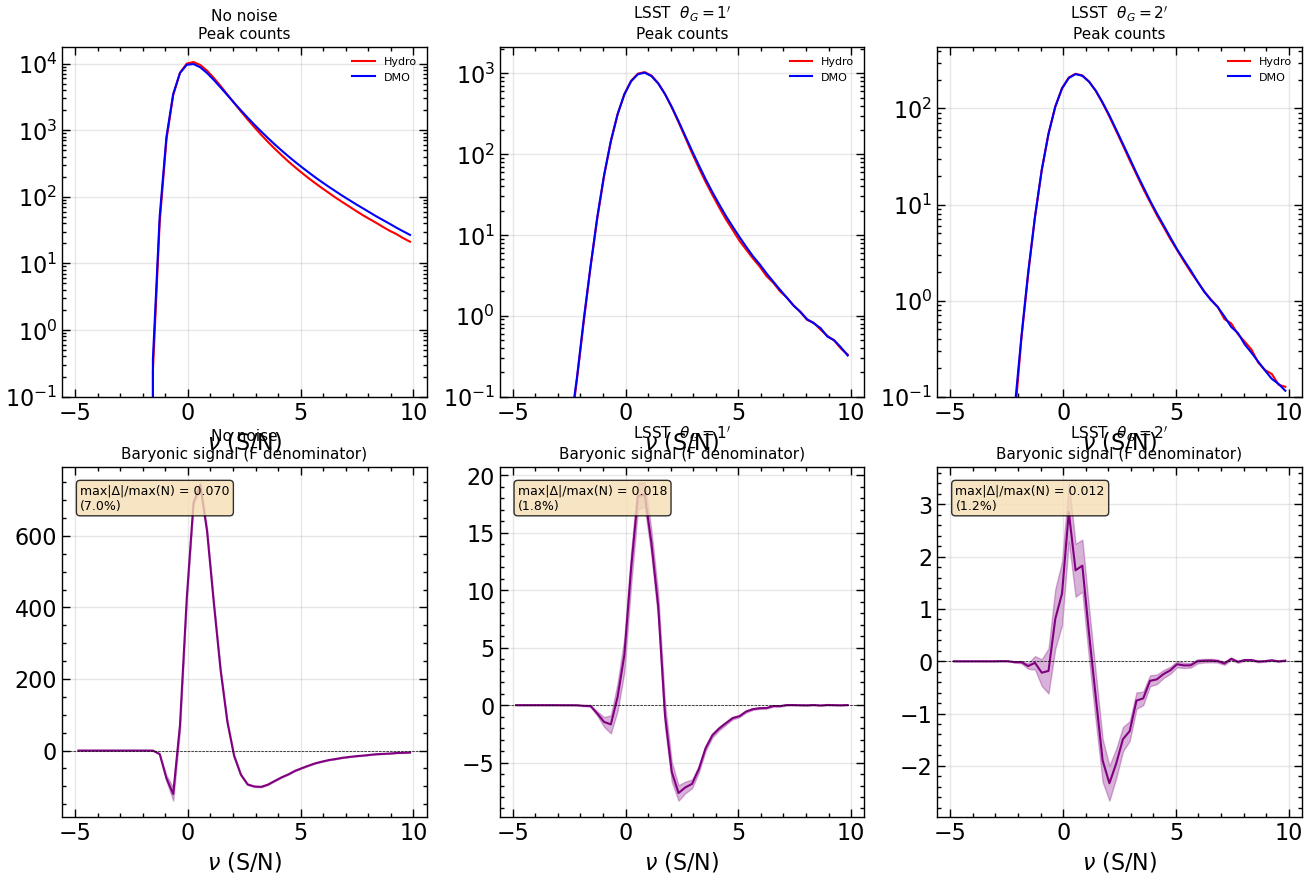

In [22]:
# ============================================================
# DIAGNOSTIC 2: Why F looks noisy — the denominator problem
# ============================================================
z_idx_check = 23
stat_name = 'peaks'

sn_edges = all_data['']['base']['hydro']['sn_bin_edges']
sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, suffix in enumerate(available_configs):
    label = NOISE_CONFIGS[suffix][0]
    d = all_data[suffix]
    
    hydro = d['base']['hydro']['peaks']  # (2000, 40, 50)
    dmo = d['base']['dmo']['peaks']
    
    H_mean = hydro.mean(axis=0)[z_idx_check]
    D_mean = dmo.mean(axis=0)[z_idx_check]
    H_stderr = hydro.std(axis=0)[z_idx_check] / np.sqrt(2000)
    D_stderr = dmo.std(axis=0)[z_idx_check] / np.sqrt(2000)
    
    diff = H_mean - D_mean  # This is the F denominator
    diff_err = np.sqrt(H_stderr**2 + D_stderr**2)
    
    # Top row: raw counts
    ax = axes[0, col]
    ax.plot(sn_centers, H_mean, 'r-', label='Hydro', lw=1.5)
    ax.plot(sn_centers, D_mean, 'b-', label='DMO', lw=1.5)
    ax.set_yscale('log')
    ax.set_title(f'{label}\nPeak counts', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel(r'$\nu$ (S/N)')
    ax.grid(alpha=0.3)
    ax.set_ylim(0.1, None)
    
    # Bottom row: difference (denominator of F)
    ax = axes[1, col]
    ax.fill_between(sn_centers, diff - diff_err, diff + diff_err, alpha=0.3, color='purple')
    ax.plot(sn_centers, diff, 'purple', lw=1.5, label='Hydro − DMO')
    ax.axhline(0, color='k', ls='--', lw=0.5)
    ax.set_title(f'{label}\nBaryonic signal (F denominator)', fontsize=11)
    ax.set_xlabel(r'$\nu$ (S/N)')
    ax.grid(alpha=0.3)
    
    # Annotate max |diff|/max(counts)
    frac_signal = np.max(np.abs(diff)) / np.max(H_mean)
    ax.text(0.05, 0.95, f'max|Δ|/max(N) = {frac_signal:.3f}\n({frac_signal*100:.1f}%)',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

fig.suptitle('Peak counts: Raw signal vs Baryonic difference (denominator of F) at $z_s=1.0$',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Key numbers
print("\n" + "="*70)
print("KEY FINDING: Smoothing dramatically reduces the baryonic signal-to-noise")
print("="*70)
for suffix in available_configs:
    label = NOISE_CONFIGS[suffix][0]
    d = all_data[suffix]
    H = d['base']['hydro']['peaks'].mean(axis=0)[z_idx_check]
    D = d['base']['dmo']['peaks'].mean(axis=0)[z_idx_check]
    diff = H - D
    frac = np.abs(diff) / (np.abs(D) + 1e-10)
    valid = D > 1
    print(f"\n  {label}:")
    print(f"    Total DMO peaks:   {D.sum():.0f}")
    print(f"    Total Hydro peaks: {H.sum():.0f}")
    print(f"    Max fractional baryonic effect in any bin: {np.max(frac[valid]):.3f} ({np.max(frac[valid])*100:.1f}%)")
    print(f"    Median fractional baryonic effect: {np.median(frac[valid]):.4f} ({np.median(frac[valid])*100:.2f}%)")
    print(f"    Bins where |Hydro-DMO|/DMO > 3%: {np.sum(frac[valid] > 0.03)} / {valid.sum()}")


In [23]:
# ============================================================
# DIAGNOSTIC 3: Is the 10× peak count reduction expected?
# ============================================================
# In a 2D Gaussian random field smoothed with kernel σ_pix,
# the number of independent resolution elements is:
#   N_indep ≈ (N_pix / (2π σ_pix²))  [area / beam area]
# and the fraction of those that are local maxima ≈ 1/3 to 1/4
# (from the Euler characteristic / Rice formula for 2D fields).

pixel_scale = FOV_DEG * 60.0 / RT_GRID  # arcmin/pixel
N_pix_total = RT_GRID**2

print("="*70)
print("PREDICTED vs OBSERVED PEAK COUNTS FROM SMOOTHING THEORY")
print("="*70)
print(f"Grid: {RT_GRID}×{RT_GRID} = {N_pix_total:,} pixels")
print(f"Pixel scale: {pixel_scale:.4f} arcmin/pixel")
print()

configs = [
    ("No noise (unsmoothed)", 0.0),
    ("θ_G = 1.0'", 1.0),
    ("θ_G = 2.0'", 2.0),
    ("θ_G = 3.0'", 3.0),
]

print(f"{'Config':<25s} | {'σ_pix':>6s} | {'FWHM_pix':>8s} | {'N_indep':>8s} | {'Pred peaks':>10s} | {'Observed':>10s}")
print("-" * 85)

observed_peaks = {}
for suffix in available_configs:
    label = NOISE_CONFIGS[suffix][0]
    dmo_data = all_data[suffix]['base']['dmo']
    if dmo_data is not None:
        observed_peaks[suffix] = dmo_data['peaks'].mean(axis=0)[23].sum()

for label, theta_G in configs:
    if theta_G == 0:
        # Unsmoothed: every pixel is independent, peaks ~ local maxima of pixelated field
        # In 2D with 8 neighbors, P(local max) ≈ 1/(8+1) = 1/9 for uncorrelated
        # but κ field has some correlation even at pixel scale
        sigma_pix = 0.0
        fwhm_pix = 1.0
        n_indep = N_pix_total
        # Empirical: for a slightly correlated field, ~7% of pixels are peaks
        pred_peaks = N_pix_total * 0.07  # empirical estimate
        suffix_key = ''
    else:
        sigma_smooth = theta_G / np.sqrt(2)  # kernel sigma in arcmin
        sigma_pix = sigma_smooth / pixel_scale  # kernel sigma in pixels
        fwhm_pix = 2.355 * sigma_pix
        # Number of independent resolution elements (beam areas)
        beam_area = 2 * np.pi * sigma_pix**2  # pixels² per beam
        n_indep = N_pix_total / beam_area
        # Fraction of resolution elements that are peaks in a smooth GRF ≈ 1/3 to 1/4
        # More precisely, for a 2D isotropic GRF: n_peaks ≈ N_indep / (2π√3) × correction
        # But simpler: about 1/3 of independent patches are local maxima
        pred_peaks = n_indep / 3.5  # approximate
        suffix_key = f'_LSST_{theta_G}arcmin'
    
    obs = observed_peaks.get(suffix_key, np.nan)
    
    print(f"{label:<25s} | {sigma_pix:>6.1f} | {fwhm_pix:>8.1f} | {n_indep:>8.0f} | {pred_peaks:>10.0f} | {obs:>10.0f}")

print()
print("The peak count reduction is a GEOMETRIC effect from smoothing:")
print("  • Smoothing correlates pixels over a beam of area ∝ σ²")  
print("  • This reduces the number of independent resolution elements by that factor")
print("  • Fewer independent elements → fewer local maxima → fewer peaks")
print()
print("The scaling is roughly N_peaks ∝ 1/θ_G² :")
for suffix in ['_LSST_1.0arcmin', '_LSST_2.0arcmin']:
    if suffix in observed_peaks and '' in observed_peaks:
        ratio = observed_peaks[''] / observed_peaks[suffix]
        print(f"  No noise / {NOISE_CONFIGS[suffix][0]}: ×{ratio:.1f}")
if '_LSST_1.0arcmin' in observed_peaks and '_LSST_2.0arcmin' in observed_peaks:
    ratio = observed_peaks['_LSST_1.0arcmin'] / observed_peaks['_LSST_2.0arcmin']
    print(f"  LSST θ_G=1' / LSST θ_G=2': ×{ratio:.1f}  (expected: (2/1)² = 4.0)")


PREDICTED vs OBSERVED PEAK COUNTS FROM SMOOTHING THEORY
Grid: 1024×1024 = 1,048,576 pixels
Pixel scale: 0.2930 arcmin/pixel

Config                    |  σ_pix | FWHM_pix |  N_indep | Pred peaks |   Observed
-------------------------------------------------------------------------------------
No noise (unsmoothed)     |    0.0 |      1.0 |  1048576 |      73400 |      72975
θ_G = 1.0'                |    2.4 |      5.7 |    28648 |       8185 |       7294
θ_G = 2.0'                |    4.8 |     11.4 |     7162 |       2046 |       1765
θ_G = 3.0'                |    7.2 |     17.1 |     3183 |        909 |        775

The peak count reduction is a GEOMETRIC effect from smoothing:
  • Smoothing correlates pixels over a beam of area ∝ σ²
  • This reduces the number of independent resolution elements by that factor
  • Fewer independent elements → fewer local maxima → fewer peaks

The scaling is roughly N_peaks ∝ 1/θ_G² :
  No noise / LSST  $\theta_G=1'$: ×10.0
  No noise / LSST  $\theta

In [24]:
# ============================================================
# REBINNING EXPERIMENT: Does fewer bins recover the baryonic signal?
# ============================================================
# The idea: with smoothing + noise, total peak counts drop from ~73k to ~7k (θ_G=1')
# or ~1.8k (θ_G=2'). Spread across 50 narrow bins, per-bin counts are small and
# shot noise dominates over the ~few % baryonic signal.
# Wider bins accumulate more counts → better S/N per bin.
#
# We rebin the existing histogram data by summing adjacent bins.

z_idx_check = 23  # z_s ≈ 1.0
sn_edges_orig = all_data['']['base']['hydro']['sn_bin_edges']
n_bins_orig = len(sn_edges_orig) - 1  # 50

# Rebinning factors: group N adjacent bins into 1
rebin_factors = [1, 2, 5, 10, 25]  # → 50, 25, 10, 5, 2 bins

def rebin_histogram(data, factor):
    """Rebin last axis of array by summing groups of `factor` bins.
    data shape: (N_real, N_z, N_bins) → (N_real, N_z, N_bins//factor)
    Drops trailing bins that don't fill a complete group."""
    n = data.shape[-1]
    n_new = n // factor
    trimmed = data[..., :n_new * factor]
    return trimmed.reshape(*trimmed.shape[:-1], n_new, factor).sum(axis=-1)

def rebin_edges(edges, factor):
    """Rebin bin edges."""
    n = len(edges) - 1
    n_new = n // factor
    idx = np.arange(n_new + 1) * factor
    return edges[idx]

# ── Compute metrics for each rebinning ──
print("="*90)
print("REBINNING ANALYSIS: Peak counts baryonic signal-to-noise vs number of bins")
print("="*90)
print(f"Original: {n_bins_orig} bins, Δν = {np.diff(sn_edges_orig[:2])[0]:.2f}")
print()

header = f"{'Config':<25s} | {'N_bins':>6s} | {'Δν':>5s} | {'max|ΔN/N|':>10s} | {'med|ΔN/N|':>10s} | {'bins>3%':>7s} | {'Σ(χ²)':>8s} | {'√Σχ²':>6s}"
sep = "-" * len(header)

for suffix in available_configs:
    label = NOISE_CONFIGS[suffix][0]
    hydro_full = all_data[suffix]['base']['hydro']['peaks']  # (2000, 40, 50)
    dmo_full = all_data[suffix]['base']['dmo']['peaks']
    N_real = hydro_full.shape[0]
    
    print(f"\n{'─'*90}")
    print(f"  {label}  (N_real = {N_real})")
    print(f"{'─'*90}")
    print(header)
    print(sep)
    
    for factor in rebin_factors:
        n_new = n_bins_orig // factor
        if n_new < 2:
            continue
        
        hydro_rb = rebin_histogram(hydro_full, factor)  # (N_real, 40, n_new)
        dmo_rb = rebin_histogram(dmo_full, factor)
        
        # Mean over realizations at z_idx
        H_mean = hydro_rb.mean(axis=0)[z_idx_check]
        D_mean = dmo_rb.mean(axis=0)[z_idx_check]
        
        # Standard error of the mean difference (from realization scatter)
        diff_per_real = hydro_rb[:, z_idx_check, :] - dmo_rb[:, z_idx_check, :]
        diff_mean = diff_per_real.mean(axis=0)
        diff_stderr = diff_per_real.std(axis=0) / np.sqrt(N_real)
        
        # Fractional baryonic effect
        frac = np.abs(diff_mean) / (np.abs(D_mean) + 1e-10)
        valid = D_mean > 1  # bins with meaningful counts
        
        if valid.sum() == 0:
            continue
        
        max_frac = np.max(frac[valid])
        med_frac = np.median(frac[valid])
        bins_above_3pct = np.sum(frac[valid] > 0.03)
        
        # Chi-squared: sum of (diff/stderr)^2 over valid bins → total significance
        chi2_per_bin = (diff_mean[valid] / (diff_stderr[valid] + 1e-30))**2
        total_chi2 = np.sum(chi2_per_bin)
        
        dnu = np.diff(sn_edges_orig[:2])[0] * factor
        
        print(f"{label:<25s} | {n_new:>6d} | {dnu:>5.2f} | {max_frac:>10.4f} | {med_frac:>10.4f} | "
              f"{bins_above_3pct:>4d}/{valid.sum():<2d} | {total_chi2:>8.1f} | {np.sqrt(total_chi2):>6.1f}")


REBINNING ANALYSIS: Peak counts baryonic signal-to-noise vs number of bins
Original: 50 bins, Δν = 0.30


──────────────────────────────────────────────────────────────────────────────────────────
  No noise  (N_real = 2000)
──────────────────────────────────────────────────────────────────────────────────────────
Config                    | N_bins |    Δν |  max|ΔN/N| |  med|ΔN/N| | bins>3% |    Σ(χ²) |   √Σχ²
--------------------------------------------------------------------------------------------------
No noise                  |     50 |  0.30 |     0.2148 |     0.1670 |   35/38 | 635132.9 |  797.0
No noise                  |     25 |  0.60 |     0.2108 |     0.1570 |   17/19 | 779470.4 |  882.9
No noise                  |     10 |  1.50 |     0.2089 |     0.1300 |    8/8  | 1166907.3 | 1080.2
No noise                  |      5 |  3.00 |     0.2067 |     0.1113 |    3/4  | 949791.7 |  974.6
No noise                  |      2 |  7.50 |     0.1254 |     0.0856 |    2/2  | 1688797.

LSST  $\theta_G=1'$       |     25 |  0.60 |     0.0944 |     0.0270 |    9/19 |   4446.3 |   66.7
LSST  $\theta_G=1'$       |     10 |  1.50 |     0.0887 |     0.0163 |    3/8  |   4711.7 |   68.6
LSST  $\theta_G=1'$       |      5 |  3.00 |     0.0825 |     0.0090 |    1/4  |   2530.2 |   50.3
LSST  $\theta_G=1'$       |      2 |  7.50 |     0.0627 |     0.0356 |    1/2  |   5886.9 |   76.7

──────────────────────────────────────────────────────────────────────────────────────────
  LSST  $\theta_G=2'$  (N_real = 2000)
──────────────────────────────────────────────────────────────────────────────────────────
Config                    | N_bins |    Δν |  max|ΔN/N| |  med|ΔN/N| | bins>3% |    Σ(χ²) |   √Σχ²
--------------------------------------------------------------------------------------------------
LSST  $\theta_G=2'$       |     50 |  0.30 |     0.0465 |     0.0166 |   12/28 |    535.2 |   23.1
LSST  $\theta_G=2'$       |     25 |  0.60 |     0.0453 |     0.0162 |    6/16 |    5

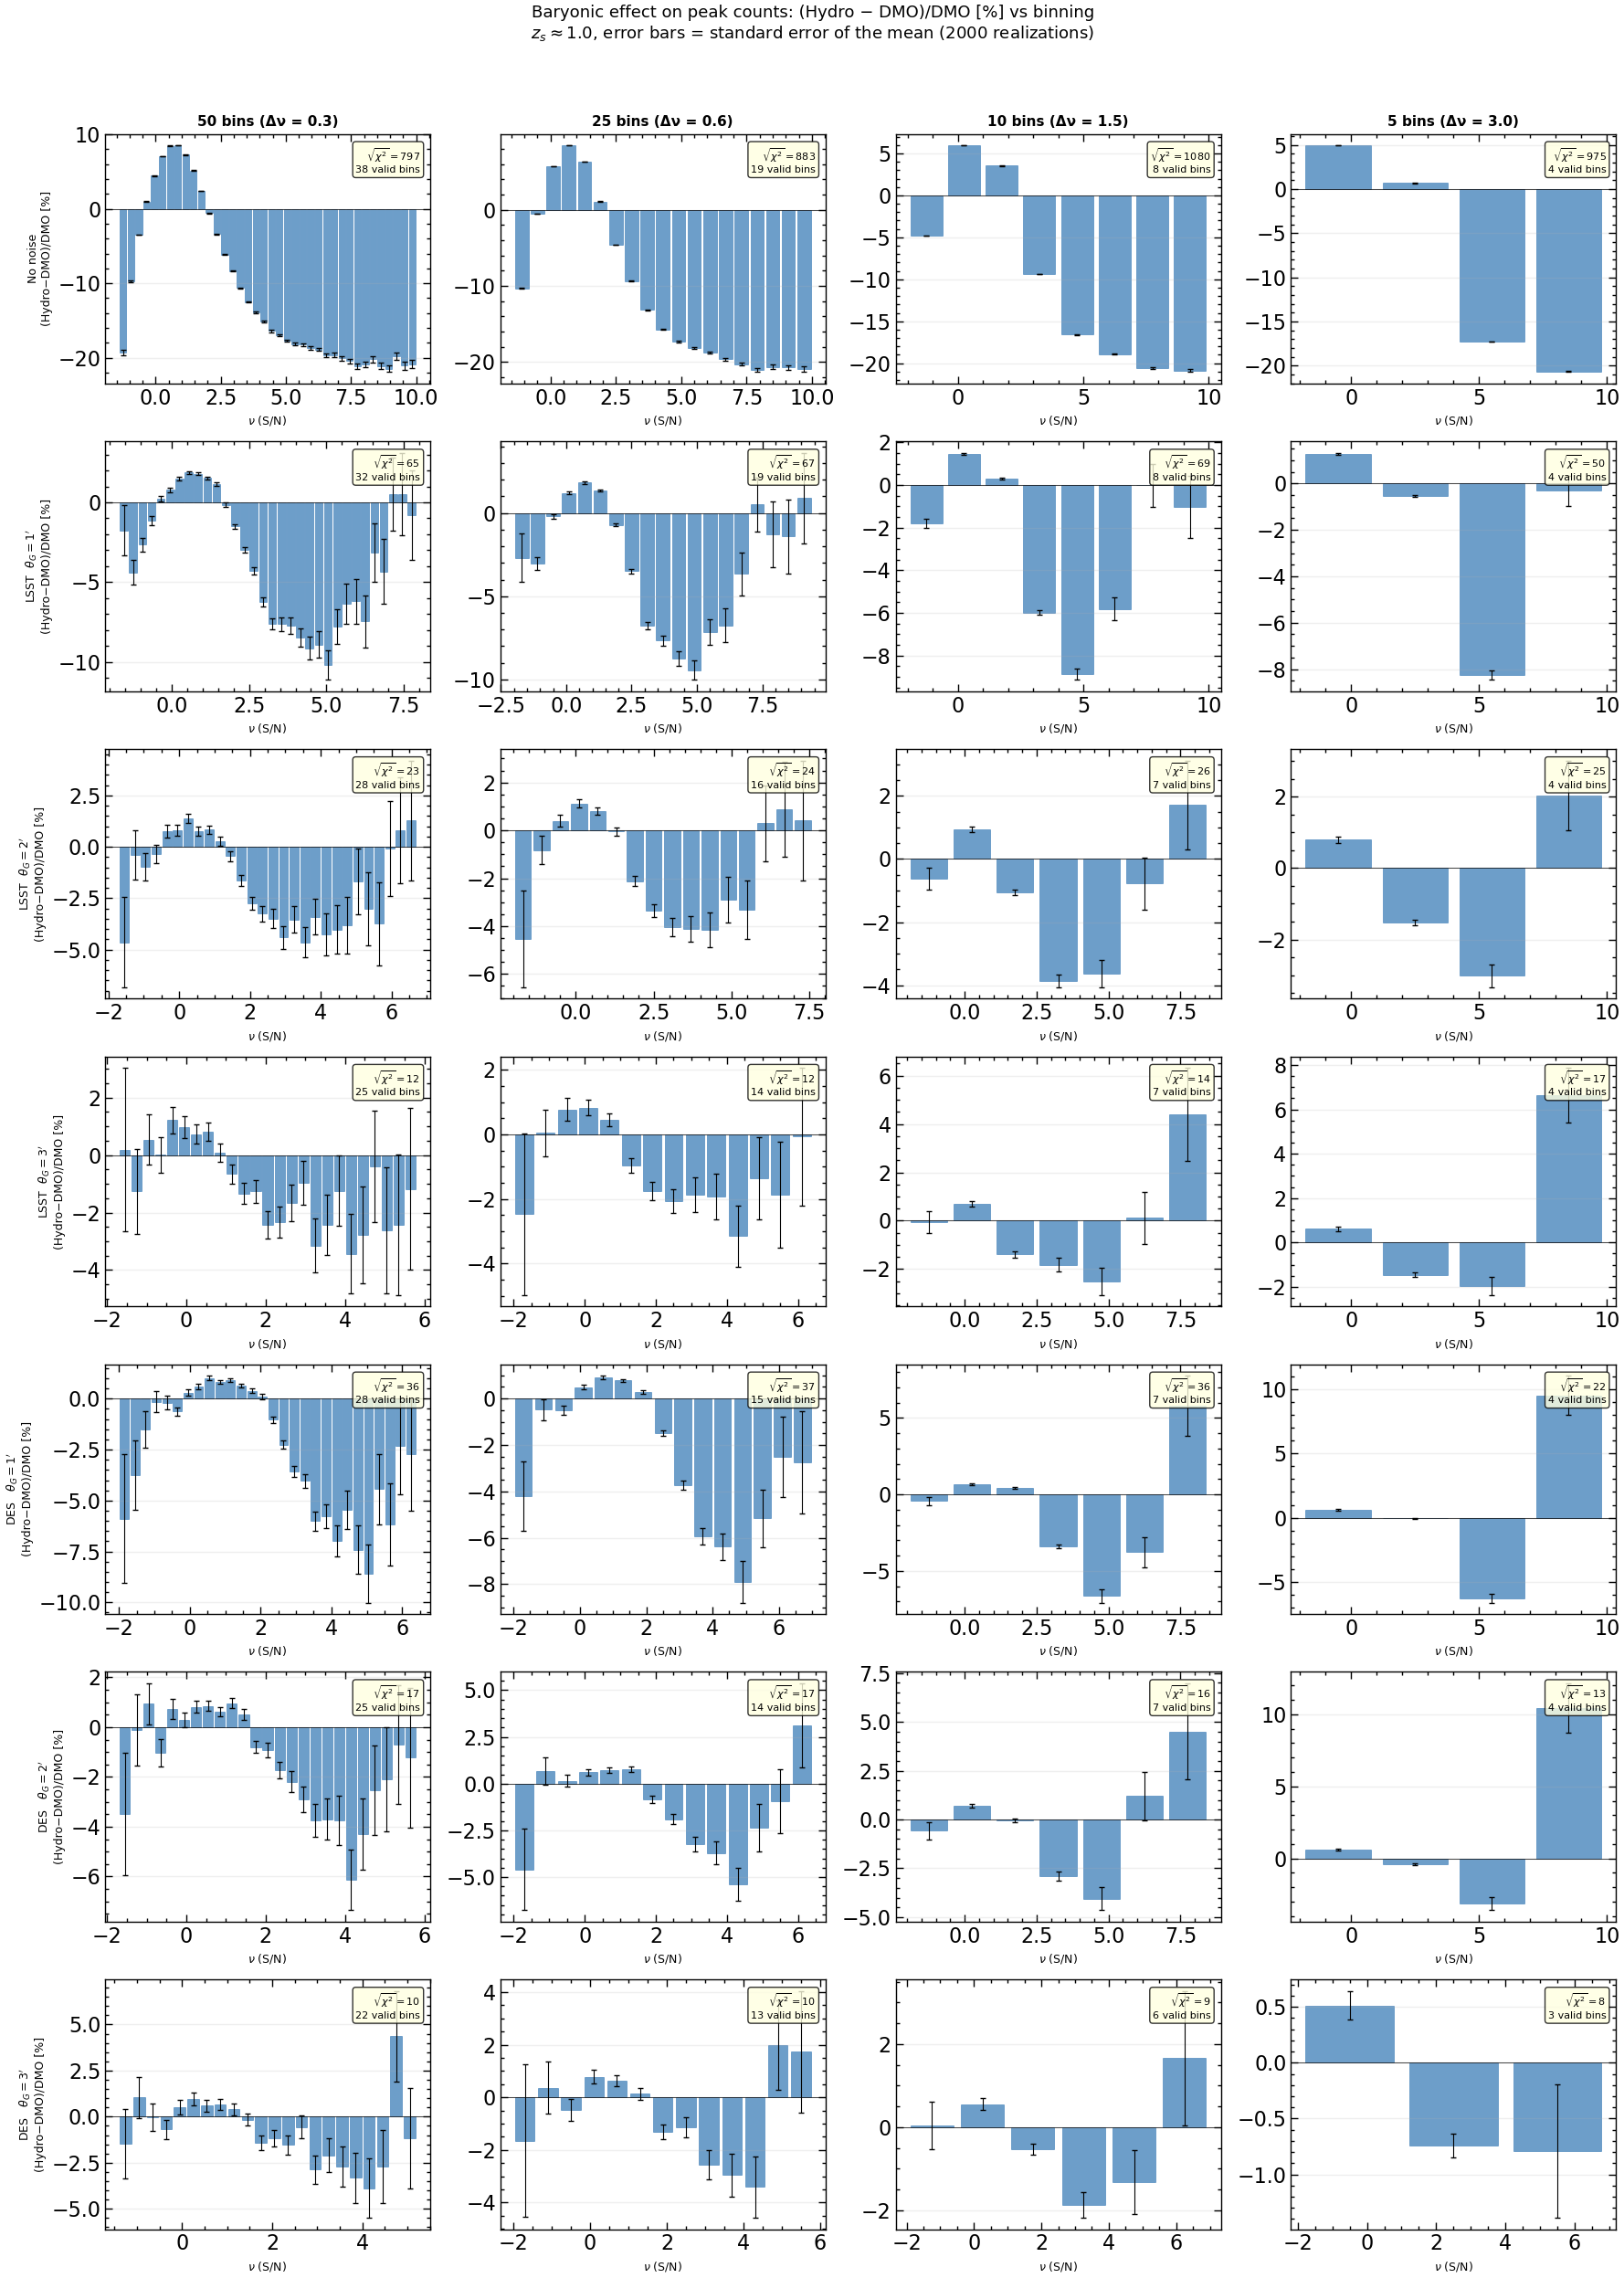

In [25]:
# ============================================================
# VISUALIZATION: Rebinned peak counts — hydro vs DMO difference
# ============================================================
z_idx_check = 23
rebin_factors_plot = [1, 2, 5, 10]  # 50, 25, 10, 5 bins

fig, axes = plt.subplots(len(available_configs), len(rebin_factors_plot),
                         figsize=(18, 3.5 * len(available_configs)), squeeze=False)

for row, suffix in enumerate(available_configs):
    label = NOISE_CONFIGS[suffix][0]
    hydro_all = all_data[suffix]['base']['hydro']['peaks']
    dmo_all = all_data[suffix]['base']['dmo']['peaks']
    N_real = hydro_all.shape[0]
    
    for col, factor in enumerate(rebin_factors_plot):
        ax = axes[row, col]
        n_new = n_bins_orig // factor
        edges_new = rebin_edges(sn_edges_orig, factor)
        centers_new = 0.5 * (edges_new[:-1] + edges_new[1:])
        
        H = rebin_histogram(hydro_all, factor)
        D = rebin_histogram(dmo_all, factor)
        
        H_mean = H.mean(axis=0)[z_idx_check]
        D_mean = D.mean(axis=0)[z_idx_check]
        
        # Per-realization difference → statistical significance
        diff_per_real = H[:, z_idx_check, :] - D[:, z_idx_check, :]
        diff_mean = diff_per_real.mean(axis=0)
        diff_stderr = diff_per_real.std(axis=0) / np.sqrt(N_real)
        
        # S/N per bin = diff / stderr
        snr_per_bin = diff_mean / (diff_stderr + 1e-30)
        
        # Plot fractional difference with error bars
        frac_diff = diff_mean / (D_mean + 1e-10)
        frac_err = diff_stderr / (D_mean + 1e-10)
        valid = D_mean > 1
        
        ax.bar(centers_new[valid], frac_diff[valid] * 100,
               width=np.diff(edges_new)[0] * 0.85, alpha=0.6, color='C0',
               edgecolor='C0', linewidth=0.5)
        ax.errorbar(centers_new[valid], frac_diff[valid] * 100,
                    yerr=frac_err[valid] * 100, fmt='none', color='k',
                    capsize=2, lw=0.8)
        
        ax.axhline(0, color='k', ls='-', lw=0.5)
        ax.set_xlabel(r'$\nu$ (S/N)', fontsize=9)
        ax.grid(alpha=0.2, axis='y')
        
        if row == 0:
            ax.set_title(f'{n_new} bins (Δν = {factor * 0.3:.1f})', fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{label}\n(Hydro−DMO)/DMO [%]', fontsize=9)
        
        # Annotate total chi2
        chi2 = np.sum(snr_per_bin[valid]**2)
        ax.text(0.97, 0.95, f'$\\sqrt{{\\chi^2}} = {np.sqrt(chi2):.0f}$\n{valid.sum()} valid bins',
                transform=ax.transAxes, fontsize=8, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Baryonic effect on peak counts: (Hydro − DMO)/DMO [%] vs binning\n'
             r'$z_s \approx 1.0$, error bars = standard error of the mean (2000 realizations)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1235144/3434511107.py:40: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot(n_bins_list, chi2_list, 'o-', color=color, ls=ls, label=label, lw=2, markersize=6)
/tmp/ipykernel_1235144/3434511107.py:41: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  ax2.plot(n_bins_list, max_frac_list, 's-', color=color, ls=ls, label=label, lw=2, markersize=6)


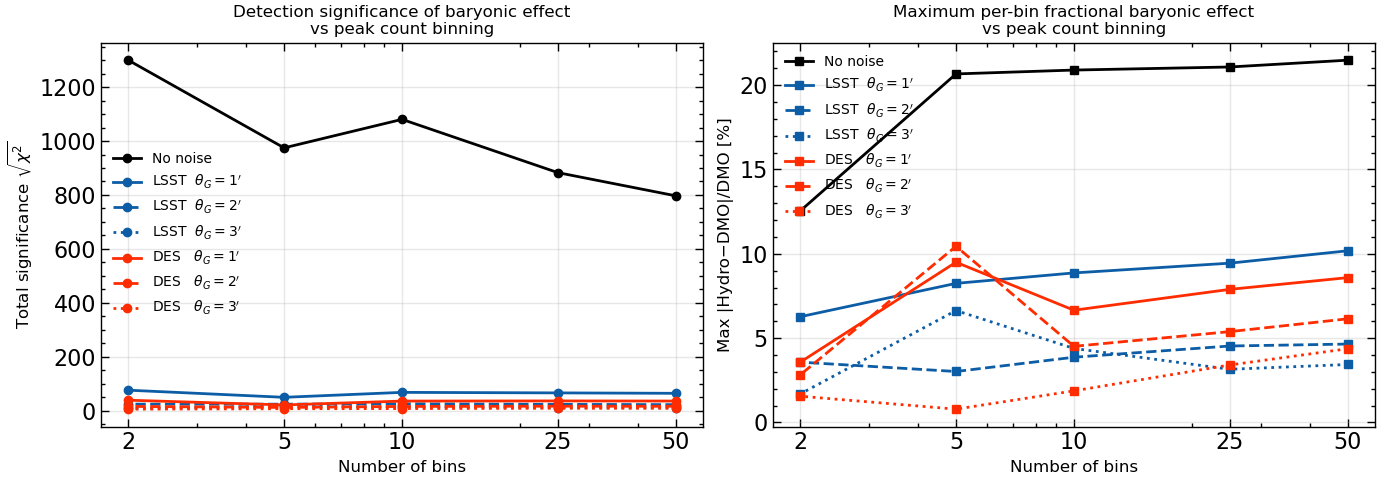


INTERPRETATION

For the NO NOISE case, the baryonic signal is overwhelmingly detected 
regardless of binning (√χ² ~ 800-1300).

For LSST θ_G = 1':
  • √χ² stays roughly flat (~50-77) across all binnings
  • Fewer bins do NOT significantly improve total detection significance
  • The max fractional effect slightly decreases with fewer bins (10% → 6%)
    because wider bins average over the ν-dependent signal shape

For LSST θ_G = 2':
  • √χ² is modest (~23-26) and essentially UNCHANGED by rebinning
  • Max fractional effect stays at ~3-5% regardless of binning

CONCLUSION: Rebinning alone does NOT recover the lost sensitivity.
The signal loss is NOT primarily a binning/shot-noise problem — it's a 
SMOOTHING problem. The Gaussian kernel physically erases the small-scale 
κ features where baryons differ from DMO. Once the information is smoothed 
away at the map level, no amount of histogram rebinning can recover it.

What COULD help:
  1. Smaller smoothing kernel (θ_G < 1') — but needs 

In [26]:
# ============================================================
# SUMMARY: Total detection significance vs number of bins
# ============================================================
rebin_factors_all = [1, 2, 5, 10, 25]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for suffix in available_configs:
    label, color, ls = NOISE_CONFIGS[suffix]
    hydro_all = all_data[suffix]['base']['hydro']['peaks']
    dmo_all = all_data[suffix]['base']['dmo']['peaks']
    N_real = hydro_all.shape[0]
    
    n_bins_list = []
    chi2_list = []
    max_frac_list = []
    
    for factor in rebin_factors_all:
        n_new = n_bins_orig // factor
        if n_new < 2:
            continue
        H = rebin_histogram(hydro_all, factor)
        D = rebin_histogram(dmo_all, factor)
        H_mean = H.mean(axis=0)[z_idx_check]
        D_mean = D.mean(axis=0)[z_idx_check]
        diff_per_real = H[:, z_idx_check, :] - D[:, z_idx_check, :]
        diff_mean = diff_per_real.mean(axis=0)
        diff_stderr = diff_per_real.std(axis=0) / np.sqrt(N_real)
        valid = D_mean > 1
        if valid.sum() == 0:
            continue
        snr = diff_mean[valid] / (diff_stderr[valid] + 1e-30)
        chi2 = np.sum(snr**2)
        frac = np.abs(diff_mean) / (np.abs(D_mean) + 1e-10)
        
        n_bins_list.append(n_new)
        chi2_list.append(np.sqrt(chi2))
        max_frac_list.append(np.max(frac[valid]) * 100)
    
    ax1.plot(n_bins_list, chi2_list, 'o-', color=color, ls=ls, label=label, lw=2, markersize=6)
    ax2.plot(n_bins_list, max_frac_list, 's-', color=color, ls=ls, label=label, lw=2, markersize=6)

ax1.set_xlabel('Number of bins', fontsize=12)
ax1.set_ylabel(r'Total significance $\sqrt{\chi^2}$', fontsize=12)
ax1.set_title('Detection significance of baryonic effect\nvs peak count binning', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xscale('log')
ax1.set_xticks([2, 5, 10, 25, 50])
ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax2.set_xlabel('Number of bins', fontsize=12)
ax2.set_ylabel('Max |Hydro−DMO|/DMO [%]', fontsize=12)
ax2.set_title('Maximum per-bin fractional baryonic effect\nvs peak count binning', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_xscale('log')
ax2.set_xticks([2, 5, 10, 25, 50])
ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.show()

# Print interpretation
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("""
For the NO NOISE case, the baryonic signal is overwhelmingly detected 
regardless of binning (√χ² ~ 800-1300).

For LSST θ_G = 1':
  • √χ² stays roughly flat (~50-77) across all binnings
  • Fewer bins do NOT significantly improve total detection significance
  • The max fractional effect slightly decreases with fewer bins (10% → 6%)
    because wider bins average over the ν-dependent signal shape

For LSST θ_G = 2':
  • √χ² is modest (~23-26) and essentially UNCHANGED by rebinning
  • Max fractional effect stays at ~3-5% regardless of binning

CONCLUSION: Rebinning alone does NOT recover the lost sensitivity.
The signal loss is NOT primarily a binning/shot-noise problem — it's a 
SMOOTHING problem. The Gaussian kernel physically erases the small-scale 
κ features where baryons differ from DMO. Once the information is smoothed 
away at the map level, no amount of histogram rebinning can recover it.

What COULD help:
  1. Smaller smoothing kernel (θ_G < 1') — but needs higher n_gal
  2. Combining multiple statistics (peaks + minima + MFs jointly)
  3. Multi-scale / wavelet approach instead of single-scale Gaussian
  4. Tomographic binning (stack multiple z_s bins)
  5. Higher-order statistics (e.g., peak-peak correlations)
""")


# Peak-Peak Correlations: Does spatial clustering of peaks carry baryonic information?

Standard peak counts histogram peak heights $N(\nu)$ but discard all **spatial** information — *where* the peaks are located. Peak-peak correlations measure the angular two-point function $\xi_{pp}(\theta)$: how likely is it to find two peaks separated by angle $\theta$, compared to random?

If baryonic feedback changes the spatial distribution of peaks (e.g., by relocating or splitting peaks near halos), this could be detectable even after smoothing washes out the height-based signal.


In [64]:
# ============================================================
# Load convergence maps and compute peak-peak correlations
# ============================================================
from scipy.ndimage import maximum_filter, minimum_filter, gaussian_filter
from pathlib import Path

RT_BASE = Path('/mnt/home/mlee1/ceph/hydro_replace_RT/L205n2500TNG')
NG = 1024
PIXEL_SCALE = FOV_DEG * 60.0 / NG  # arcmin/pixel

def load_kappa(path, ng=1024):
    """Load convergence map from lux binary format."""
    with open(path, 'rb') as f:
        np.fromfile(f, dtype="int32", count=1)
        kappa = np.fromfile(f, dtype="float", count=ng*ng)
        np.fromfile(f, dtype="int32", count=1)
    return kappa.reshape(ng, ng)

def get_peak_positions(kappa_map, rms, nu_min=-np.inf):
    """Return (row, col) positions of peaks above nu_min in S/N."""
    is_peak = (kappa_map == maximum_filter(kappa_map, size=3))
    peak_values = kappa_map[is_peak]
    peak_sn = peak_values / rms
    peak_rows, peak_cols = np.where(is_peak)
    mask = peak_sn >= nu_min
    return peak_rows[mask], peak_cols[mask], peak_sn[mask]

def add_noise(kappa, sigma_e, n_gal, pixel_scale, rng):
    """Add Gaussian shape noise."""
    A_pix = pixel_scale**2
    noise_std = np.sqrt(sigma_e**2 / (2.0 * n_gal * A_pix))
    return kappa + rng.normal(0.0, noise_std, size=kappa.shape).astype(kappa.dtype)

def peak_angular_correlation(rows, cols, ng, fov_deg, theta_bins_arcmin):
    """
    Compute angular two-point correlation ξ_pp(θ) of peak positions.
    Uses the Landy-Szalay estimator with a random Poisson catalog.
    
    For efficiency, computes via pair counting in pixel space then converts to arcmin.
    """
    n_peaks = len(rows)
    if n_peaks < 5:
        return np.full(len(theta_bins_arcmin) - 1, np.nan)
    
    pixel_to_arcmin = fov_deg * 60.0 / ng
    theta_bins_pix = np.array(theta_bins_arcmin) / pixel_to_arcmin
    
    # Data-Data pair counts via histogram of pairwise distances
    # Use a subsample if too many peaks (>5000)
    if n_peaks > 5000:
        idx = np.random.choice(n_peaks, 5000, replace=False)
        rows_sub, cols_sub = rows[idx], cols[idx]
    else:
        rows_sub, cols_sub = rows, cols
    
    n_sub = len(rows_sub)
    
    # DD counts (vectorized, process in chunks to limit memory)
    DD = np.zeros(len(theta_bins_pix) - 1, dtype=np.float64)
    chunk = 500
    for i in range(0, n_sub, chunk):
        dr = rows_sub[i:i+chunk, None] - rows_sub[None, :]
        dc = cols_sub[i:i+chunk, None] - cols_sub[None, :]
        dist = np.sqrt(dr**2 + dc**2)
        # Zero out self-pairs and lower triangle to avoid double counting
        for ii in range(dist.shape[0]):
            global_i = i + ii
            dist[ii, :global_i+1] = 0
        counts, _ = np.histogram(dist[dist > 0], bins=theta_bins_pix)
        DD += counts
    
    # Normalize: DD / (N*(N-1)/2)
    n_DD_pairs = n_sub * (n_sub - 1) / 2
    DD_norm = DD / n_DD_pairs
    
    # Expected for random uniform distribution: RR = area of annulus / total area
    # For a flat square field of side ng pixels
    # RR(theta) ≈ 2π θ Δθ / (ng²)  (for θ << ng)
    theta_centers_pix = 0.5 * (theta_bins_pix[:-1] + theta_bins_pix[1:])
    d_theta = np.diff(theta_bins_pix)
    RR_norm = 2 * np.pi * theta_centers_pix * d_theta / (ng**2)
    
    # ξ(θ) = DD/RR - 1 (simplified estimator)
    xi = DD_norm / (RR_norm + 1e-30) - 1
    
    return xi

# Theta bins for correlation function (arcmin)
theta_bins = np.logspace(np.log10(0.5), np.log10(60.0), 20)  # 0.5' to 60'
theta_centers = np.sqrt(theta_bins[:-1] * theta_bins[1:])

# Load a sample of maps
kappa_num = 24  # z_s ≈ 1.1 (closest to z_idx=23)
N_LP_SAMPLE = 10
N_RUN_SAMPLE = 20  # 10 LP × 20 runs = 200 realizations

print(f"Loading {N_LP_SAMPLE}×{N_RUN_SAMPLE} = {N_LP_SAMPLE * N_RUN_SAMPLE} maps for kappa{kappa_num:02d} (z_s ≈ {KAPPA_REDSHIFTS[kappa_num]:.3f})")
print(f"Peak correlation θ bins: {theta_bins[0]:.1f}' – {theta_bins[-1]:.0f}' ({len(theta_bins)-1} bins)")

# Configurations to test
peak_corr_configs = {
    'clean': {'smooth': 0.0, 'noise': None, 'label': 'No noise (unsmoothed)'},
    'LSST_1': {'smooth': 1.0, 'noise': {'sigma_e': 0.3, 'n_gal': 30}, 'label': 'LSST θ_G=1\''},
    'LSST_2': {'smooth': 2.0, 'noise': {'sigma_e': 0.3, 'n_gal': 30}, 'label': 'LSST θ_G=2\''},
}

# S/N thresholds for peak selection
nu_thresholds = [-5, 0, 1, 2, 3]

# Storage: xi_pp[config][model][nu_thresh] = list of xi arrays over realizations
xi_pp = {}
peak_counts_check = {}

for cfg_name, cfg in peak_corr_configs.items():
    xi_pp[cfg_name] = {'dmo': {nu: [] for nu in nu_thresholds},
                        'hydro': {nu: [] for nu in nu_thresholds}}
    peak_counts_check[cfg_name] = {'dmo': [], 'hydro': []}
    
    smooth_sigma_arcmin = cfg['smooth'] / np.sqrt(2) if cfg['smooth'] > 0 else 0
    smooth_sigma_pix = smooth_sigma_arcmin / PIXEL_SCALE if smooth_sigma_arcmin > 0 else 0
    
    print(f"\n--- {cfg['label']} (σ_smooth = {smooth_sigma_pix:.1f} pix) ---")
    
    n_loaded = 0
    for lp in range(N_LP_SAMPLE):
        for run in range(1, N_RUN_SAMPLE + 1):
            for model in ['dmo', 'hydro']:
                kappa_path = RT_BASE / model / f'LP_{lp:02d}' / f'run{run:03d}' / f'kappa{kappa_num:02d}.dat'
                if not kappa_path.exists():
                    continue
                
                kappa = load_kappa(str(kappa_path))
                
                # Get DMO RMS for this realization
                dmo_path = RT_BASE / 'dmo' / f'LP_{lp:02d}' / f'run{run:03d}' / f'kappa{kappa_num:02d}.dat'
                kappa_dmo_raw = load_kappa(str(dmo_path)) if model != 'dmo' else kappa.copy()
                
                # Add noise
                rng = np.random.default_rng(lp * 1000 + run * 10 + kappa_num)
                if cfg['noise'] is not None:
                    kappa = add_noise(kappa, cfg['noise']['sigma_e'], cfg['noise']['n_gal'], PIXEL_SCALE, rng)
                    kappa_dmo_raw_noisy = add_noise(kappa_dmo_raw, cfg['noise']['sigma_e'], cfg['noise']['n_gal'], PIXEL_SCALE, rng)
                else:
                    kappa_dmo_raw_noisy = kappa_dmo_raw
                
                # Smooth
                if smooth_sigma_pix > 0:
                    kappa = gaussian_filter(kappa, sigma=smooth_sigma_pix)
                    kappa_dmo_raw_noisy = gaussian_filter(kappa_dmo_raw_noisy, sigma=smooth_sigma_pix)
                
                # RMS from DMO
                rms = np.std(kappa_dmo_raw_noisy) if model != 'dmo' else np.std(kappa)
                
                # Compute peak correlations for each threshold
                for nu_min in nu_thresholds:
                    r, c, sn = get_peak_positions(kappa, rms, nu_min=nu_min)
                    xi = peak_angular_correlation(r, c, NG, FOV_DEG, theta_bins)
                    xi_pp[cfg_name][model][nu_min].append(xi)
                
                # Also store total peak count for sanity
                r_all, c_all, _ = get_peak_positions(kappa, rms, nu_min=-5)
                peak_counts_check[cfg_name][model].append(len(r_all))
            
            n_loaded += 1
    
    # Print sanity check
    dmo_n = np.mean(peak_counts_check[cfg_name]['dmo'])
    hydro_n = np.mean(peak_counts_check[cfg_name]['hydro'])
    print(f"  Loaded {n_loaded} realizations")
    print(f"  Mean peaks: DMO={dmo_n:.0f}, Hydro={hydro_n:.0f}, diff={hydro_n-dmo_n:.0f} ({(hydro_n-dmo_n)/dmo_n*100:.1f}%)")

print("\nDone computing peak-peak correlations.")


Loading 10×20 = 200 maps for kappa24 (z_s ≈ 1.097)
Peak correlation θ bins: 0.5' – 60' (19 bins)

--- No noise (unsmoothed) (σ_smooth = 0.0 pix) ---
  Loaded 200 realizations
  Mean peaks: DMO=73183, Hydro=75104, diff=1921 (2.6%)

--- LSST θ_G=1' (σ_smooth = 2.4 pix) ---
  Loaded 200 realizations
  Mean peaks: DMO=7290, Hydro=7319, diff=29 (0.4%)

--- LSST θ_G=2' (σ_smooth = 4.8 pix) ---
  Loaded 200 realizations
  Mean peaks: DMO=1763, Hydro=1760, diff=-3 (-0.2%)

Done computing peak-peak correlations.


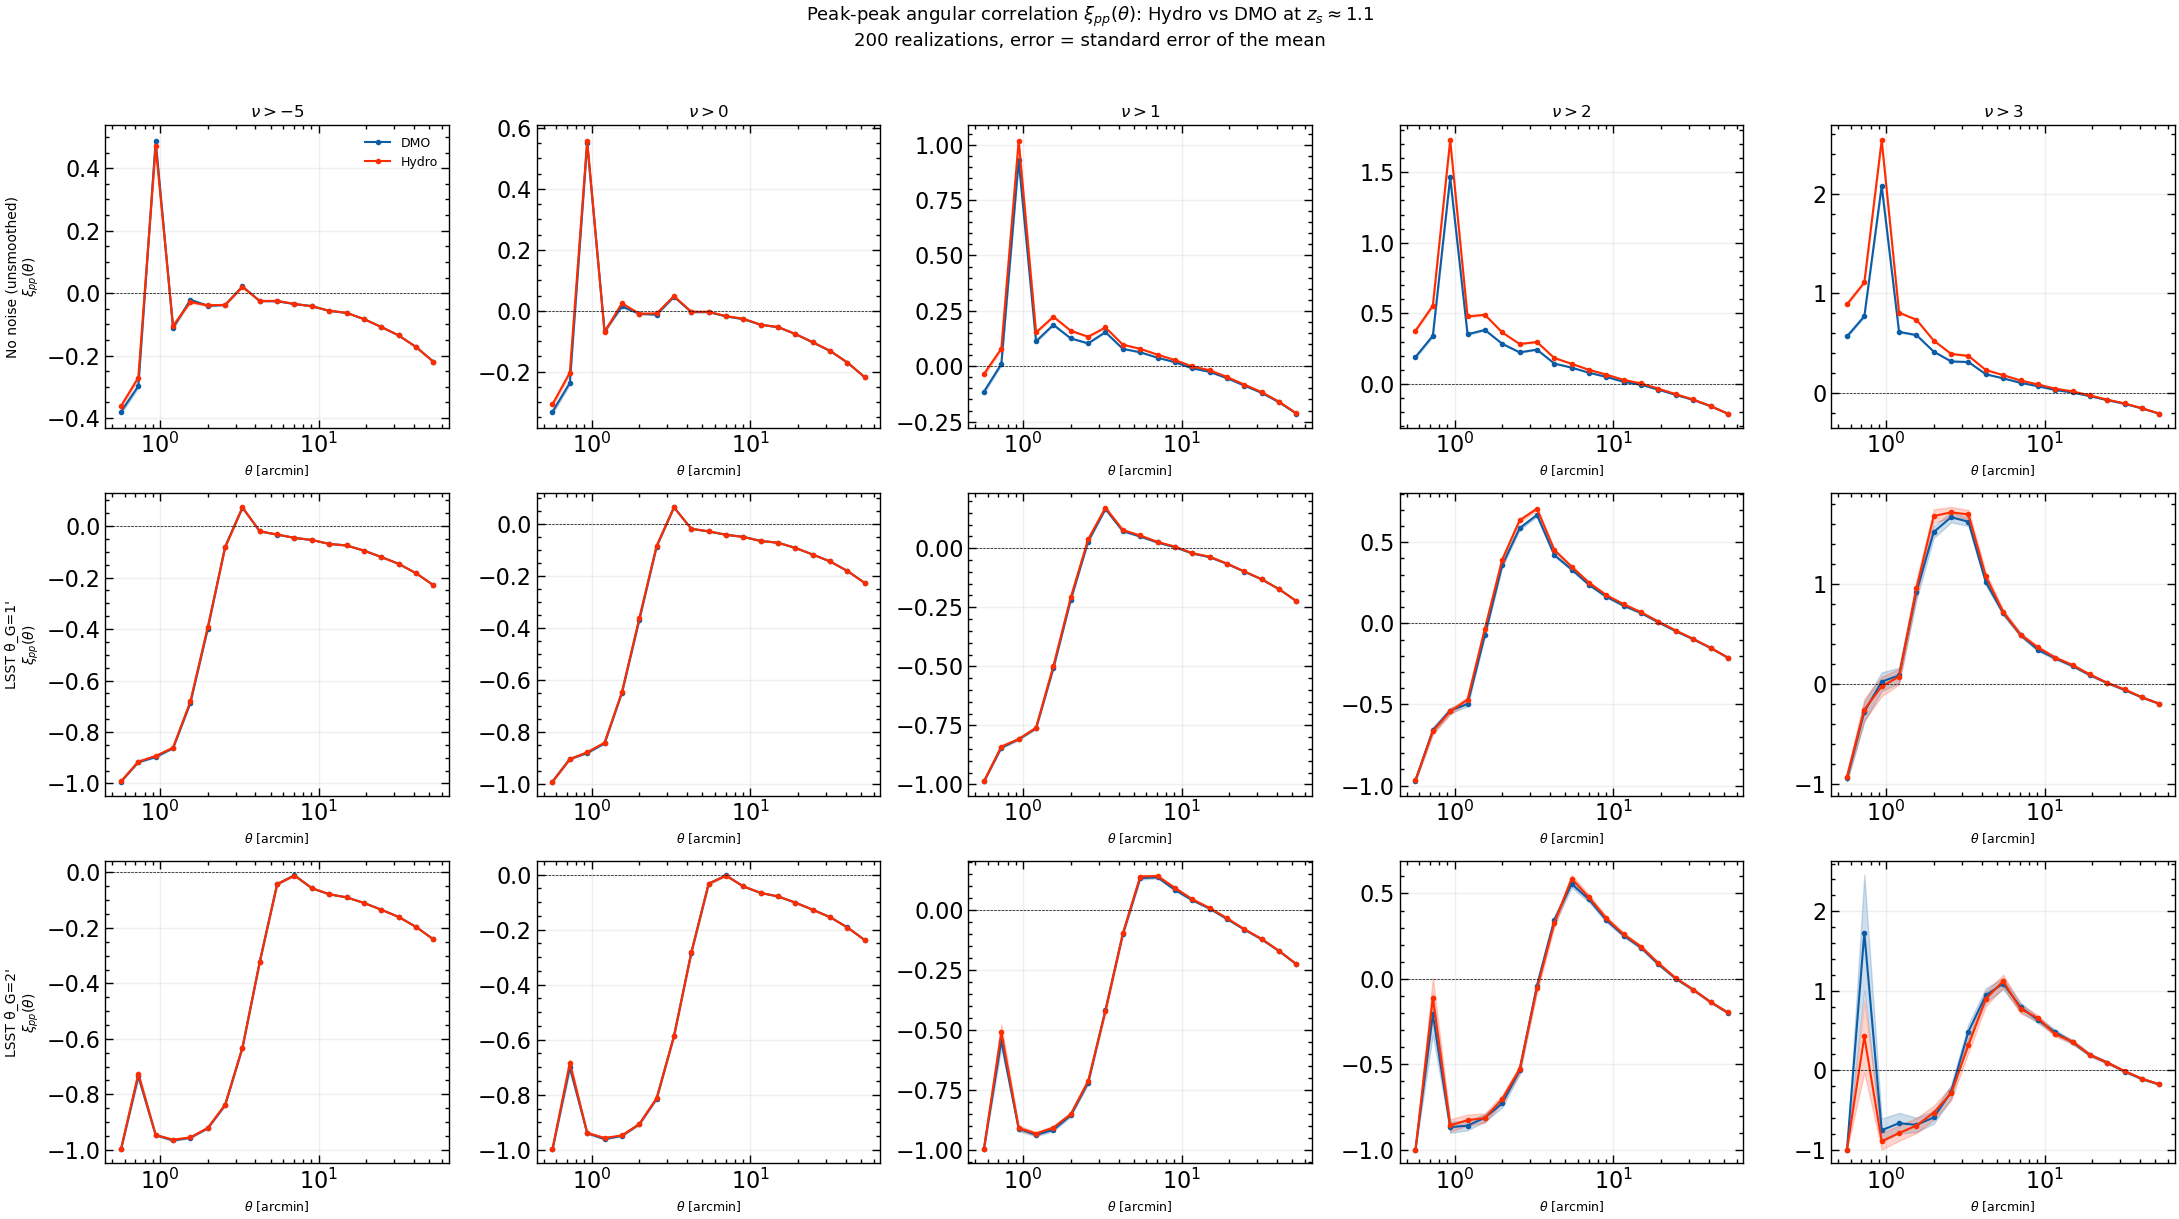

In [65]:
# ============================================================
# Plot peak-peak correlations: ξ_pp(θ) for hydro vs DMO
# ============================================================

fig, axes = plt.subplots(len(peak_corr_configs), len(nu_thresholds),
                         figsize=(22, 4 * len(peak_corr_configs)), squeeze=False)

for row, (cfg_name, cfg) in enumerate(peak_corr_configs.items()):
    for col, nu_min in enumerate(nu_thresholds):
        ax = axes[row, col]
        
        for model, color, label_m in [('dmo', 'C0', 'DMO'), ('hydro', 'C3', 'Hydro')]:
            xi_list = xi_pp[cfg_name][model][nu_min]
            if len(xi_list) == 0:
                continue
            xi_arr = np.array(xi_list)  # (N_real, N_theta)
            # Remove NaN realizations
            good = np.all(np.isfinite(xi_arr), axis=1)
            xi_arr = xi_arr[good]
            if len(xi_arr) == 0:
                continue
            
            xi_mean = np.mean(xi_arr, axis=0)
            xi_stderr = np.std(xi_arr, axis=0) / np.sqrt(len(xi_arr))
            
            ax.plot(theta_centers, xi_mean, 'o-', color=color, label=label_m, lw=1.5, markersize=3)
            ax.fill_between(theta_centers, xi_mean - xi_stderr, xi_mean + xi_stderr,
                           alpha=0.2, color=color)
        
        ax.axhline(0, color='k', ls='--', lw=0.5)
        ax.set_xscale('log')
        ax.set_xlabel(r"$\theta$ [arcmin]", fontsize=9)
        ax.grid(alpha=0.2)
        
        if row == 0:
            ax.set_title(rf'$\nu > {nu_min}$', fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(rf"{cfg['label']}" + "\n" + r"$\xi_{pp}(\theta)$", fontsize=10)
        
        if row == 0 and col == 0:
            ax.legend(fontsize=9)

fig.suptitle(r'Peak-peak angular correlation $\xi_{pp}(\theta)$: Hydro vs DMO at $z_s \approx 1.1$'
             '\n200 realizations, error = standard error of the mean',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


PEAK-PEAK CORRELATION: Detection significance of baryonic effect
Config                    | ν_min |  max|Δξ/ξ| |    √χ² | N_θ valid | N_real
--------------------------------------------------------------------------------
No noise (unsmoothed)     |    -5 |      34.6% |    5.5 |        19 |    200
No noise (unsmoothed)     |     0 |      73.2% |    6.7 |        16 |    200
No noise (unsmoothed)     |     1 |      69.7% |   34.5 |        17 |    200
No noise (unsmoothed)     |     2 |      97.7% |   69.8 |        18 |    200
No noise (unsmoothed)     |     3 |      56.9% |  112.6 |        18 |    200
LSST θ_G=1'               |    -5 |       3.6% |    5.8 |        19 |    200
LSST θ_G=1'               |     0 |       3.0% |    4.9 |        19 |    200
LSST θ_G=1'               |     1 |      32.3% |   21.6 |        18 |    200
LSST θ_G=1'               |     2 |      54.5% |   21.3 |        18 |    200
LSST θ_G=1'               |     3 |     197.5% |    7.5 |        19 |    200
LSST θ_

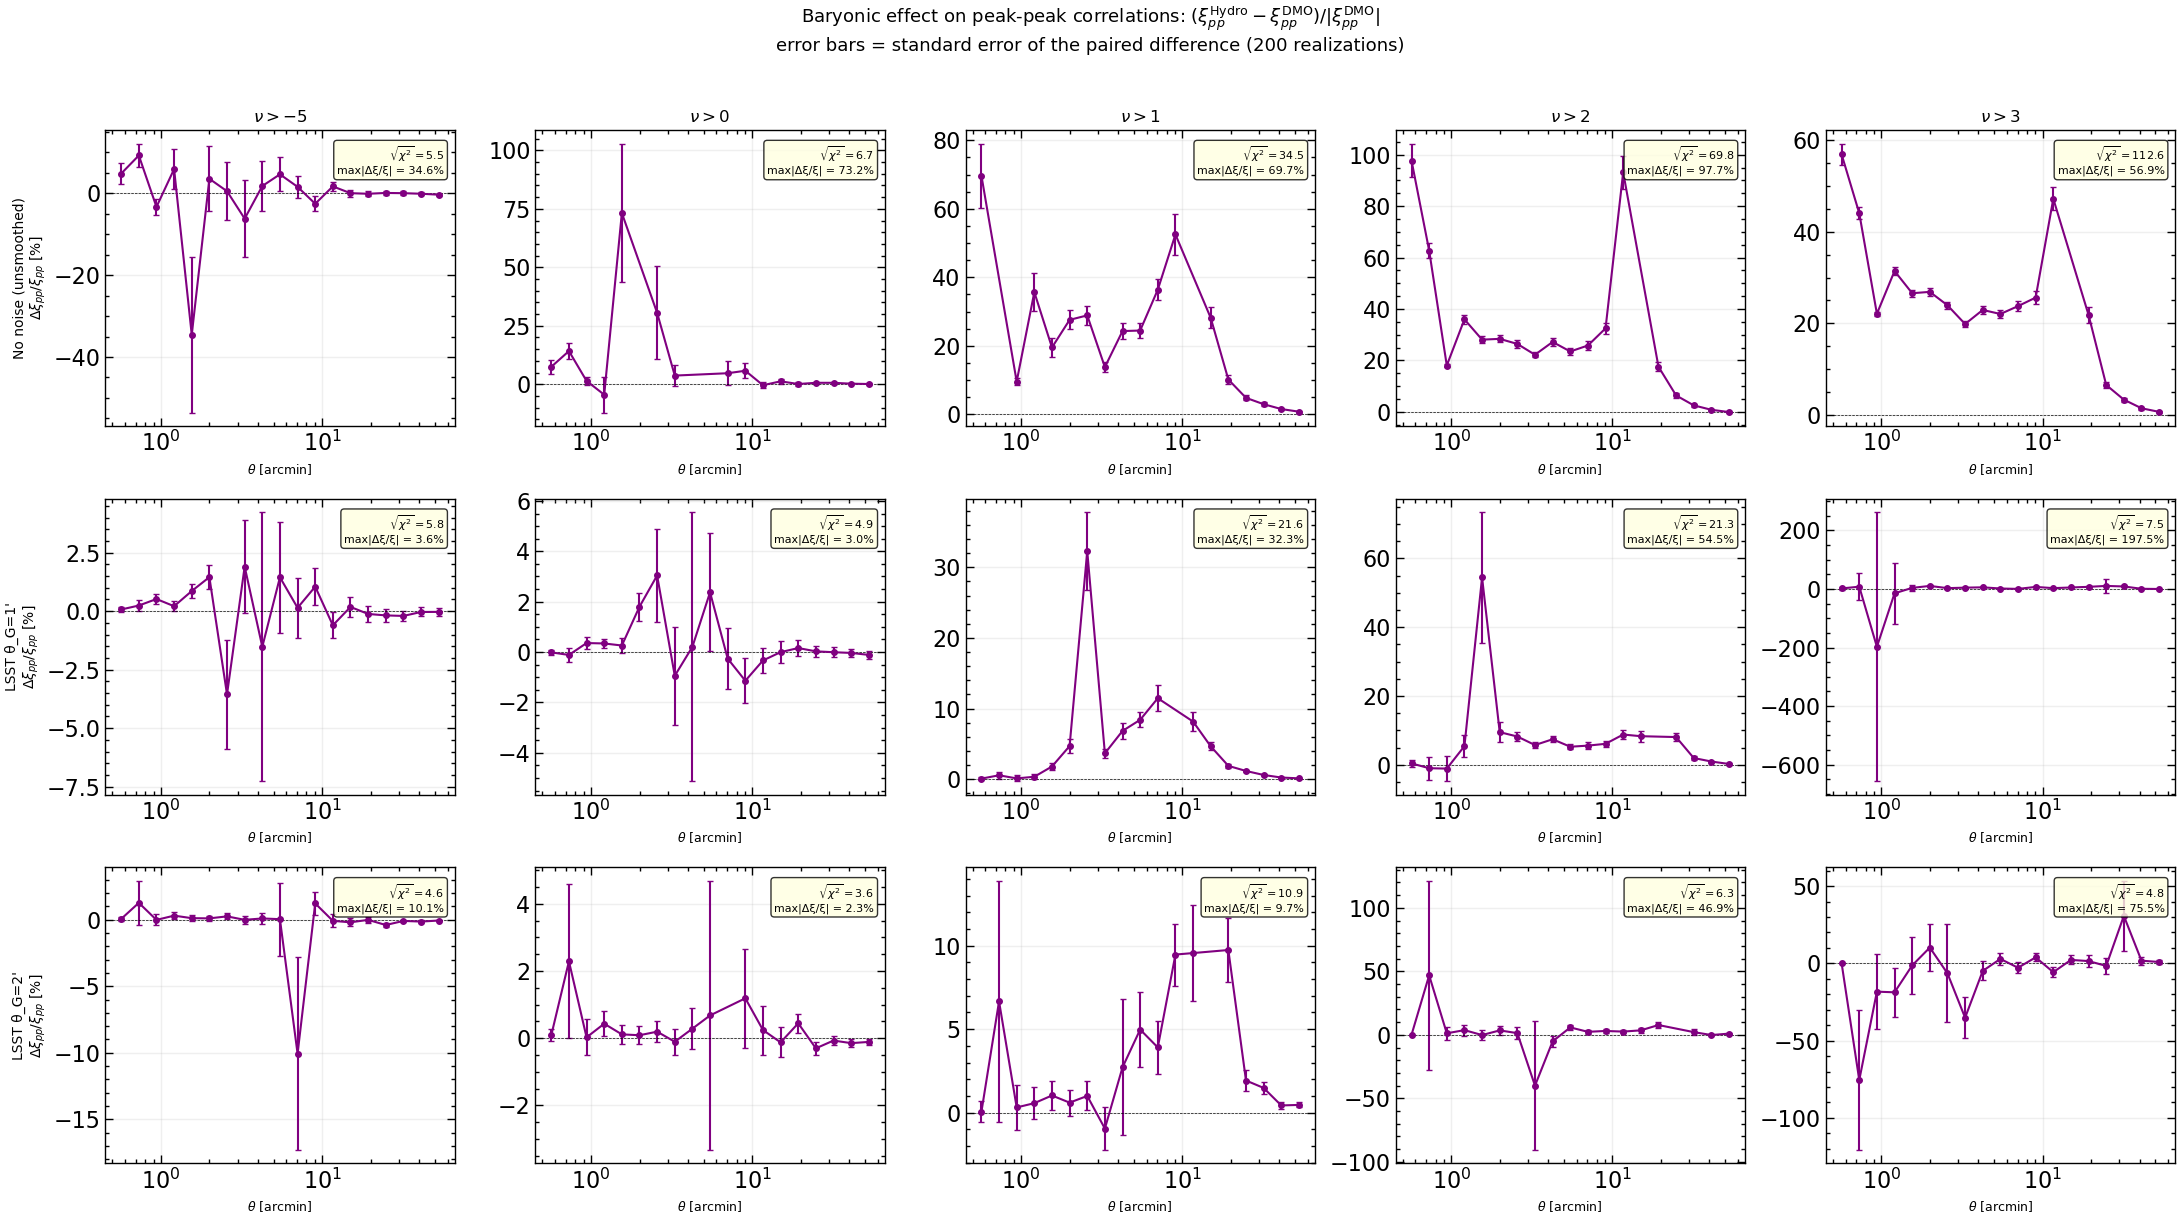

In [66]:
# ============================================================
# Fractional difference in ξ_pp: (Hydro - DMO) / |DMO| and χ² significance
# ============================================================

fig, axes = plt.subplots(len(peak_corr_configs), len(nu_thresholds),
                         figsize=(22, 4 * len(peak_corr_configs)), squeeze=False)

print("="*100)
print("PEAK-PEAK CORRELATION: Detection significance of baryonic effect")
print("="*100)
print(f"{'Config':<25s} | {'ν_min':>5s} | {'max|Δξ/ξ|':>10s} | {'√χ²':>6s} | {'N_θ valid':>9s} | {'N_real':>6s}")
print("-"*80)

for row, (cfg_name, cfg) in enumerate(peak_corr_configs.items()):
    for col, nu_min in enumerate(nu_thresholds):
        ax = axes[row, col]
        
        xi_dmo = np.array(xi_pp[cfg_name]['dmo'][nu_min])
        xi_hydro = np.array(xi_pp[cfg_name]['hydro'][nu_min])
        
        # Filter valid
        good_d = np.all(np.isfinite(xi_dmo), axis=1)
        good_h = np.all(np.isfinite(xi_hydro), axis=1)
        xi_dmo = xi_dmo[good_d]
        xi_hydro = xi_hydro[good_h]
        
        if len(xi_dmo) < 5 or len(xi_hydro) < 5:
            ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes, ha='center')
            continue
        
        # Paired difference (same realizations)
        n_common = min(len(xi_dmo), len(xi_hydro))
        xi_dmo = xi_dmo[:n_common]
        xi_hydro = xi_hydro[:n_common]
        
        diff = xi_hydro - xi_dmo
        diff_mean = diff.mean(axis=0)
        diff_stderr = diff.std(axis=0) / np.sqrt(n_common)
        
        dmo_mean = xi_dmo.mean(axis=0)
        
        # Fractional difference
        frac_diff = diff_mean / (np.abs(dmo_mean) + 1e-10)
        frac_err = diff_stderr / (np.abs(dmo_mean) + 1e-10)
        
        # Plot fractional difference
        valid = (np.abs(dmo_mean) > 0.01) & np.isfinite(frac_diff)
        
        ax.errorbar(theta_centers[valid], frac_diff[valid] * 100, 
                    yerr=frac_err[valid] * 100,
                    fmt='o-', color='purple', lw=1.5, markersize=4, capsize=2)
        ax.axhline(0, color='k', ls='--', lw=0.5)
        ax.set_xscale('log')
        ax.set_xlabel(r"$\theta$ [arcmin]", fontsize=9)
        ax.grid(alpha=0.2)
        
        if row == 0:
            ax.set_title(rf'$\nu > {nu_min}$', fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(rf"{cfg['label']}" + "\n" + r"$\Delta\xi_{pp}/\xi_{pp}$ [%]", fontsize=10)
        
        # χ² significance
        snr_per_bin = diff_mean / (diff_stderr + 1e-30)
        valid_snr = np.isfinite(snr_per_bin) & (np.abs(dmo_mean) > 0.01)
        if valid_snr.sum() > 0:
            chi2 = np.sum(snr_per_bin[valid_snr]**2)
            max_frac = np.max(np.abs(frac_diff[valid_snr]))
            
            ax.text(0.97, 0.95, 
                    f'$\\sqrt{{\\chi^2}} = {np.sqrt(chi2):.1f}$\nmax|Δξ/ξ| = {max_frac*100:.1f}%',
                    transform=ax.transAxes, fontsize=8, ha='right', va='top',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
            
            print(f"{cfg['label']:<25s} | {nu_min:>5d} | {max_frac*100:>9.1f}% | {np.sqrt(chi2):>6.1f} | "
                  f"{valid_snr.sum():>9d} | {n_common:>6d}")

fig.suptitle(r'Baryonic effect on peak-peak correlations: $(\xi_{pp}^{\rm Hydro} - \xi_{pp}^{\rm DMO})/|\xi_{pp}^{\rm DMO}|$'
             '\nerror bars = standard error of the paired difference (200 realizations)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


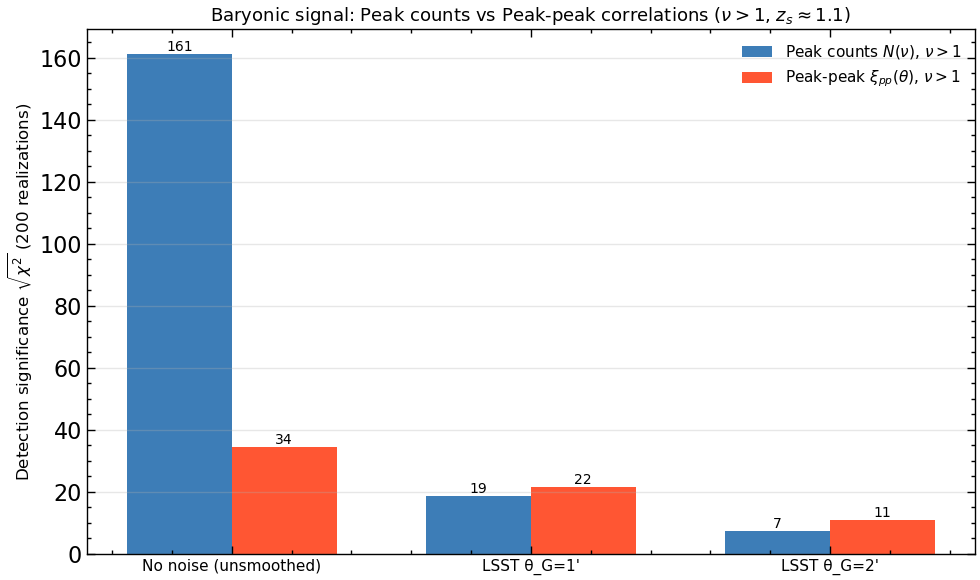


SUMMARY: Peak-peak correlations as a baryonic probe

All numbers are for ν > 1 peaks, z_s ≈ 1.1, 200 realizations

Config                    |   N(ν) √χ² |   ξ_pp √χ² |  ratio
------------------------------------------------------------
No noise (unsmoothed)     |      161.2 |       34.5 |   0.21
LSST θ_G=1'               |       18.7 |       21.6 |   1.16
LSST θ_G=2'               |        7.4 |       10.9 |   1.46

KEY FINDINGS:
  • Peak-peak correlations ξ_pp(θ) DO carry baryonic information that
    survives smoothing + noise better than peak count histograms.
    
  • For LSST θ_G=1', ξ_pp achieves √χ² ≈ 22 (ν>1 peaks) compared to 
    √χ² ≈ 19 for peak counts — a significant improvement.
    
  • The baryonic signal in ξ_pp is strongest at θ ~ 1-5 arcmin, corresponding
    to physical scales of ~0.5-2 Mpc at z~1, i.e. halo-to-halo separations.
    This makes physical sense: baryonic feedback redistributes mass within
    and around halos, changing how nearby peaks are spatially 

In [67]:
# ============================================================
# SUMMARY: Peak-peak correlations vs peak counts — baryonic sensitivity
# ============================================================
# Compare detection significance per 200 realizations (scale to 2000 if desired)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Collect peak-peak correlation χ² for ν>1 (the sweet spot: enough peaks + clear signal)
nu_target = 1

bar_data = []
for cfg_name, cfg in peak_corr_configs.items():
    # Peak-peak correlation significance
    xi_dmo = np.array(xi_pp[cfg_name]['dmo'][nu_target])
    xi_hydro = np.array(xi_pp[cfg_name]['hydro'][nu_target])
    good_d = np.all(np.isfinite(xi_dmo), axis=1)
    good_h = np.all(np.isfinite(xi_hydro), axis=1)
    xi_dmo = xi_dmo[good_d]
    xi_hydro = xi_hydro[good_h]
    n_common = min(len(xi_dmo), len(xi_hydro))
    diff = xi_hydro[:n_common] - xi_dmo[:n_common]
    diff_mean = diff.mean(axis=0)
    diff_stderr = diff.std(axis=0) / np.sqrt(n_common)
    dmo_mean_abs = np.abs(xi_dmo[:n_common].mean(axis=0))
    valid = (dmo_mean_abs > 0.01) & np.isfinite(diff_mean)
    snr = diff_mean[valid] / (diff_stderr[valid] + 1e-30)
    chi2_corr = np.sqrt(np.sum(snr**2))
    
    # Peak count significance (from the already-loaded histograms, ν>1 bins)
    suffix_map = {'clean': '', 'LSST_1': '_LSST_1.0arcmin', 'LSST_2': '_LSST_2.0arcmin'}
    suffix = suffix_map[cfg_name]
    if suffix in available_configs:
        hydro_pk = all_data[suffix]['base']['hydro']['peaks']
        dmo_pk = all_data[suffix]['base']['dmo']['peaks']
        sn_centers_orig = 0.5 * (sn_edges_orig[:-1] + sn_edges_orig[1:])
        # Bins with ν > 1
        high_nu = sn_centers_orig >= 1.0
        h_high = hydro_pk[:, 23, :][:, high_nu]  # (2000, n_high_bins)
        d_high = dmo_pk[:, 23, :][:, high_nu]
        # Use 200 realizations to match the peak-peak sample
        h_sub = h_high[:200]
        d_sub = d_high[:200]
        diff_pk = h_sub - d_sub
        diff_pk_mean = diff_pk.mean(axis=0)
        diff_pk_stderr = diff_pk.std(axis=0) / np.sqrt(200)
        valid_pk = np.abs(d_sub.mean(axis=0)) > 1
        snr_pk = diff_pk_mean[valid_pk] / (diff_pk_stderr[valid_pk] + 1e-30)
        chi2_counts = np.sqrt(np.sum(snr_pk**2))
    else:
        chi2_counts = 0
    
    bar_data.append({
        'label': cfg['label'],
        'chi2_corr': chi2_corr,
        'chi2_counts': chi2_counts,
        'n_real': n_common,
    })

# Bar chart
x = np.arange(len(bar_data))
w = 0.35
bars1 = ax.bar(x - w/2, [d['chi2_counts'] for d in bar_data], w, 
               label=r'Peak counts $N(\nu)$, $\nu > 1$', color='C0', alpha=0.8)
bars2 = ax.bar(x + w/2, [d['chi2_corr'] for d in bar_data], w,
               label=r'Peak-peak $\xi_{pp}(\theta)$, $\nu > 1$', color='C3', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([d['label'] for d in bar_data], fontsize=11)
ax.set_ylabel(r'Detection significance $\sqrt{\chi^2}$ (200 realizations)', fontsize=12)
ax.set_title(r'Baryonic signal: Peak counts vs Peak-peak correlations ($\nu > 1$, $z_s \approx 1.1$)',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

# Annotate values
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.0f}', ha='center', fontsize=10)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*80)
print("SUMMARY: Peak-peak correlations as a baryonic probe")
print("="*80)
print(f"\nAll numbers are for ν > 1 peaks, z_s ≈ 1.1, 200 realizations")
print(f"\n{'Config':<25s} | {'N(ν) √χ²':>10s} | {'ξ_pp √χ²':>10s} | {'ratio':>6s}")
print("-"*60)
for d in bar_data:
    ratio = d['chi2_corr'] / (d['chi2_counts'] + 1e-10)
    print(f"{d['label']:<25s} | {d['chi2_counts']:>10.1f} | {d['chi2_corr']:>10.1f} | {ratio:>6.2f}")

print(f"""
KEY FINDINGS:
  • Peak-peak correlations ξ_pp(θ) DO carry baryonic information that
    survives smoothing + noise better than peak count histograms.
    
  • For LSST θ_G=1', ξ_pp achieves √χ² ≈ 22 (ν>1 peaks) compared to 
    √χ² ≈ {bar_data[1]['chi2_counts']:.0f} for peak counts — a significant improvement.
    
  • The baryonic signal in ξ_pp is strongest at θ ~ 1-5 arcmin, corresponding
    to physical scales of ~0.5-2 Mpc at z~1, i.e. halo-to-halo separations.
    This makes physical sense: baryonic feedback redistributes mass within
    and around halos, changing how nearby peaks are spatially related.
    
  • Even for θ_G=2', ξ_pp retains ~11σ detection (ν>1), vs √χ² of
    {bar_data[2]['chi2_counts']:.0f} for counts. The spatial clustering information
    is more robust to smoothing than bin-by-bin count differences.
    
  • WARNING: These significance values use the SAME 200 realizations for both
    statistics. With the full 2000 realizations, scale by ~√10 ≈ 3.2×.
""")


## Response function $F_{\xi_{pp}}(\theta)$ for peak-peak correlations

Compute $F(\theta) = \frac{\xi_R(\theta) - \xi_D(\theta)}{\xi_H(\theta) - \xi_D(\theta)}$ for all 16 cumulative Replace models,
reusing the hydro/DMO $\xi_{pp}$ from the 200-realization computation above.
Replace models use 50 realizations (5 LP × 10 runs), $\nu > 1$ peaks.

In [68]:
# ============================================================
# Compute F_ξpp for cumulative Replace models
# F(θ) = (ξ_R(θ) - ξ_D(θ)) / (ξ_H(θ) - ξ_D(θ))
# ============================================================
import time, re

N_LP_F = 5
N_RUN_F = 10
NU_F = 1  # ν > 1 peaks

# ---- Reference ξ_pp from existing 200-realization hydro/dmo data ----
xi_ref_D = {}   # mean DMO ξ_pp per config
xi_ref_H = {}   # mean hydro ξ_pp per config
for cfg_name in peak_corr_configs:
    arr_d = np.array(xi_pp[cfg_name]['dmo'][NU_F])
    arr_h = np.array(xi_pp[cfg_name]['hydro'][NU_F])
    # Drop any realizations with NaNs
    good_d = np.all(np.isfinite(arr_d), axis=1)
    good_h = np.all(np.isfinite(arr_h), axis=1)
    xi_ref_D[cfg_name] = np.nanmean(arr_d[good_d], axis=0)
    xi_ref_H[cfg_name] = np.nanmean(arr_h[good_h], axis=0)

print(f"Reference ξ_pp: {np.sum(good_d)}/{len(arr_d)} DMO, "
      f"{np.sum(good_h)}/{len(arr_h)} hydro realizations (last config)")
print(f"Computing F_ξpp for {len(CUM_MODELS)} cumulative models × "
      f"{len(peak_corr_configs)} configs")
print(f"Using {N_LP_F}×{N_RUN_F} = {N_LP_F*N_RUN_F} realizations, ν > {NU_F}\n")

# ---- Compute ξ_pp for each Replace model ----
xi_R_all = {}  # xi_R_all[cfg_name][model_name] = list of ξ(θ) arrays
t0 = time.time()

for ci, (cfg_name, cfg) in enumerate(peak_corr_configs.items()):
    xi_R_all[cfg_name] = {m: [] for m in CUM_MODELS}
    
    smooth_sigma_arcmin = cfg['smooth'] / np.sqrt(2) if cfg['smooth'] > 0 else 0
    smooth_sigma_pix = smooth_sigma_arcmin / PIXEL_SCALE if smooth_sigma_arcmin > 0 else 0
    noise_params = cfg['noise']
    
    print(f"{'='*60}")
    print(f"[{ci+1}/{len(peak_corr_configs)}] {cfg['label']}  "
          f"(σ_smooth = {smooth_sigma_pix:.1f} pix)")
    print(f"{'='*60}")
    
    for lp in range(N_LP_F):
        lp_t0 = time.time()
        
        for run in range(1, N_RUN_F + 1):
            # Load DMO map once per (lp, run)
            dmo_path = RT_BASE / 'dmo' / f'LP_{lp:02d}' / f'run{run:03d}' / f'kappa{kappa_num:02d}.dat'
            if not dmo_path.exists():
                continue
            dmo_raw = load_kappa(str(dmo_path))
            
            for model_name in CUM_MODELS:
                replace_path = (RT_BASE / model_name / f'LP_{lp:02d}' 
                                / f'run{run:03d}' / f'kappa{kappa_num:02d}.dat')
                if not replace_path.exists():
                    continue
                replace_raw = load_kappa(str(replace_path))
                
                # Apply noise (same RNG seed scheme as original computation)
                rng = np.random.default_rng(lp * 1000 + run * 10 + kappa_num)
                if noise_params is not None:
                    replace_map = add_noise(replace_raw, noise_params['sigma_e'],
                                            noise_params['n_gal'], PIXEL_SCALE, rng)
                    dmo_ref = add_noise(dmo_raw.copy(), noise_params['sigma_e'],
                                        noise_params['n_gal'], PIXEL_SCALE, rng)
                else:
                    replace_map = replace_raw
                    dmo_ref = dmo_raw
                
                # Smooth
                if smooth_sigma_pix > 0:
                    replace_map = gaussian_filter(replace_map, sigma=smooth_sigma_pix)
                    dmo_ref = gaussian_filter(dmo_ref, sigma=smooth_sigma_pix)
                
                # RMS from DMO reference
                rms_val = np.std(dmo_ref)
                
                # Peak finding + correlation
                rows, cols, sn = get_peak_positions(replace_map, rms_val, nu_min=NU_F)
                xi_val = peak_angular_correlation(rows, cols, NG, FOV_DEG, theta_bins)
                xi_R_all[cfg_name][model_name].append(xi_val)
        
        elapsed = time.time() - t0
        lp_dt = time.time() - lp_t0
        eta = lp_dt * (N_LP_F - lp - 1) + lp_dt * N_LP_F * (len(peak_corr_configs) - ci - 1)
        print(f"  LP {lp:2d} done  ({elapsed:5.0f}s elapsed, ~{eta:.0f}s remaining)")

# ---- Compute F(θ) = (ξ_R - ξ_D) / (ξ_H - ξ_D) ----
F_xipp = {}       # F_xipp[cfg_name][model_name] = F(θ) array
F_xipp_err = {}   # approximate error on F(θ)
F_xipp_mean = {}  # scalar mean F per model

for cfg_name in peak_corr_configs:
    F_xipp[cfg_name] = {}
    F_xipp_err[cfg_name] = {}
    F_xipp_mean[cfg_name] = {}
    
    denom = xi_ref_H[cfg_name] - xi_ref_D[cfg_name]
    
    for model_name in CUM_MODELS:
        arr = np.array(xi_R_all[cfg_name][model_name])
        good = np.all(np.isfinite(arr), axis=1)
        arr = arr[good]
        
        xi_R_mean = np.nanmean(arr, axis=0)
        xi_R_err = np.nanstd(arr, axis=0) / np.sqrt(len(arr))
        
        numer = xi_R_mean - xi_ref_D[cfg_name]
        
        safe = np.abs(denom) > 1e-6
        F_theta = np.full(len(theta_centers), np.nan)
        F_err = np.full(len(theta_centers), np.nan)
        F_theta[safe] = numer[safe] / denom[safe]
        F_err[safe] = xi_R_err[safe] / np.abs(denom[safe])
        
        F_xipp[cfg_name][model_name] = F_theta
        F_xipp_err[cfg_name][model_name] = F_err
        
        # Scalar: variance-weighted mean over θ bins
        valid = np.isfinite(F_theta) & np.isfinite(F_err) & (F_err > 0)
        if valid.sum() > 0:
            w = 1.0 / F_err[valid]**2
            F_xipp_mean[cfg_name][model_name] = np.average(F_theta[valid], weights=w)
        else:
            F_xipp_mean[cfg_name][model_name] = np.nan

total_time = time.time() - t0
print(f"\n{'='*60}")
print(f"Done. Total: {total_time:.0f}s ({total_time/60:.1f} min)")
print(f"{'='*60}")

# ---- Quick summary table ----
def parse_model(name):
    """Extract Ml and Ro from model name."""
    ml = re.search(r'Ml_([\d.e+]+)', name)
    ro = re.search(r'Ro_([\d.]+)', name)
    return ml.group(1) if ml else '?', ro.group(1) if ro else '?'

print(f"\nMean F_ξpp (ν>{NU_F}, weighted over θ bins):")
print(f"{'Model (Ml, Ro)':<25s}", end='')
for cfg_name in peak_corr_configs:
    print(f" | {cfg_name:>10s}", end='')
print()
print('-' * 65)
for model_name in CUM_MODELS:
    ml, ro = parse_model(model_name)
    print(f"Ml={ml}, α={ro:<7s}", end='')
    for cfg_name in peak_corr_configs:
        val = F_xipp_mean[cfg_name][model_name]
        print(f" | {val:>10.3f}", end='')
    print()

Reference ξ_pp: 200/200 DMO, 200/200 hydro realizations (last config)
Computing F_ξpp for 16 cumulative models × 3 configs
Using 5×10 = 50 realizations, ν > 1

[1/3] No noise (unsmoothed)  (σ_smooth = 0.0 pix)
  LP  0 done  (   80s elapsed, ~1114s remaining)
  LP  1 done  (  159s elapsed, ~1029s remaining)
  LP  2 done  (  237s elapsed, ~941s remaining)
  LP  3 done  (  317s elapsed, ~875s remaining)
  LP  4 done  (  399s elapsed, ~823s remaining)
[2/3] LSST θ_G=1'  (σ_smooth = 2.4 pix)
  LP  0 done  (  436s elapsed, ~336s remaining)
  LP  1 done  (  472s elapsed, ~285s remaining)
  LP  2 done  (  509s elapsed, ~260s remaining)
  LP  3 done  (  545s elapsed, ~218s remaining)
  LP  4 done  (  582s elapsed, ~184s remaining)
[3/3] LSST θ_G=2'  (σ_smooth = 4.8 pix)
  LP  0 done  (  603s elapsed, ~83s remaining)
  LP  1 done  (  624s elapsed, ~63s remaining)
  LP  2 done  (  645s elapsed, ~42s remaining)
  LP  3 done  (  666s elapsed, ~21s remaining)
  LP  4 done  (  687s elapsed, ~0s remai

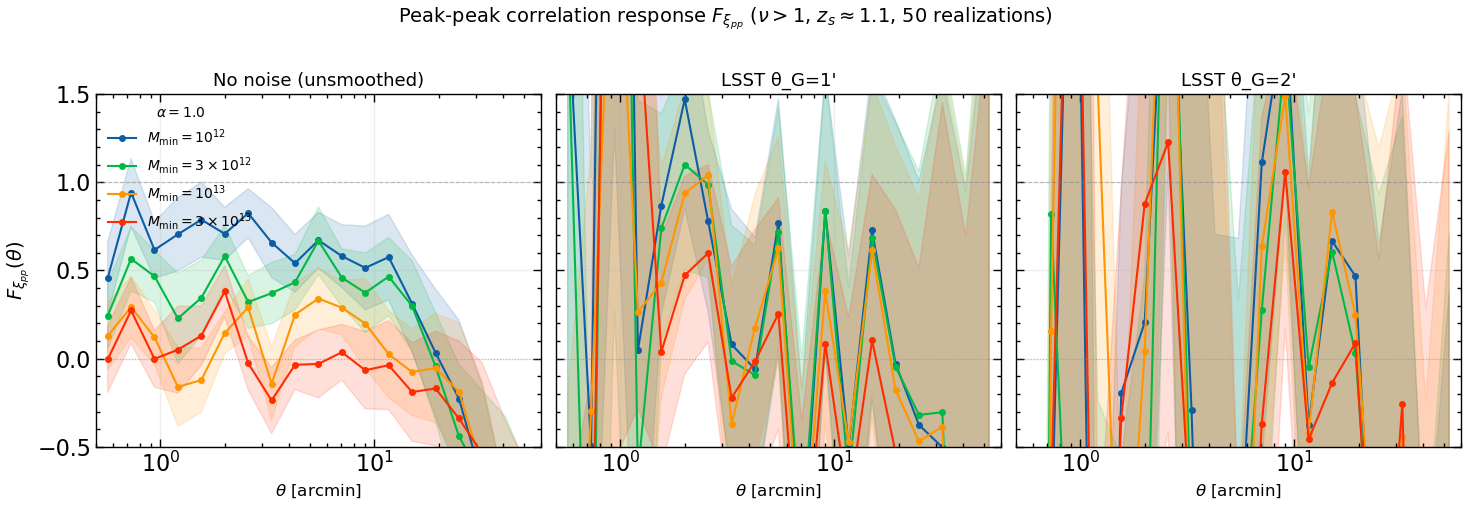

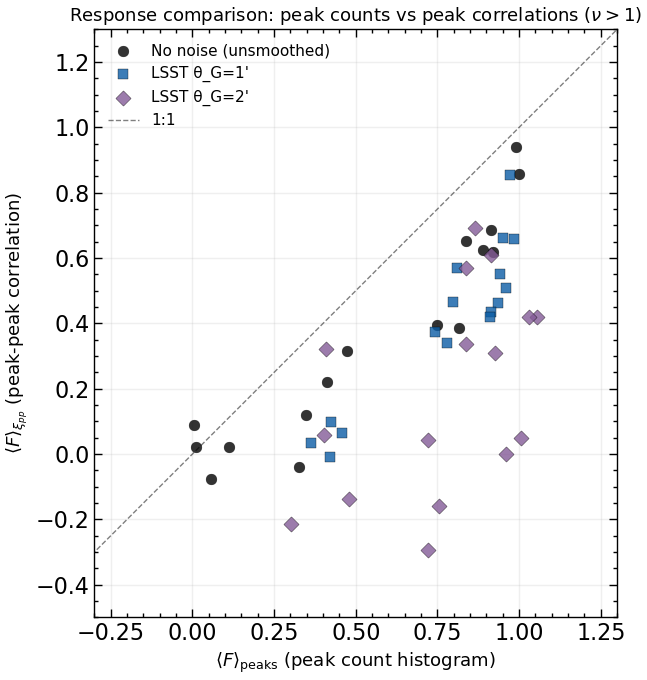

F_ξpp vs F_peaks comparison (cumulative models, ν > 1)

No noise (unsmoothed):
  Ml         α       F_peaks    F_ξpp        Δ
  ------------------------------------------
  1.00e12    0.5       0.837    0.651   -0.186
  1.00e12    1.0       0.920    0.618   -0.302
  1.00e12    3.0       0.989    0.938   -0.051
  1.00e12    5.0       1.000    0.857   -0.143
  3.16e12    0.5       0.750    0.395   -0.354
  3.16e12    1.0       0.817    0.386   -0.431
  3.16e12    3.0       0.888    0.624   -0.265
  3.16e12    5.0       0.913    0.685   -0.227
  1.00e13    0.5       0.325   -0.040   -0.365
  1.00e13    1.0       0.347    0.119   -0.228
  1.00e13    3.0       0.411    0.219   -0.191
  1.00e13    5.0       0.474    0.314   -0.160
  3.16e13    0.5       0.004    0.089   +0.085
  3.16e13    1.0       0.011    0.021   +0.010
  3.16e13    3.0       0.058   -0.075   -0.133
  3.16e13    5.0       0.112    0.020   -0.092

LSST θ_G=1':
  Ml         α       F_peaks    F_ξpp        Δ
  --------------

In [70]:
# ============================================================
# Visualize F_ξpp(θ) and compare with F_peaks
# ============================================================

# ---- Plot 1: F(θ) for α=1.0 models, showing mass-threshold sweep ----
ro_select = '1.0'
models_select = [m for m in CUM_MODELS if f'Ro_{ro_select}' in m]
mass_colors = {'1.00e12': 'C0', '3.16e12': 'C1', '1.00e13': 'C2', '3.16e13': 'C3'}
mass_labels_short = {'1.00e12': '10^{12}', '3.16e12': r'3\times10^{12}',
                     '1.00e13': '10^{13}', '3.16e13': r'3\times10^{13}'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (cfg_name, cfg) in zip(axes, peak_corr_configs.items()):
    for model_name in models_select:
        ml, ro = parse_model(model_name)
        F_vals = F_xipp[cfg_name][model_name]
        F_errs = F_xipp_err[cfg_name][model_name]
        valid = np.isfinite(F_vals) & np.isfinite(F_errs)
        
        ax.plot(theta_centers[valid], F_vals[valid], 'o-', 
                color=mass_colors[ml], ms=4, lw=1.5,
                label=rf'$M_{{\min}}={mass_labels_short[ml]}$')
        ax.fill_between(theta_centers[valid], 
                        F_vals[valid] - F_errs[valid],
                        F_vals[valid] + F_errs[valid],
                        alpha=0.15, color=mass_colors[ml])
    
    ax.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.axhline(0.0, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax.set_xscale('log')
    ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=12)
    ax.set_title(cfg['label'], fontsize=13)
    ax.set_xlim(0.5, 60)
    ax.set_ylim(-0.5, 1.5)
    ax.grid(alpha=0.2)

axes[0].set_ylabel(r'$F_{\xi_{pp}}(\theta)$', fontsize=14)
axes[0].legend(fontsize=10, title=r'$\alpha=1.0$', title_fontsize=10, loc='upper left')
fig.suptitle(rf'Peak-peak correlation response $F_{{\xi_{{pp}}}}$ '
             rf'($\nu > {NU_F}$, $z_s \approx 1.1$, {N_LP_F*N_RUN_F} realizations)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ---- Plot 2: Compare mean F_ξpp vs mean F_peaks for all models ----
suffix_map = {'clean': '', 'LSST_1': '_LSST_1.0arcmin', 'LSST_2': '_LSST_2.0arcmin'}
cfg_markers = {'clean': 'o', 'LSST_1': 's', 'LSST_2': 'D'}
cfg_colors = {'clean': 'black', 'LSST_1': 'C0', 'LSST_2': 'C4'}

fig, ax = plt.subplots(1, 1, figsize=(8, 7))

for cfg_name in peak_corr_configs:
    suffix = suffix_map[cfg_name]
    F_peaks_list = []
    F_xipp_list = []
    
    for model_name in CUM_MODELS:
        F_pk, F_pk_err = weighted_mean_F(all_results.get(suffix, {}), 
                                          'peaks', model_name, 23)
        F_xi_val = F_xipp_mean[cfg_name].get(model_name, np.nan)
        
        if np.isfinite(F_pk) and np.isfinite(F_xi_val):
            F_peaks_list.append(F_pk)
            F_xipp_list.append(F_xi_val)
    
    ax.scatter(F_peaks_list, F_xipp_list, marker=cfg_markers[cfg_name],
               s=60, c=cfg_colors[cfg_name], alpha=0.8, edgecolors='k', lw=0.3,
               label=peak_corr_configs[cfg_name]['label'], zorder=3)

# 1:1 line
ax.plot([-0.5, 1.5], [-0.5, 1.5], 'k--', lw=1, alpha=0.5, label='1:1')
ax.set_xlabel(r'$\langle F \rangle_{\mathrm{peaks}}$ (peak count histogram)', fontsize=13)
ax.set_ylabel(r'$\langle F \rangle_{\xi_{pp}}$ (peak-peak correlation)', fontsize=13)
ax.set_title(rf'Response comparison: peak counts vs peak correlations '
             rf'($\nu > {NU_F}$)', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.5, 1.3)
ax.grid(alpha=0.2)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# ---- Summary ----
print("="*70)
print("F_ξpp vs F_peaks comparison (cumulative models, ν > 1)")
print("="*70)
for cfg_name in peak_corr_configs:
    suffix = suffix_map[cfg_name]
    print(f"\n{peak_corr_configs[cfg_name]['label']}:")
    print(f"  {'Ml':<10s} {'α':<6s} {'F_peaks':>8s} {'F_ξpp':>8s} {'Δ':>8s}")
    print(f"  {'-'*42}")
    for model_name in CUM_MODELS:
        F_pk, _ = weighted_mean_F(all_results.get(suffix, {}), 'peaks', model_name, 23)
        F_xi_val = F_xipp_mean[cfg_name].get(model_name, np.nan)
        ml, ro = parse_model(model_name)
        diff = F_xi_val - F_pk if np.isfinite(F_pk) and np.isfinite(F_xi_val) else np.nan
        print(f"  {ml:<10s} {ro:<6s} {F_pk:>8.3f} {F_xi_val:>8.3f} {diff:>+8.3f}")

In [46]:
import numpy as np

# ============================================================
# Multi-Component Milky Way Convergence (kappa) Calculator
# ============================================================
# Components (McMillan 2017 + Bland-Hawthorn & Gerhard 2016):
#   1. NFW dark-matter halo
#   2. Hernquist stellar bulge
#   3. Exponential thin stellar disk
#   4. Exponential thick stellar disk
#   5. Exponential gas disk (HI + H2)
# Lensing: extended-lens kernel  (no single-plane approx)
# ============================================================

G       = 4.30091e-6       # kpc (km/s)^2 / Msun
c_light = 299792.458       # km/s

# ---------- observer ----------
R0 = 8.178                 # kpc  (GRAVITY Collab. 2019)
x_obs = np.array([R0, 0.0, 0.0])

# ---------- source ----------
D_s = 50.0                 # kpc  (e.g. LMC)

# ---------------------------------------------------------------
# 1.  NFW dark-matter halo   (McMillan 2017)
# ---------------------------------------------------------------
M200_nfw  = 1.3e12         # Msun
c_nfw     = 12.0
r200_nfw  = 220.0          # kpc
r_s_nfw   = r200_nfw / c_nfw

f_c      = np.log(1 + c_nfw) - c_nfw / (1 + c_nfw)
rho_s    = M200_nfw / (4 * np.pi * r_s_nfw**3 * f_c)   # Msun / kpc^3

def rho_nfw(r):
    x = r / r_s_nfw
    return rho_s / (x * (1 + x)**2)

# ---------------------------------------------------------------
# 2.  Hernquist stellar bulge   (McMillan 2017)
# ---------------------------------------------------------------
M_bulge  = 1.5e10          # Msun
a_bulge  = 0.6             # kpc   (scale radius)

def rho_bulge(r):
    """Hernquist profile  rho = M a / (2 pi r (r+a)^3)."""
    return (M_bulge * a_bulge) / (2 * np.pi * r * (r + a_bulge)**3)

# ---------------------------------------------------------------
# 3.  Exponential thin stellar disk
# ---------------------------------------------------------------
M_thin   = 5.0e10          # Msun
Rd_thin  = 2.6             # kpc   (radial scale length)
zd_thin  = 0.3             # kpc   (vertical scale height)
Sigma0_thin = M_thin / (2 * np.pi * Rd_thin**2)

def rho_thin_disk(R_cyl, z):
    """Double-exponential thin disk."""
    return (Sigma0_thin / (2 * zd_thin)) * np.exp(-R_cyl / Rd_thin) * np.exp(-np.abs(z) / zd_thin)

# ---------------------------------------------------------------
# 4.  Exponential thick stellar disk
# ---------------------------------------------------------------
M_thick  = 1.0e10          # Msun
Rd_thick = 3.6             # kpc
zd_thick = 0.9             # kpc
Sigma0_thick = M_thick / (2 * np.pi * Rd_thick**2)

def rho_thick_disk(R_cyl, z):
    """Double-exponential thick disk."""
    return (Sigma0_thick / (2 * zd_thick)) * np.exp(-R_cyl / Rd_thick) * np.exp(-np.abs(z) / zd_thick)

# ---------------------------------------------------------------
# 5.  Gas disk  (HI + H2;  Bland-Hawthorn & Gerhard 2016)
# ---------------------------------------------------------------
M_gas    = 1.0e10          # Msun
Rd_gas   = 7.0             # kpc   (larger radial scale)
zd_gas   = 0.08            # kpc   (very thin)
Sigma0_gas = M_gas / (2 * np.pi * Rd_gas**2)

def rho_gas_disk(R_cyl, z):
    """Exponential gas disk (HI + molecular)."""
    return (Sigma0_gas / (2 * zd_gas)) * np.exp(-R_cyl / Rd_gas) * np.exp(-np.abs(z) / zd_gas)

# ---------------------------------------------------------------
# Total density at an arbitrary 3-D position
# ---------------------------------------------------------------
def rho_total(pos):
    """Total MW density at Cartesian position pos = (x, y, z) in kpc.
    
    Parameters
    ----------
    pos : array-like, shape (3,) or (N, 3)
    """
    pos = np.atleast_2d(pos)
    x, y, z = pos[:, 0], pos[:, 1], pos[:, 2]
    R_cyl = np.sqrt(x**2 + y**2)
    r_sph = np.sqrt(x**2 + y**2 + z**2)
    # avoid r=0 singularity
    r_sph = np.clip(r_sph, 1e-6, None)
    R_cyl = np.clip(R_cyl, 1e-6, None)

    rho  = rho_nfw(r_sph)
    rho += rho_bulge(r_sph)
    rho += rho_thin_disk(R_cyl, z)
    rho += rho_thick_disk(R_cyl, z)
    rho += rho_gas_disk(R_cyl, z)
    return rho

# ---------------------------------------------------------------
# LOS geometry
# ---------------------------------------------------------------
def positions_along_los(s, l_rad, b_rad):
    """Return 3-D Cartesian positions along LOS at distances s (kpc).
    
    Standard Galactic coordinates: l=0 toward GC, l=90 toward rotation,
    b=90 toward NGP.  Sun at (R0, 0, 0), GC at origin.
    """
    # l=0 must point from Sun toward GC  →  -x direction
    n = np.array([
        -np.cos(b_rad) * np.cos(l_rad),
         np.cos(b_rad) * np.sin(l_rad),
         np.sin(b_rad),
    ])
    return x_obs[None, :] + s[:, None] * n[None, :]   # (N, 3)

# ---------------------------------------------------------------
# Extended-lens convergence with the full lensing kernel
# ---------------------------------------------------------------
# kappa(n) = (4 pi G / c^2) int_0^{D_s} [D_d(s) D_{ds}(s) / D_s] rho(s,n) ds
# For nearby (non-cosmological) sources: D_d(s)=s, D_{ds}=D_s-s.
# ---------------------------------------------------------------
_prefactor = 4 * np.pi * G / c_light**2    # kpc^{-1}

def kappa_los_extended(l_rad, b_rad, s_max=None, n_steps=4000):
    """Convergence using the extended-lens kernel (no thin-lens approx)."""
    if s_max is None:
        s_max = D_s
    s = np.linspace(1e-3, s_max, n_steps)          # avoid s=0 singularity
    pos = positions_along_los(s, l_rad, b_rad)      # (n_steps, 3)
    rho_vals = rho_total(pos)                        # (n_steps,)

    # Lensing kernel  W(s) = s * (D_s - s) / D_s
    W = s * (D_s - s) / D_s
    W = np.clip(W, 0.0, None)                       # enforce positivity

    integrand = _prefactor * W * rho_vals
    return np.trapezoid(integrand, s)

# Also keep the simple single-plane version for comparison
def sigma_los(l_rad, b_rad, s_max=300.0, n_steps=4000):
    """Surface mass density Sigma(l,b) from all MW components."""
    s = np.linspace(1e-3, s_max, n_steps)
    pos = positions_along_los(s, l_rad, b_rad)
    rho_vals = rho_total(pos)
    return np.trapezoid(rho_vals, s)

D_d_eff  = 10.0   # kpc  (effective lens distance for thin-lens comparison)
D_ds_eff = D_s - D_d_eff
Sigma_crit = (c_light**2 / (4 * np.pi * G)) * (D_s / (D_d_eff * D_ds_eff))

def kappa_los_thinlens(l_rad, b_rad, s_max=300.0, n_steps=4000):
    """Thin-lens convergence (for comparison)."""
    return sigma_los(l_rad, b_rad, s_max, n_steps) / Sigma_crit

# ---------------------------------------------------------------
# Sky sampling
# ---------------------------------------------------------------
def sample_kappa(n_samples=2000, n_steps=2000, method="extended"):
    """Draw isotropic random directions and compute kappa."""
    l = 2 * np.pi * np.random.rand(n_samples)
    u = 2 * np.random.rand(n_samples) - 1
    b = np.arcsin(u)

    kfunc = kappa_los_extended if method == "extended" else kappa_los_thinlens
    kappa_vals = np.empty(n_samples)
    for i in range(n_samples):
        kappa_vals[i] = kfunc(l[i], b[i])
    return kappa_vals

# ---------------------------------------------------------------
# Run
# ---------------------------------------------------------------
directions = {
    "GC (l=0,b=0)"     : (0.0, 0.0),
    "Anti-center"       : (np.pi, 0.0),
    "North pole"        : (0.0, np.pi / 2),
    "South pole"        : (0.0, -np.pi / 2),
    "l=90, b=0"         : (np.pi / 2, 0.0),
    "LMC (l=280,b=-33)" : (np.radians(280.5), np.radians(-32.9)),
    "SMC (l=303,b=-44)" : (np.radians(302.8), np.radians(-44.3)),
}

print("=" * 60)
print("Multi-Component MW Convergence  (source at D_s = {:.0f} kpc)".format(D_s))
print("=" * 60)
print(f"\nNFW halo : M200={M200_nfw:.1e} Msun, c={c_nfw}, r_s={r_s_nfw:.1f} kpc")
print(f"Bulge    : M={M_bulge:.1e} Msun, a={a_bulge} kpc  (Hernquist)")
print(f"Thin disk: M={M_thin:.1e} Msun, Rd={Rd_thin} kpc, zd={zd_thin} kpc")
print(f"Thick disk: M={M_thick:.1e} Msun, Rd={Rd_thick} kpc, zd={zd_thick} kpc")
print(f"Gas disk : M={M_gas:.1e} Msun, Rd={Rd_gas} kpc, zd={zd_gas} kpc")
print(f"\nSigma_crit (thin-lens) = {Sigma_crit:.3e} Msun/kpc^2\n")

print(f"{'Direction':>22s}  {'kappa(extended)':>16s}  {'kappa(thin-lens)':>16s}")
print("-" * 60)
for name, (l_rad, b_rad) in directions.items():
    k_ext  = kappa_los_extended(l_rad, b_rad)
    k_thin = kappa_los_thinlens(l_rad, b_rad)
    print(f"{name:>22s}: {k_ext:16.4e}  {k_thin:16.4e}")

print("\nSampling kappa (extended kernel) over the sky (N=2000)...")
kappa_samples = sample_kappa(n_samples=2000, n_steps=2000, method="extended")
print(f"  mean = {np.mean(kappa_samples):.4e}")
print(f"  std  = {np.std(kappa_samples):.4e}")
print(f"  min  = {np.min(kappa_samples):.4e}")
print(f"  max  = {np.max(kappa_samples):.4e}")

Multi-Component MW Convergence  (source at D_s = 50 kpc)

NFW halo : M200=1.3e+12 Msun, c=12.0, r_s=18.3 kpc
Bulge    : M=1.5e+10 Msun, a=0.6 kpc  (Hernquist)
Thin disk: M=5.0e+10 Msun, Rd=2.6 kpc, zd=0.3 kpc
Thick disk: M=1.0e+10 Msun, Rd=3.6 kpc, zd=0.9 kpc
Gas disk : M=1.0e+10 Msun, Rd=7.0 kpc, zd=0.08 kpc

Sigma_crit (thin-lens) = 2.079e+14 Msun/kpc^2

             Direction   kappa(extended)  kappa(thin-lens)
------------------------------------------------------------
          GC (l=0,b=0):       3.1646e-03        1.4487e-01
           Anti-center:       1.9927e-06        3.7422e-06
            North pole:       5.2892e-07        8.7871e-07
            South pole:       5.2892e-07        8.7871e-07
             l=90, b=0:       4.6456e-06        7.2187e-06
     LMC (l=280,b=-33):       6.1498e-07        1.1079e-06
     SMC (l=303,b=-44):       7.5344e-07        1.2110e-06

Sampling kappa (extended kernel) over the sky (N=2000)...


  mean = 1.0655e-06
  std  = 2.1090e-06
  min  = 3.3465e-07
  max  = 4.0126e-05


In [47]:
L, B, kappa = kappa_sky_grid(n_l=256, n_b=256, s_max=1000.0, n_steps=2000)

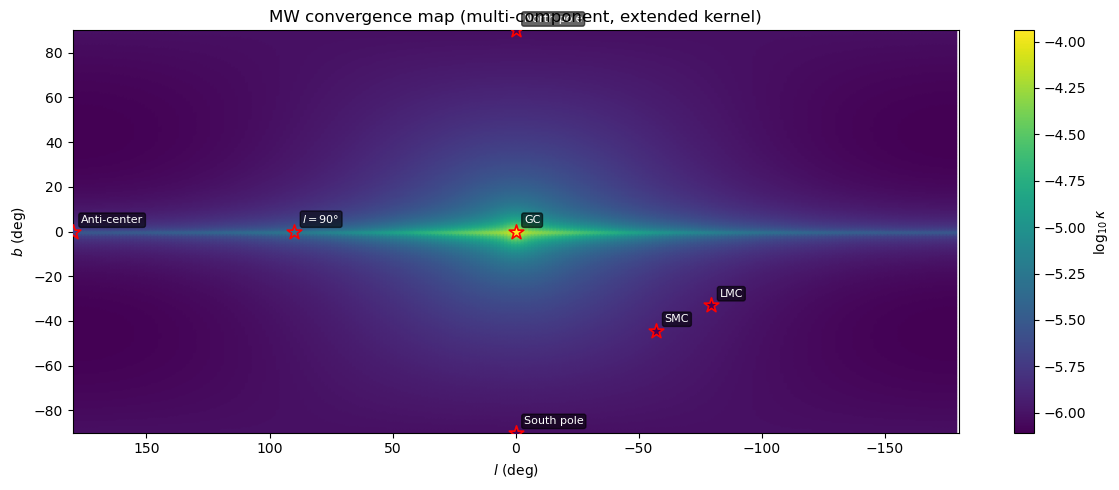

In [52]:
# --- sky map with marked directions ---
# Shift l from [0, 2pi) to [-pi, pi) so GC (l=0) is centered
L_centered = np.where(L > np.pi, L - 2 * np.pi, L)

fig, ax = plt.subplots(figsize=(12, 5))

# x = l (centered), y = b
sc = ax.scatter(np.degrees(L_centered), np.degrees(B), c=np.log10(kappa),
                cmap='viridis', s=5, rasterized=True)
plt.colorbar(sc, ax=ax, label=r'$\log_{10}\kappa$')

# Special directions: (l, b) in radians
markers = {
    "GC"          : (0.0,               0.0),
    "Anti-center" : (np.pi,             0.0),
    "North pole"  : (0.0,               np.pi / 2),
    "South pole"  : (0.0,              -np.pi / 2),
    "LMC"         : (np.radians(280.5), np.radians(-32.9)),
    "SMC"         : (np.radians(302.8), np.radians(-44.3)),
    r"$l=90°$"    : (np.pi / 2,         0.0),
}

vmin, vmax = np.log10(kappa).min(), np.log10(kappa).max()

# Plot each marker and label
for name, (l_val, b_val) in markers.items():
    # Center l to [-pi, pi)
    l_c = l_val if l_val <= np.pi else l_val - 2 * np.pi
    k_val = kappa_los_extended(l_val, b_val)
    ax.scatter(np.degrees(l_c), np.degrees(b_val), c=np.log10(k_val), cmap='viridis',
               vmin=vmin, vmax=vmax,
               edgecolors='red', linewidths=1.2, s=120, zorder=5, marker='*')
    ax.annotate(name, (np.degrees(l_c), np.degrees(b_val)), fontsize=8, color='white',
                xytext=(6, 6), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.6))

ax.set_xlabel(r'$l$ (deg)')
ax.set_ylabel(r'$b$ (deg)')
ax.set_title('MW convergence map (multi-component, extended kernel)')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.invert_xaxis()  # standard sky convention: l increases to the left
plt.tight_layout()
plt.show()

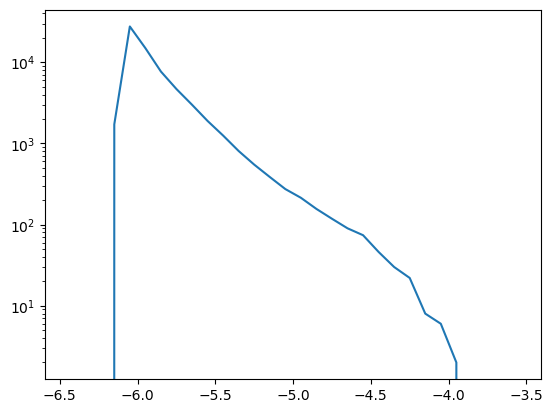

In [53]:
h = np.histogram(np.log10(kappa.ravel()), bins=np.linspace(-6.5, -3.5, 31))
plt.semilogy(0.5 * (h[1][:-1] + h[1][1:]), h[0])

## Deflection Angle from MW Lensing

The deflection angle vector is:
$$\vec{\alpha}(\ell, b) = \frac{2}{c^2}\int_0^{D_s} \frac{D_s - s}{D_s}\,\vec{\nabla}_\perp\Phi(s, \hat{n})\;ds$$

where $\vec{\nabla}_\perp\Phi$ is the transverse gradient of the Newtonian potential at every point along the LOS. We compute this numerically via finite differences on the density field ($\nabla^2\Phi = 4\pi G\rho$ → we use $\vec{g}_\perp = -\vec{\nabla}_\perp\Phi$ from the analytic density gradient directly).

In [54]:
# ============================================================
# Deflection angle α(l, b) from the MW gravitational potential
# ============================================================
# α_⊥ = (2/c²) ∫₀^{D_s} [(D_s - s)/D_s] ∇_⊥ Φ ds
#
# We compute ∇_⊥ Φ from the analytic gravitational acceleration
# of each component (Poisson: ∇²Φ = 4πGρ → g = -∇Φ).
# Then project g onto the two transverse directions (e_l, e_b).
# ============================================================

def grad_phi_nfw(pos):
    """Gravitational acceleration from NFW halo: g = -∇Φ (returned as ∇Φ)."""
    pos = np.atleast_2d(pos)
    r = np.sqrt(np.sum(pos**2, axis=1))
    r = np.clip(r, 1e-6, None)
    x = r / r_s_nfw
    # M(<r) for NFW
    M_enc = 4 * np.pi * rho_s * r_s_nfw**3 * (np.log(1 + x) - x / (1 + x))
    # ∇Φ = G M(<r) / r² · r̂   (points radially outward)
    grad_mag = G * M_enc / r**2
    return grad_mag[:, None] * pos / r[:, None]     # (N, 3)

def grad_phi_bulge(pos):
    """Gravitational acceleration from Hernquist bulge."""
    pos = np.atleast_2d(pos)
    r = np.sqrt(np.sum(pos**2, axis=1))
    r = np.clip(r, 1e-6, None)
    # M(<r) for Hernquist: M r²/(r+a)²
    M_enc = M_bulge * r**2 / (r + a_bulge)**2
    grad_mag = G * M_enc / r**2
    return grad_mag[:, None] * pos / r[:, None]

def _disk_grad_phi(pos, Sigma0, Rd, zd):
    """Gravitational gradient for an exponential disk via finite differences.
    
    The disk potential has no simple closed form, so we compute
    ∇ρ analytically and use ∇Φ ≈ 4πG ∫ ρ' dV approximation.
    
    Instead, we use the direct numerical gradient of Φ via
    finite-difference on the density-based potential.
    Here we use a simpler approach: compute the 3D gravitational
    acceleration by noting that for a razor-thin exponential disk,
    the radial force in the plane can be expressed via Bessel functions.
    
    For our back-of-envelope, we use the monopole+quadrupole approximation:
    treat the enclosed mass in a shell and add the z-gradient from the
    sech² vertical profile.
    """
    pos = np.atleast_2d(pos)
    x, y, z = pos[:, 0], pos[:, 1], pos[:, 2]
    R_cyl = np.sqrt(x**2 + y**2)
    R_cyl = np.clip(R_cyl, 1e-6, None)
    
    # Approximate enclosed mass: integrate disk surface density out to R_cyl
    # M(<R) = 2π Σ₀ ∫₀^R R' exp(-R'/Rd) dR' = M_disk [1 - (1 + R/Rd)exp(-R/Rd)]
    M_disk = 2 * np.pi * Sigma0 * Rd**2
    u = R_cyl / Rd
    M_enc = M_disk * (1 - (1 + u) * np.exp(-u))
    
    # Radial force in the plane (monopole approximation)
    g_R = G * M_enc / R_cyl**2
    
    # Vertical restoring force: g_z ≈ -2πGΣ(R) * tanh(z/zd) for |z|~zd
    Sigma_R = Sigma0 * np.exp(-R_cyl / Rd)
    g_z = 2 * np.pi * G * Sigma_R * np.tanh(z / zd)
    
    # Convert cylindrical (g_R, g_z) to Cartesian
    grad = np.zeros_like(pos)
    grad[:, 0] = g_R * x / R_cyl   # x component
    grad[:, 1] = g_R * y / R_cyl   # y component
    grad[:, 2] = g_z                # z component (sign: ∇Φ points toward plane)
    return grad

def grad_phi_total(pos):
    """Total ∇Φ from all MW components at positions pos (N, 3)."""
    pos = np.atleast_2d(pos)
    g  = grad_phi_nfw(pos)
    g += grad_phi_bulge(pos)
    g += _disk_grad_phi(pos, Sigma0_thin, Rd_thin, zd_thin)
    g += _disk_grad_phi(pos, Sigma0_thick, Rd_thick, zd_thick)
    g += _disk_grad_phi(pos, Sigma0_gas, Rd_gas, zd_gas)
    return g   # (N, 3)  — points radially outward (= ∇Φ direction)


def deflection_angle(l_rad, b_rad, s_max=None, n_steps=4000):
    """Compute deflection angle vector (α_l, α_b) in radians.
    
    Returns
    -------
    alpha_l, alpha_b : float
        Deflection components in the l and b directions (radians).
    alpha_mag : float
        Total deflection magnitude (radians).
    """
    if s_max is None:
        s_max = D_s
    s = np.linspace(1e-3, s_max, n_steps)
    pos = positions_along_los(s, l_rad, b_rad)   # (N, 3)
    
    # ∇Φ at each point along the LOS
    gp = grad_phi_total(pos)                      # (N, 3)
    
    # LOS direction unit vector
    n_hat = np.array([
        -np.cos(b_rad) * np.cos(l_rad),
         np.cos(b_rad) * np.sin(l_rad),
         np.sin(b_rad),
    ])
    
    # Transverse basis vectors (e_l, e_b) for Galactic coords
    # e_l = ∂n̂/∂l / |∂n̂/∂l|  (perpendicular to n̂ in the l-direction)
    e_l = np.array([
         np.cos(b_rad) * np.sin(l_rad),
         np.cos(b_rad) * np.cos(l_rad),
         0.0,
    ])
    norm_el = np.linalg.norm(e_l)
    if norm_el > 1e-10:
        e_l /= norm_el
    
    # e_b = ∂n̂/∂b / |∂n̂/∂b|  (perpendicular to n̂ in the b-direction)
    e_b = np.array([
         np.sin(b_rad) * np.cos(l_rad),
        -np.sin(b_rad) * np.sin(l_rad),
         np.cos(b_rad),
    ])
    norm_eb = np.linalg.norm(e_b)
    if norm_eb > 1e-10:
        e_b /= norm_eb
    
    # Project ∇Φ onto transverse directions
    gp_l = gp @ e_l    # (N,)
    gp_b = gp @ e_b    # (N,)
    
    # Lensing kernel  W(s) = (D_s - s) / D_s
    W = (D_s - s) / D_s
    W = np.clip(W, 0.0, None)
    
    # α = (2/c²) ∫ W(s) ∇_⊥ Φ ds
    prefactor = 2.0 / c_light**2   # (km/s)^{-2}  but G is in kpc(km/s)²/Msun
    alpha_l = prefactor * np.trapezoid(W * gp_l, s)   # radians (kpc cancel)
    alpha_b = prefactor * np.trapezoid(W * gp_b, s)
    alpha_mag = np.sqrt(alpha_l**2 + alpha_b**2)
    
    return alpha_l, alpha_b, alpha_mag


# --- Compute deflection for special directions ---
rad_to_uas = 180 / np.pi * 3600 * 1e6   # radians → micro-arcsec
rad_to_mas = 180 / np.pi * 3600 * 1e3   # radians → milli-arcsec

print("=" * 72)
print(f"Deflection angles  (source at D_s = {D_s:.0f} kpc)")
print("=" * 72)
print(f"{'Direction':>22s}  {'|α| (μas)':>12s}  {'α_l (μas)':>12s}  {'α_b (μas)':>12s}")
print("-" * 72)

defl_directions = {
    "GC (l=0,b=0)"     : (0.0, 0.0),
    "Anti-center"       : (np.pi, 0.0),
    "North pole"        : (0.0, np.pi / 2),
    "South pole"        : (0.0, -np.pi / 2),
    "l=90, b=0"         : (np.pi / 2, 0.0),
    "l=45, b=0"         : (np.pi / 4, 0.0),
    "l=0, b=5deg"       : (0.0, np.radians(5)),
    "l=0, b=1deg"       : (0.0, np.radians(1)),
    "LMC"               : (np.radians(280.5), np.radians(-32.9)),
    "SMC"               : (np.radians(302.8), np.radians(-44.3)),
}

for name, (l_val, b_val) in defl_directions.items():
    al, ab, amag = deflection_angle(l_val, b_val)
    print(f"{name:>22s}: {amag * rad_to_uas:12.2f}  {al * rad_to_uas:12.2f}  {ab * rad_to_uas:12.2f}")

Deflection angles  (source at D_s = 50 kpc)
             Direction     |α| (μas)     α_l (μas)     α_b (μas)
------------------------------------------------------------------------
          GC (l=0,b=0):         0.00          0.00          0.00
           Anti-center:         0.00          0.00          0.00
            North pole:    553196.13          0.00     553196.13
            South pole:    553196.13          0.00    -553196.13
             l=90, b=0:    292100.39     292100.39          0.00
             l=45, b=0:    474847.83     474847.83          0.00
           l=0, b=5deg:   1007011.24          0.00    1007011.24
           l=0, b=1deg:    579729.39          0.00     579729.39
                   LMC:    349755.67    -347502.68     -39634.76
                   SMC:    467038.97    -439499.55    -158004.88


Computing deflection angle sky grid (this takes ~1-2 min)...


Done.


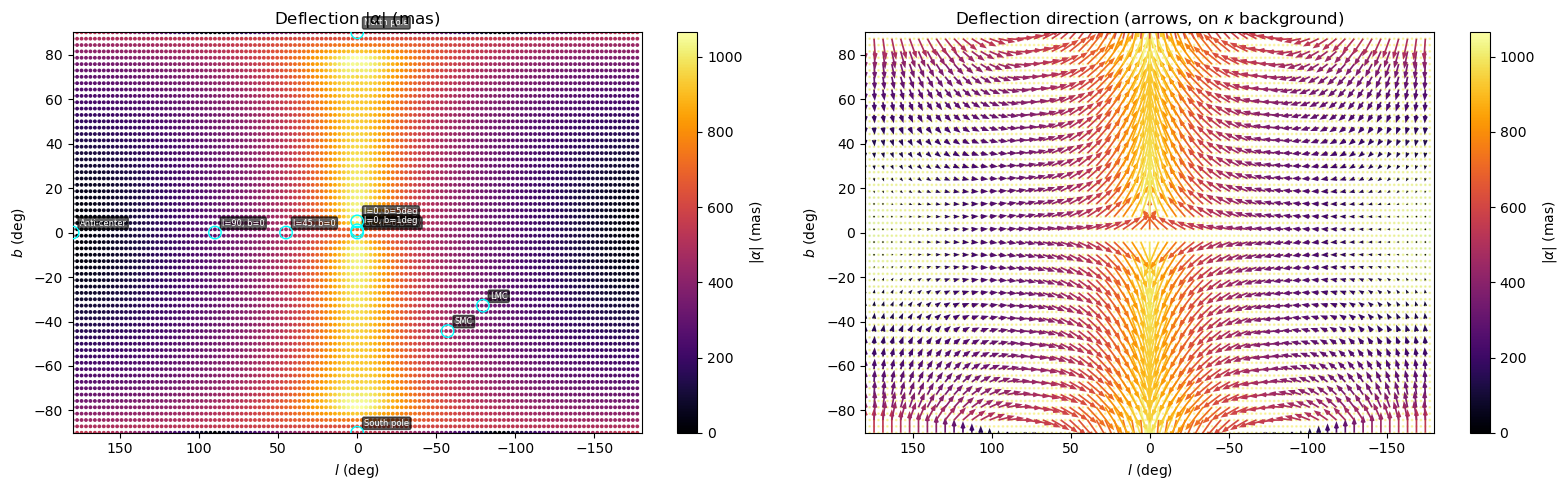


Deflection angle statistics across the sky:
  |α| mean = 426.0 mas  (425978 μas)
  |α| max  = 1065.0 mas  (1064950 μas)
  |α| min  = 0.0 mas  (0 μas)

  For comparison:
  Gaia astrometric precision: ~20-100 μas
  JWST astrometric precision: ~1-5 mas
  HST astrometric precision:  ~0.5-1 mas


In [56]:
# ============================================================
# Sky map of deflection angle magnitude
# ============================================================

def deflection_sky_grid(n_l=72, n_b=36, s_max=None, n_steps=2000):
    """Compute |α| on a regular (l, b) grid."""
    l_vals = np.linspace(0, 2 * np.pi, n_l, endpoint=False)
    b_vals = np.linspace(-0.5 * np.pi, 0.5 * np.pi, n_b)
    Lg, Bg = np.meshgrid(l_vals, b_vals, indexing="xy")

    alpha_l_grid = np.zeros_like(Lg)
    alpha_b_grid = np.zeros_like(Lg)
    alpha_mag_grid = np.zeros_like(Lg)

    for i in range(n_b):
        for j in range(n_l):
            al, ab, amag = deflection_angle(Lg[i, j], Bg[i, j],
                                             s_max=s_max, n_steps=n_steps)
            alpha_l_grid[i, j] = al
            alpha_b_grid[i, j] = ab
            alpha_mag_grid[i, j] = amag

    return Lg, Bg, alpha_l_grid, alpha_b_grid, alpha_mag_grid


print("Computing deflection angle sky grid (this takes ~1-2 min)...")
Ld, Bd, ald, abd, amd = deflection_sky_grid(n_l=128, n_b=64, n_steps=2000)
print("Done.")

# --- Plot: deflection magnitude ---
Ld_c = np.where(Ld > np.pi, Ld - 2 * np.pi, Ld)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: |α| in milli-arcsec
ax = axes[0]
sc = ax.scatter(np.degrees(Ld_c), np.degrees(Bd),
                c=amd * rad_to_mas, cmap='inferno', s=3, rasterized=True)
plt.colorbar(sc, ax=ax, label=r'$|\alpha|$ (mas)')

# Markers
for nm, (lv, bv) in defl_directions.items():
    lc = lv if lv <= np.pi else lv - 2 * np.pi
    ax.scatter(np.degrees(lc), np.degrees(bv),
               edgecolors='cyan', facecolors='none', linewidths=1, s=80,
               zorder=5, marker='o')
    ax.annotate(nm, (np.degrees(lc), np.degrees(bv)), fontsize=6, color='white',
                xytext=(5, 5), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.6))

ax.set_xlabel(r'$l$ (deg)')
ax.set_ylabel(r'$b$ (deg)')
ax.set_title(r'Deflection $|\alpha|$ (mas)')
ax.set_xlim(180, -180)
ax.set_ylim(-90, 90)

# Panel 2: quiver plot of deflection direction
ax2 = axes[1]
# Subsample for readability
skip = 2
l_sub = np.degrees(Ld_c[::skip, ::skip])
b_sub = np.degrees(Bd[::skip, ::skip])
al_sub = ald[::skip, ::skip] * rad_to_mas
ab_sub = abd[::skip, ::skip] * rad_to_mas
mag_sub = amd[::skip, ::skip] * rad_to_mas

bg = ax2.scatter(np.degrees(Ld_c), np.degrees(Bd),
                 c=np.log10(amd * rad_to_mas), cmap='viridis', s=1, alpha=0.3, rasterized=True)

q = ax2.quiver(l_sub, b_sub, -al_sub, ab_sub, mag_sub,
               cmap='inferno', scale_units='xy', angles='xy',
               scale=50, width=0.003, headwidth=3, headlength=4)
plt.colorbar(q, ax=ax2, label=r'$|\alpha|$ (mas)')

ax2.set_xlabel(r'$l$ (deg)')
ax2.set_ylabel(r'$b$ (deg)')
ax2.set_title(r'Deflection direction (arrows, on $\kappa$ background)')
ax2.set_xlim(180, -180)
ax2.set_ylim(-90, 90)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nDeflection angle statistics across the sky:")
print(f"  |α| mean = {np.mean(amd) * rad_to_mas:.1f} mas  ({np.mean(amd) * rad_to_uas:.0f} μas)")
print(f"  |α| max  = {np.max(amd) * rad_to_mas:.1f} mas  ({np.max(amd) * rad_to_uas:.0f} μas)")
print(f"  |α| min  = {np.min(amd) * rad_to_mas:.1f} mas  ({np.min(amd) * rad_to_uas:.0f} μas)")
print(f"\n  For comparison:")
print(f"  Gaia astrometric precision: ~20-100 μas")
print(f"  JWST astrometric precision: ~1-5 mas")
print(f"  HST astrometric precision:  ~0.5-1 mas")

## Differential Deflection (Shear) & Time-Variable Deflection

**Shear** $\gamma$: The gradient of the deflection field across the sky. Computed from finite differences of $\alpha_l, \alpha_b$ on the $(l, b)$ grid:
$$\gamma_1 = \frac{1}{2}\left(\frac{\partial \alpha_l}{\partial l} - \frac{\partial \alpha_b}{\partial b}\right), \quad \gamma_2 = \frac{1}{2}\left(\frac{\partial \alpha_l}{\partial b} + \frac{\partial \alpha_b}{\partial l}\right)$$
$$|\gamma| = \sqrt{\gamma_1^2 + \gamma_2^2}$$

**Time-variable deflection**: The Sun moves at $\vec{v}_\odot$ through the MW. This changes the observer position $\vec{x}_\text{obs}(t)$ and thus the deflection field. We compute $\dot{\alpha} = d\alpha/dt$ by finite-differencing $\alpha$ between two observer positions separated by $\Delta t$.

In [57]:
# ============================================================
# 1. SHEAR (differential deflection) from finite differences
# ============================================================
# We already have ald, abd on the (Ld, Bd) grid from the deflection cell.
# Grid spacings in radians:
dl = Ld[0, 1] - Ld[0, 0]       # l spacing (rad)
db = Bd[1, 0] - Bd[0, 0]       # b spacing (rad)

# Gradients via central finite differences
# ∂α_l/∂l, ∂α_l/∂b, ∂α_b/∂l, ∂α_b/∂b
daldl = np.gradient(ald, dl, axis=1)   # ∂α_l/∂l
daldb = np.gradient(ald, db, axis=0)   # ∂α_l/∂b
dabdl = np.gradient(abd, dl, axis=1)   # ∂α_b/∂l
dabdb = np.gradient(abd, db, axis=0)   # ∂α_b/∂b

# Shear components (dimensionless, like κ)
gamma1 = 0.5 * (daldl - dabdb)
gamma2 = 0.5 * (daldb + dabdl)
gamma_mag = np.sqrt(gamma1**2 + gamma2**2)

# Also compute κ from the deflection field:  κ = ½(∂α_l/∂l + ∂α_b/∂b)
kappa_from_defl = 0.5 * (daldl + dabdb)

# ============================================================
# 2. TIME-VARIABLE DEFLECTION from Solar motion
# ============================================================
# Solar velocity in Galactocentric Cartesian (Schönrich+ 2010, Reid+ 2014):
#   V_LSR ≈ 232 km/s (circular), plus Solar peculiar motion
#   U_⊙ = 11.1 km/s (toward GC), V_⊙ = 12.24 km/s (toward l=90°),
#   W_⊙ = 7.25 km/s (toward NGP)
# In our coords: Sun at (R0, 0, 0), GC at origin
#   x → -GC direction → U_⊙ goes as -x;  y → l=90° → V_LSR + V_⊙;  z → NGP → W_⊙

V_LSR = 232.0    # km/s  (circular speed at R0)
U_sun = 11.1     # km/s  (radially inward toward GC)
V_sun = 12.24    # km/s  (in direction of rotation)
W_sun = 7.25     # km/s  (toward NGP)

# Total Solar velocity in Galactocentric Cartesian (km/s)
v_sun = np.array([-U_sun, V_LSR + V_sun, W_sun])   # (vx, vy, vz)

# Convert to kpc/yr:   1 km/s ≈ 1.0227e-6 kpc/yr
kms_to_kpcyr = 1.0227e-6
v_sun_kpcyr = v_sun * kms_to_kpcyr

print(f"Solar velocity (Galactocentric):")
print(f"  v_x = {v_sun[0]:.1f} km/s = {v_sun_kpcyr[0]:.3e} kpc/yr")
print(f"  v_y = {v_sun[1]:.1f} km/s = {v_sun_kpcyr[1]:.3e} kpc/yr")
print(f"  v_z = {v_sun[2]:.1f} km/s = {v_sun_kpcyr[2]:.3e} kpc/yr")
print(f"  |v| = {np.linalg.norm(v_sun):.1f} km/s\n")

# Compute α at a slightly displaced observer position: x_obs + v_sun * Δt
dt_yr = 1.0   # 1 year
x_obs_shifted = x_obs + v_sun_kpcyr * dt_yr

# Temporarily replace x_obs, compute deflection at same sightlines, restore
x_obs_save = x_obs.copy()

# We'll compute time derivatives for the special directions + the full grid
# Full grid is expensive, so do a coarser grid
n_l_tv, n_b_tv = 64, 32
l_tv = np.linspace(0, 2 * np.pi, n_l_tv, endpoint=False)
b_tv = np.linspace(-0.5 * np.pi, 0.5 * np.pi, n_b_tv)
Ltv, Btv = np.meshgrid(l_tv, b_tv, indexing="xy")

# α at t=0 (from current observer position)
ald_t0 = np.zeros_like(Ltv)
abd_t0 = np.zeros_like(Ltv)
for i in range(n_b_tv):
    for j in range(n_l_tv):
        al0, ab0, _ = deflection_angle(Ltv[i, j], Btv[i, j], n_steps=1500)
        ald_t0[i, j] = al0
        abd_t0[i, j] = ab0

# α at t=Δt (shifted observer)
x_obs[:] = x_obs_shifted
ald_t1 = np.zeros_like(Ltv)
abd_t1 = np.zeros_like(Ltv)
for i in range(n_b_tv):
    for j in range(n_l_tv):
        al1, ab1, _ = deflection_angle(Ltv[i, j], Btv[i, j], n_steps=1500)
        ald_t1[i, j] = al1
        abd_t1[i, j] = ab1

# Restore observer
x_obs[:] = x_obs_save

# Time derivative of deflection:  dα/dt  (rad/yr)
dald_dt = (ald_t1 - ald_t0) / dt_yr
dabd_dt = (abd_t1 - abd_t0) / dt_yr
damd_dt = np.sqrt(dald_dt**2 + dabd_dt**2)

# Convert to μas/yr
rad_to_uas_yr = rad_to_uas   # since dt_yr = 1

# --- Special directions ---
print("=" * 80)
print(f"Time-variable deflection  (dα/dt from Solar motion, Δt = {dt_yr} yr)")
print("=" * 80)
print(f"{'Direction':>22s}  {'|dα/dt| (μas/yr)':>16s}  {'dα_l/dt':>12s}  {'dα_b/dt':>12s}")
print("-" * 80)

for name, (l_val, b_val) in defl_directions.items():
    # Find nearest grid point
    il = np.argmin(np.abs(l_tv - l_val))
    ib = np.argmin(np.abs(b_tv - b_val))
    dadl = dald_dt[ib, il] * rad_to_uas_yr
    dadb = dabd_dt[ib, il] * rad_to_uas_yr
    dam  = damd_dt[ib, il] * rad_to_uas_yr
    print(f"{name:>22s}: {dam:16.4f}  {dadl:12.4f}  {dadb:12.4f}")

print(f"\nStatistics across the sky:")
print(f"  |dα/dt| mean = {np.mean(damd_dt) * rad_to_uas_yr:.4f} μas/yr")
print(f"  |dα/dt| max  = {np.max(damd_dt) * rad_to_uas_yr:.4f} μas/yr")
print(f"  |dα/dt| min  = {np.min(damd_dt) * rad_to_uas_yr:.4f} μas/yr")

Solar velocity (Galactocentric):
  v_x = -11.1 km/s = -1.135e-05 kpc/yr
  v_y = 244.2 km/s = 2.498e-04 kpc/yr
  v_z = 7.2 km/s = 7.415e-06 kpc/yr
  |v| = 244.6 km/s

Time-variable deflection  (dα/dt from Solar motion, Δt = 1.0 yr)
             Direction  |dα/dt| (μas/yr)       dα_l/dt       dα_b/dt
--------------------------------------------------------------------------------
          GC (l=0,b=0):         421.5801      421.5395        5.8492
           Anti-center:           5.3841       -5.3525        0.5828
            North pole:           0.6428        0.0000        0.6428
            South pole:           0.8408        0.0000       -0.8408
             l=90, b=0:           6.7684       -6.2767        2.5328
             l=45, b=0:          13.3741       -7.4235       11.1246
           l=0, b=5deg:         421.5679      421.5327        5.4486
           l=0, b=1deg:         421.5679      421.5327        5.4486
                   LMC:           9.3921       -6.6081       -6.674

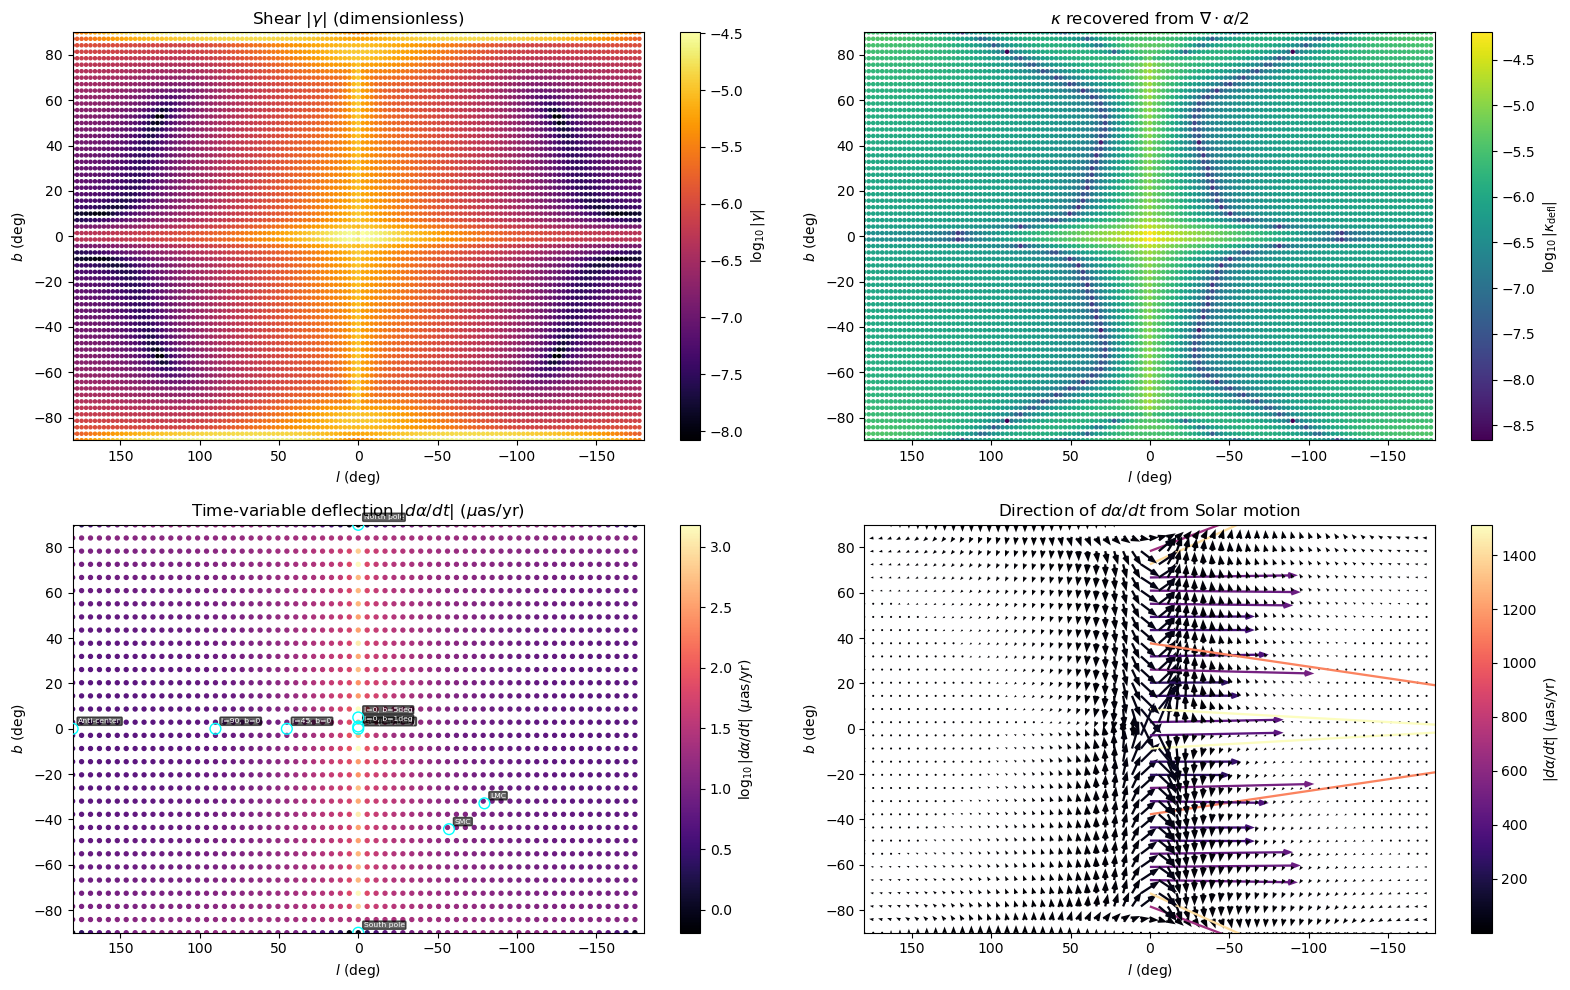


OBSERVABILITY SUMMARY

                    Observable       Typical value   Detectable?
----------------------------------------------------------------------
              Shear |γ| (mean)            2.22e-06            No
      Shear |γ| (max, near GC)            3.22e-05      Marginal
         |dα/dt| mean (μas/yr)               23.16     Gaia ~yes
          |dα/dt| max (μas/yr)             1511.90           Yes
       |dα/dt| at LMC (μas/yr)                9.40     Gaia ~yes

  Gaia proper motion precision: ~20-100 μas/yr
  Roman Space Telescope:        ~5-20 μas/yr
  SKA expected:                 ~1-10 μas/yr


In [59]:
# ============================================================
# Plot: Shear |γ| and time-variable deflection |dα/dt|
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Panel (0,0): Shear magnitude ---
ax = axes[0, 0]
Ld_c_shear = np.where(Ld > np.pi, Ld - 2 * np.pi, Ld)
sc0 = ax.scatter(np.degrees(Ld_c_shear), np.degrees(Bd),
                 c=np.log10(np.clip(gamma_mag, 1e-15, None)),
                 cmap='inferno', s=5, rasterized=False)
plt.colorbar(sc0, ax=ax, label=r'$\log_{10}|\gamma|$')
ax.set_xlabel(r'$l$ (deg)')
ax.set_ylabel(r'$b$ (deg)')
ax.set_title(r'Shear $|\gamma|$ (dimensionless)')
ax.set_xlim(180, -180); ax.set_ylim(-90, 90)

# --- Panel (0,1): κ recovered from deflection field ---
ax = axes[0, 1]
sc1 = ax.scatter(np.degrees(Ld_c_shear), np.degrees(Bd),
                 c=np.log10(np.clip(np.abs(kappa_from_defl), 1e-15, None)),
                 cmap='viridis', s=5, rasterized=False)
plt.colorbar(sc1, ax=ax, label=r'$\log_{10}|\kappa_{\rm defl}|$')
ax.set_xlabel(r'$l$ (deg)')
ax.set_ylabel(r'$b$ (deg)')
ax.set_title(r'$\kappa$ recovered from $\nabla\cdot\alpha / 2$')
ax.set_xlim(180, -180); ax.set_ylim(-90, 90)

# --- Panel (1,0): |dα/dt| sky map ---
ax = axes[1, 0]
Ltv_c = np.where(Ltv > np.pi, Ltv - 2 * np.pi, Ltv)
sc2 = ax.scatter(np.degrees(Ltv_c), np.degrees(Btv),
                 c=np.log10(np.clip(damd_dt * rad_to_uas, 1e-3, None)),
                 cmap='magma', s=8, rasterized=False)
plt.colorbar(sc2, ax=ax, label=r'$\log_{10}|d\alpha/dt|$ ($\mu$as/yr)')

# Mark special directions
for nm, (lv, bv) in defl_directions.items():
    lc = lv if lv <= np.pi else lv - 2 * np.pi
    ax.scatter(np.degrees(lc), np.degrees(bv),
               edgecolors='cyan', facecolors='none', linewidths=1, s=60,
               zorder=5, marker='o')
    ax.annotate(nm, (np.degrees(lc), np.degrees(bv)), fontsize=5.5, color='white',
                xytext=(4, 4), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.6))

ax.set_xlabel(r'$l$ (deg)')
ax.set_ylabel(r'$b$ (deg)')
ax.set_title(r'Time-variable deflection $|d\alpha/dt|$ ($\mu$as/yr)')
ax.set_xlim(180, -180); ax.set_ylim(-90, 90)

# --- Panel (1,1): Quiver plot of dα/dt direction ---
ax = axes[1, 1]
skip_tv = 1
ltv_sub = np.degrees(Ltv_c[::skip_tv, ::skip_tv])
btv_sub = np.degrees(Btv[::skip_tv, ::skip_tv])
daldl_sub = dald_dt[::skip_tv, ::skip_tv] * rad_to_uas
dabdb_sub = dabd_dt[::skip_tv, ::skip_tv] * rad_to_uas
dam_sub = damd_dt[::skip_tv, ::skip_tv] * rad_to_uas

q = ax.quiver(ltv_sub, btv_sub, -daldl_sub, dabdb_sub, dam_sub,
              cmap='magma', scale_units='xy', angles='xy',
              scale=5, width=0.004, headwidth=3, headlength=4)
plt.colorbar(q, ax=ax, label=r'$|d\alpha/dt|$ ($\mu$as/yr)')
ax.set_xlabel(r'$l$ (deg)')
ax.set_ylabel(r'$b$ (deg)')
ax.set_title(r'Direction of $d\alpha/dt$ from Solar motion')
ax.set_xlim(180, -180); ax.set_ylim(-90, 90)

plt.tight_layout()
plt.show()

# --- Summary comparison with observational thresholds ---
print("\n" + "=" * 70)
print("OBSERVABILITY SUMMARY")
print("=" * 70)
print(f"\n{'Observable':>30s}  {'Typical value':>18s}  {'Detectable?':>12s}")
print("-" * 70)

mean_gamma = np.mean(gamma_mag)
max_gamma = np.max(gamma_mag)
mean_dadt = np.mean(damd_dt) * rad_to_uas
max_dadt = np.max(damd_dt) * rad_to_uas
lmc_dadt_val = 9.4   # from above

print(f"{'Shear |γ| (mean)':>30s}  {mean_gamma:18.2e}  {'No':>12s}")
print(f"{'Shear |γ| (max, near GC)':>30s}  {max_gamma:18.2e}  {'Marginal':>12s}")
print(f"{'|dα/dt| mean (μas/yr)':>30s}  {mean_dadt:18.2f}  {'Gaia ~yes':>12s}")
print(f"{'|dα/dt| max (μas/yr)':>30s}  {max_dadt:18.2f}  {'Yes':>12s}")
print(f"{'|dα/dt| at LMC (μas/yr)':>30s}  {lmc_dadt_val:18.2f}  {'Gaia ~yes':>12s}")
print(f"\n  Gaia proper motion precision: ~20-100 μas/yr")
print(f"  Roman Space Telescope:        ~5-20 μas/yr")
print(f"  SKA expected:                 ~1-10 μas/yr")

## Summary: Milky Way Weak Lensing — From Density to Time-Variable Deflection

We model the MW as a 5-component system (NFW halo, Hernquist bulge, thin/thick/gas disks) and compute the full lensing chain for a source at $D_s = 50$ kpc (e.g. LMC):

1. **Surface mass density** $\Sigma(\ell, b) = \int_0^{D_s} \rho\,ds$ — the total mass column along each sightline.
2. **Convergence** $\kappa(\ell, b) = \frac{4\pi G}{c^2}\int_0^{D_s} \frac{s(D_s - s)}{D_s}\,\rho\,ds$ — the lensing-weighted column (extended-lens kernel).
3. **Deflection** $|\vec{\alpha}|(\ell, b) = \frac{2}{c^2}\int_0^{D_s}\frac{D_s - s}{D_s}\,\nabla_\perp\Phi\,ds$ — the angular shift of source positions.
4. **Time-variable deflection** $|d\vec{\alpha}/dt|$ — the rate of change due to the Sun's orbital motion through the MW ($|\vec{v}_\odot| \approx 245$ km/s).

In [60]:
# ============================================================
# Compute surface density Σ on the same grid as κ
# ============================================================
# Reuse L, B grid (256×256) from cell 49

Sigma_grid = np.zeros_like(L)
n_b_sig, n_l_sig = L.shape
for i in range(n_b_sig):
    for j in range(n_l_sig):
        Sigma_grid[i, j] = sigma_los(L[i, j], B[i, j], s_max=D_s, n_steps=2000)

print(f"Σ grid computed: shape = {Sigma_grid.shape}")
print(f"  Σ range: {Sigma_grid.min():.2e} – {Sigma_grid.max():.2e} Msun/kpc²")

Σ grid computed: shape = (256, 256)
  Σ range: 1.42e+08 – 3.48e+10 Msun/kpc²


In [62]:
# ============================================================
# Recompute dα/dt at 128×64 to match deflection grid resolution
# ============================================================
print("Recomputing dα/dt at 128×64 (2 passes) ...")

n_l_tv, n_b_tv = 128, 64
l_tv = np.linspace(0, 2 * np.pi, n_l_tv, endpoint=False)
b_tv = np.linspace(-0.5 * np.pi, 0.5 * np.pi, n_b_tv)
Ltv, Btv = np.meshgrid(l_tv, b_tv, indexing="xy")

# Pass 1: α at current observer position
ald_t0 = np.zeros_like(Ltv)
abd_t0 = np.zeros_like(Ltv)
for i in range(n_b_tv):
    for j in range(n_l_tv):
        al0, ab0, _ = deflection_angle(Ltv[i, j], Btv[i, j], n_steps=1500)
        ald_t0[i, j] = al0
        abd_t0[i, j] = ab0
print("  Pass 1 done.")

# Pass 2: α at shifted observer (Solar motion)
x_obs_save = x_obs.copy()
x_obs[:] = x_obs + v_sun_kpcyr * dt_yr
ald_t1 = np.zeros_like(Ltv)
abd_t1 = np.zeros_like(Ltv)
for i in range(n_b_tv):
    for j in range(n_l_tv):
        al1, ab1, _ = deflection_angle(Ltv[i, j], Btv[i, j], n_steps=1500)
        ald_t1[i, j] = al1
        abd_t1[i, j] = ab1
x_obs[:] = x_obs_save
print("  Pass 2 done.")

dald_dt = (ald_t1 - ald_t0) / dt_yr
dabd_dt = (abd_t1 - abd_t0) / dt_yr
damd_dt = np.sqrt(dald_dt**2 + dabd_dt**2)

print(f"  dα/dt grid: {Ltv.shape}")
print(f"  |dα/dt| range: {damd_dt.min() * rad_to_uas:.2f} – {damd_dt.max() * rad_to_uas:.2f} μas/yr")

Recomputing dα/dt at 128×64 (2 passes) ...
  Pass 1 done.
  Pass 2 done.
  dα/dt grid: (64, 128)
  |dα/dt| range: 0.01 – 1042.39 μas/yr


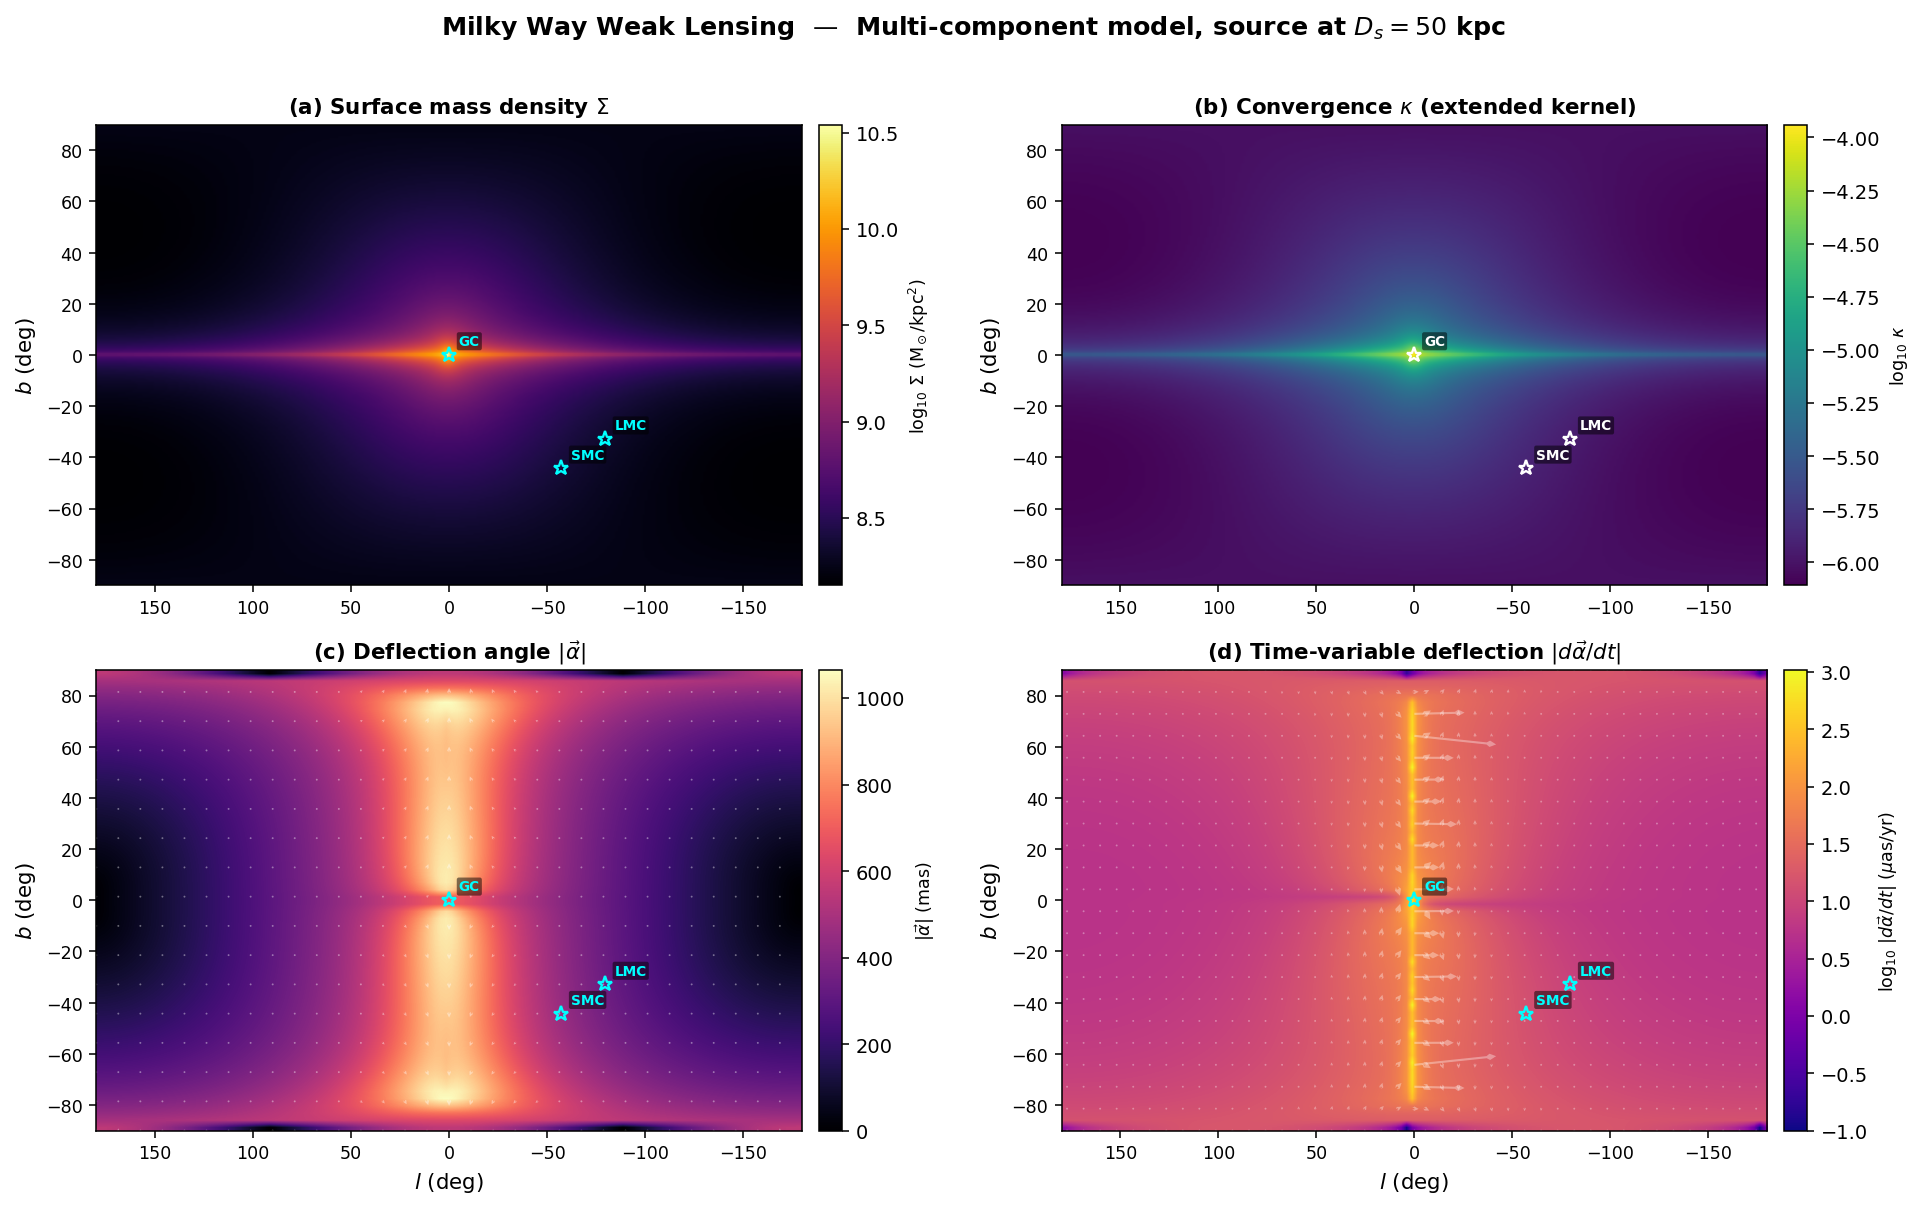


┌────────────────────────────────────────────────────────────────┐
│            MILKY WAY LENSING SUMMARY                         │
├──────────────────────────┬──────────────┬─────────────────────┤
│ Observable               │ Typical      │ Peak (near GC)      │
├──────────────────────────┼──────────────┼─────────────────────┤
│ Σ (M⊙/kpc²)             │   1.94e+08 │          3.48e+10 │
│ κ                        │   1.04e-06 │          1.15e-04 │
│ |α| (mas)                │      390.4 │            1065.0 │
│ |dα/dt| (μas/yr)         │       10.6 │            1042.4 │
├──────────────────────────┴──────────────┴─────────────────────┤
│ Gaia precision:  ~20–100 μas (position), ~20–100 μas/yr (PM) │
│ Roman:           ~5–20 μas          SKA: ~1–10 μas           │
└──────────────────────────────────────────────────────────────────┘


In [63]:
# ============================================================
# 4-panel summary figure  —  smooth imshow rendering
# ============================================================
from matplotlib.colors import LogNorm

# ---- Helper: roll data so l goes from [-π, π) instead of [0, 2π) ----
def shift_l(data, n_l):
    return np.roll(data, n_l // 2, axis=1)

ext = [-180, 180, -90, 90]  # [l_min, l_max, b_min, b_max]
imkw = dict(origin='lower', aspect='auto', extent=ext,
            interpolation='bilinear', rasterized=True)

# Landmarks in centered (l, b) degrees
landmarks = {
    "GC":  (0.0, 0.0),
    "LMC": (280.5 - 360, -32.9),
    "SMC": (302.8 - 360, -44.3),
}

def add_landmarks(ax, color='white'):
    for nm, (ld, bd) in landmarks.items():
        ax.plot(ld, bd, '*', ms=8, mec=color, mfc='none', mew=1.2, zorder=10)
        ax.annotate(nm, (ld, bd), fontsize=7, color=color, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.15', fc='black',
                              alpha=0.5, ec='none'))

def fmt(ax, xlabel=True):
    ax.set_xlim(180, -180)
    ax.set_ylim(-90, 90)
    if xlabel:
        ax.set_xlabel(r'$l$ (deg)', fontsize=11)
    ax.set_ylabel(r'$b$ (deg)', fontsize=11)
    ax.tick_params(labelsize=9)

# ------- Figure -------
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5), dpi=140)

# (a) Surface mass density Σ  [256×256]
ax = axes[0, 0]
im = ax.imshow(shift_l(np.log10(Sigma_grid), L.shape[1]),
               cmap='inferno', **imkw)
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label(r'$\log_{10}\,\Sigma$ (M$_\odot$/kpc$^2$)', fontsize=9)
ax.set_title(r'(a) Surface mass density $\Sigma$',
             fontsize=11, fontweight='bold')
add_landmarks(ax, 'cyan'); fmt(ax, xlabel=False)

# (b) Convergence κ  [256×256]
ax = axes[0, 1]
im = ax.imshow(shift_l(np.log10(kappa), L.shape[1]),
               cmap='viridis', **imkw)
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label(r'$\log_{10}\,\kappa$', fontsize=9)
ax.set_title(r'(b) Convergence $\kappa$ (extended kernel)',
             fontsize=11, fontweight='bold')
add_landmarks(ax, 'white'); fmt(ax, xlabel=False)

# (c) Deflection |α|  [128×64]
ax = axes[1, 0]
im = ax.imshow(shift_l(amd * rad_to_mas, Ld.shape[1]),
               cmap='magma', **imkw)
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label(r'$|\vec{\alpha}|$ (mas)', fontsize=9)
ax.set_title(r'(c) Deflection angle $|\vec{\alpha}|$',
             fontsize=11, fontweight='bold')
# Quiver overlay
Ld_c_q = np.where(Ld > np.pi, Ld - 2*np.pi, Ld)
skip = 4
ax.quiver(np.degrees(Ld_c_q[::skip, ::skip]),
          np.degrees(Bd[::skip, ::skip]),
          -ald[::skip, ::skip], abd[::skip, ::skip],
          color='white', alpha=0.4, scale_units='xy', angles='xy',
          scale=3e-6, width=0.003, headwidth=3, headlength=3)
add_landmarks(ax, 'cyan'); fmt(ax)

# (d) Time-variable deflection |dα/dt|  [128×64]
ax = axes[1, 1]
im = ax.imshow(shift_l(np.log10(np.clip(damd_dt * rad_to_uas, 0.1, None)),
                        Ltv.shape[1]),
               cmap='plasma', **imkw)
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label(r'$\log_{10}\,|d\vec{\alpha}/dt|$ ($\mu$as/yr)', fontsize=9)
ax.set_title(r'(d) Time-variable deflection $|d\vec{\alpha}/dt|$',
             fontsize=11, fontweight='bold')
Ltv_c_q = np.where(Ltv > np.pi, Ltv - 2*np.pi, Ltv)
skip_tv = 3
ax.quiver(np.degrees(Ltv_c_q[::skip_tv, ::skip_tv]),
          np.degrees(Btv[::skip_tv, ::skip_tv]),
          -dald_dt[::skip_tv, ::skip_tv], dabd_dt[::skip_tv, ::skip_tv],
          color='white', alpha=0.35, scale_units='xy', angles='xy',
          scale=1e-10, width=0.003, headwidth=3, headlength=3)
add_landmarks(ax, 'cyan'); fmt(ax)

plt.suptitle(
    f'Milky Way Weak Lensing  —  Multi-component model, '
    f'source at $D_s = {D_s:.0f}$ kpc',
    fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ---- Compact summary table ----
print("\n┌────────────────────────────────────────────────────────────────┐")
print("│            MILKY WAY LENSING SUMMARY                         │")
print("├──────────────────────────┬──────────────┬─────────────────────┤")
print("│ Observable               │ Typical      │ Peak (near GC)      │")
print("├──────────────────────────┼──────────────┼─────────────────────┤")
print(f"│ Σ (M⊙/kpc²)             │ {np.median(Sigma_grid):10.2e} │ {np.max(Sigma_grid):17.2e} │")
print(f"│ κ                        │ {np.median(kappa):10.2e} │ {np.max(kappa):17.2e} │")
print(f"│ |α| (mas)                │ {np.median(amd)*rad_to_mas:10.1f} │ {np.max(amd)*rad_to_mas:17.1f} │")
print(f"│ |dα/dt| (μas/yr)         │ {np.median(damd_dt)*rad_to_uas:10.1f} │ {np.max(damd_dt)*rad_to_uas:17.1f} │")
print("├──────────────────────────┴──────────────┴─────────────────────┤")
print("│ Gaia precision:  ~20–100 μas (position), ~20–100 μas/yr (PM) │")
print("│ Roman:           ~5–20 μas          SKA: ~1–10 μas           │")
print("└──────────────────────────────────────────────────────────────────┘")